# Minimal Burgers Discovery Story

This notebook is a deliberately bare-bones diagnostic. It uses the existing `burg_gen` dataset generator, the current `SirenMLP` surrogate, and the project's Burgers reference-derivative helper, but keeps the actual fitting, autodiff, least-squares identification, and minimal SymNet logic visible in notebook cells.

Questions answered in order:

1. What does the clean Burgers rollout look like?
2. Can the current SIREN fit the solution from data alone?
3. Do the fitted surrogate derivatives match the reference derivatives well enough?
4. Can direct least squares on surrogate derivatives recover Burgers?
5. What is the smallest visible SymNet-style product model that can express Burgers?
6. Does that architecture reproduce Burgers exactly when weights are hand-set?
7. If we start exactly at Burgers and train only SymNet, does it stay there or drift?
8. Optionally, what changes if SIREN and SymNet are trained jointly?
9. Can the Phase 11 least-squares coefficient vector be lifted into the original minimal SymNet and remain stable there?
10. How does frozen SymNet convergence depend on structured initialization families?


In [1]:
from __future__ import annotations

import copy
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from Datasets.data.processed.burg_gen.burg_gen import solve_burgers
from prog.mlps import SirenMLP
from utils.derivative_utils import build_burgers_reference_derivative_grids, compute_error_metrics

plt.style.use("seaborn-v0_8-whitegrid")

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device = {device}")
print(f"seed = {SEED}")

device = cpu
seed = 0


In [2]:
def plot_time_slices(x, true_grid, pred_grid=None, time_values=None, title_prefix="u", slice_indices=None):
    if slice_indices is None:
        slice_indices = np.linspace(0, len(time_values) - 1, 5, dtype=int)
    ncols = len(slice_indices)
    fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 3.5), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, idx in zip(axes, slice_indices):
        ax.plot(x, true_grid[idx], label=f"true {title_prefix}", linewidth=2)
        if pred_grid is not None:
            ax.plot(x, pred_grid[idx], "--", label=f"pred {title_prefix}", linewidth=2)
        ax.set_title(f"t = {time_values[idx]:.3f}")
        ax.set_xlabel("x")
    axes[0].set_ylabel(title_prefix)
    axes[0].legend(loc="best")
    plt.tight_layout()
    plt.show()


def evaluate_model_and_derivatives_in_chunks(model, t_flat, x_flat, grid_shape, chunk_size=4096, device=device):
    u_parts = []
    ut_parts = []
    ux_parts = []
    uxx_parts = []

    model.eval()
    for start in range(0, len(t_flat), chunk_size):
        stop = min(start + chunk_size, len(t_flat))

        t_chunk = torch.tensor(t_flat[start:stop], dtype=torch.float32, device=device).reshape(-1, 1)
        x_chunk = torch.tensor(x_flat[start:stop], dtype=torch.float32, device=device).reshape(-1, 1)
        t_chunk.requires_grad_(True)
        x_chunk.requires_grad_(True)

        u_chunk = model(t_chunk, x_chunk)
        ut_chunk = torch.autograd.grad(
            u_chunk,
            t_chunk,
            grad_outputs=torch.ones_like(u_chunk),
            create_graph=False,
            retain_graph=True,
        )[0]
        ux_chunk = torch.autograd.grad(
            u_chunk,
            x_chunk,
            grad_outputs=torch.ones_like(u_chunk),
            create_graph=True,
            retain_graph=True,
        )[0]
        uxx_chunk = torch.autograd.grad(
            ux_chunk,
            x_chunk,
            grad_outputs=torch.ones_like(ux_chunk),
            create_graph=False,
            retain_graph=False,
        )[0]

        u_parts.append(u_chunk.detach().cpu().numpy())
        ut_parts.append(ut_chunk.detach().cpu().numpy())
        ux_parts.append(ux_chunk.detach().cpu().numpy())
        uxx_parts.append(uxx_chunk.detach().cpu().numpy())

    u = np.concatenate(u_parts, axis=0).reshape(grid_shape)
    ut = np.concatenate(ut_parts, axis=0).reshape(grid_shape)
    ux = np.concatenate(ux_parts, axis=0).reshape(grid_shape)
    uxx = np.concatenate(uxx_parts, axis=0).reshape(grid_shape)
    return {"u": u, "u_t": ut, "u_x": ux, "u_xx": uxx}


def as_metric_row(name, pred, ref):
    row = compute_error_metrics(pred, ref)
    row["quantity"] = name
    return row


def product_term_dict(model):
    left = model.left.weight.detach().cpu().numpy().reshape(-1)
    right = model.right.weight.detach().cpu().numpy().reshape(-1)
    linear = model.linear.weight.detach().cpu().numpy().reshape(-1)
    alpha = float(model.product_readout.weight.detach().cpu().numpy().reshape(-1)[0])
    names = ["u", "u_x", "u_xx"]

    coeffs = {
        "u": float(linear[0]),
        "u_x": float(linear[1]),
        "u_xx": float(linear[2]),
        "u^2": float(alpha * left[0] * right[0]),
        "u*u_x": float(alpha * (left[0] * right[1] + left[1] * right[0])),
        "u*u_xx": float(alpha * (left[0] * right[2] + left[2] * right[0])),
        "u_x^2": float(alpha * left[1] * right[1]),
        "u_x*u_xx": float(alpha * (left[1] * right[2] + left[2] * right[1])),
        "u_xx^2": float(alpha * left[2] * right[2]),
    }
    return coeffs


def pretty_equation(coeffs):
    ordered = ["u", "u_x", "u_xx", "u^2", "u*u_x", "u*u_xx", "u_x^2", "u_x*u_xx", "u_xx^2"]
    pieces = [f"({coeffs[name]:+.6f})*{name}" for name in ordered if abs(coeffs[name]) > 1e-12]
    return "u_t_hat = " + (" + ".join(pieces) if pieces else "0")


def initialize_symnet_to_burgers(model, diffusion=0.02):
    with torch.no_grad():
        model.left.weight.zero_()
        model.right.weight.zero_()
        model.linear.weight.zero_()
        model.product_readout.weight.zero_()

        model.left.weight[0, 0] = 1.0
        model.right.weight[0, 1] = 1.0
        model.product_readout.weight[0, 0] = -1.0
        model.linear.weight[0, 2] = diffusion


## 1. Load and Inspect the Burgers Data

Question answered here: what clean solution are we trying to fit, and what is the true PDE behind it?

In [3]:
NU_TRUE = 0.02

x_grid, _u_final, _t_end, (t_grid, u_grid) = solve_burgers(seed=SEED, return_history=True)
x_grid = np.asarray(x_grid, dtype=np.float32)
t_grid = np.asarray(t_grid, dtype=np.float32)
u_grid = np.asarray(u_grid, dtype=np.float32)

print(f"x shape: {x_grid.shape}")
print(f"t shape: {t_grid.shape}")
print(f"u shape: {u_grid.shape}")
print("true PDE: u_t = -u*u_x + 0.02*u_xx")

slice_indices = np.linspace(0, len(t_grid) - 1, 5, dtype=int)
slice_times = t_grid[slice_indices]
print("representative slice indices:", slice_indices)
print("representative slice times:", np.round(slice_times, 4))

x shape: (256,)
t shape: (252,)
u shape: (252, 256)
true PDE: u_t = -u*u_x + 0.02*u_xx
representative slice indices: [  0  62 125 188 251]
representative slice times: [0.    0.246 0.498 0.75  1.   ]


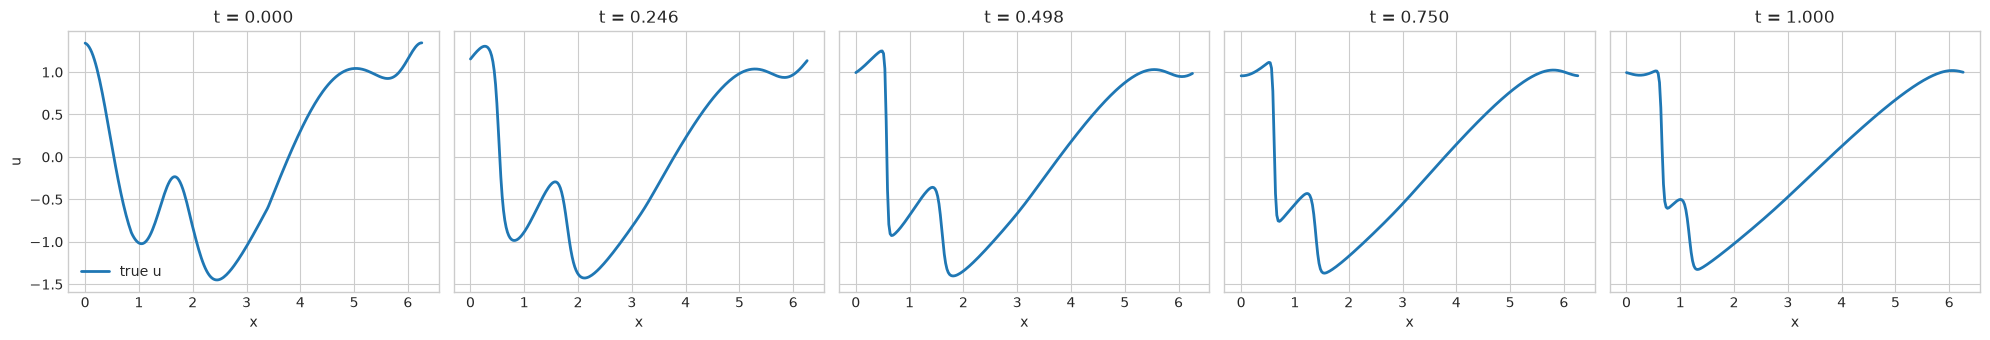

In [4]:
plot_time_slices(x_grid, u_grid, pred_grid=None, time_values=t_grid, title_prefix="u", slice_indices=slice_indices)

## 2. Fit the Neural Surrogate to Data Only

Question answered here: can the current SIREN represent the Burgers rollout when trained only on solution values, with no PDE loss or sparsity machinery?

In [5]:
T_mesh = np.repeat(t_grid[:, None], len(x_grid), axis=1)
X_mesh = np.repeat(x_grid[None, :], len(t_grid), axis=0)

t_flat = T_mesh.reshape(-1).astype(np.float32)
x_flat = X_mesh.reshape(-1).astype(np.float32)
u_flat = u_grid.reshape(-1).astype(np.float32)

t_train = torch.tensor(t_flat, dtype=torch.float32, device=device).reshape(-1, 1)
x_train = torch.tensor(x_flat, dtype=torch.float32, device=device).reshape(-1, 1)
u_train = torch.tensor(u_flat, dtype=torch.float32, device=device).reshape(-1, 1)

print("flattened training tensors:")
print("t_train", tuple(t_train.shape))
print("x_train", tuple(x_train.shape))
print("u_train", tuple(u_train.shape))

siren = SirenMLP(
    hidden_size=64,
    hidden_layers=3,
    first_omega_0=20.0,
    hidden_omega_0=1.0,
).to(device)

adam_steps = 2500
lbfgs_steps = 200
batch_size = 4096
log_every = 250

adam = torch.optim.Adam(siren.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
data_history = []

for step in range(1, adam_steps + 1):
    idx = torch.randint(0, len(t_train), (batch_size,), device=device)
    t_batch = t_train[idx]
    x_batch = x_train[idx]
    u_batch = u_train[idx]

    pred_batch = siren(t_batch, x_batch)
    loss = loss_fn(pred_batch, u_batch)

    adam.zero_grad()
    loss.backward()
    adam.step()

    if step % log_every == 0 or step == 1:
        with torch.no_grad():
            full_loss = loss_fn(siren(t_train, x_train), u_train).item()
        data_history.append({"stage": "adam", "step": step, "loss": full_loss})
        print(f"adam step {step:4d} | full data MSE = {full_loss:.6e}")

lbfgs = torch.optim.LBFGS(siren.parameters(), lr=1.0, max_iter=lbfgs_steps, history_size=50, line_search_fn="strong_wolfe")

def lbfgs_closure():
    lbfgs.zero_grad()
    pred = siren(t_train, x_train)
    loss = loss_fn(pred, u_train)
    loss.backward()
    return loss

lbfgs_loss = float(lbfgs.step(lbfgs_closure))
with torch.no_grad():
    final_data_mse = loss_fn(siren(t_train, x_train), u_train).item()
print(f"lbfgs start loss = {lbfgs_loss:.6e}")
print(f"final full data MSE = {final_data_mse:.6e}")

flattened training tensors:
t_train (64512, 1)
x_train (64512, 1)
u_train (64512, 1)
adam step    1 | full data MSE = 1.237509e+00
adam step  250 | full data MSE = 2.239449e-03
adam step  500 | full data MSE = 9.205454e-04
adam step  750 | full data MSE = 5.343718e-04
adam step 1000 | full data MSE = 3.489708e-04
adam step 1250 | full data MSE = 2.460817e-04
adam step 1500 | full data MSE = 1.849820e-04
adam step 1750 | full data MSE = 1.402480e-04
adam step 2000 | full data MSE = 1.112314e-04
adam step 2250 | full data MSE = 8.973129e-05
adam step 2500 | full data MSE = 7.444458e-05
lbfgs start loss = 7.444458e-05
final full data MSE = 5.603033e-05


burgers_minimal_discovery_story.ipynb:cell_7:61: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)


               mse    rel_l2      rmse   max_abs
quantity                                        
u         0.000056  0.008739  0.007485  0.067407

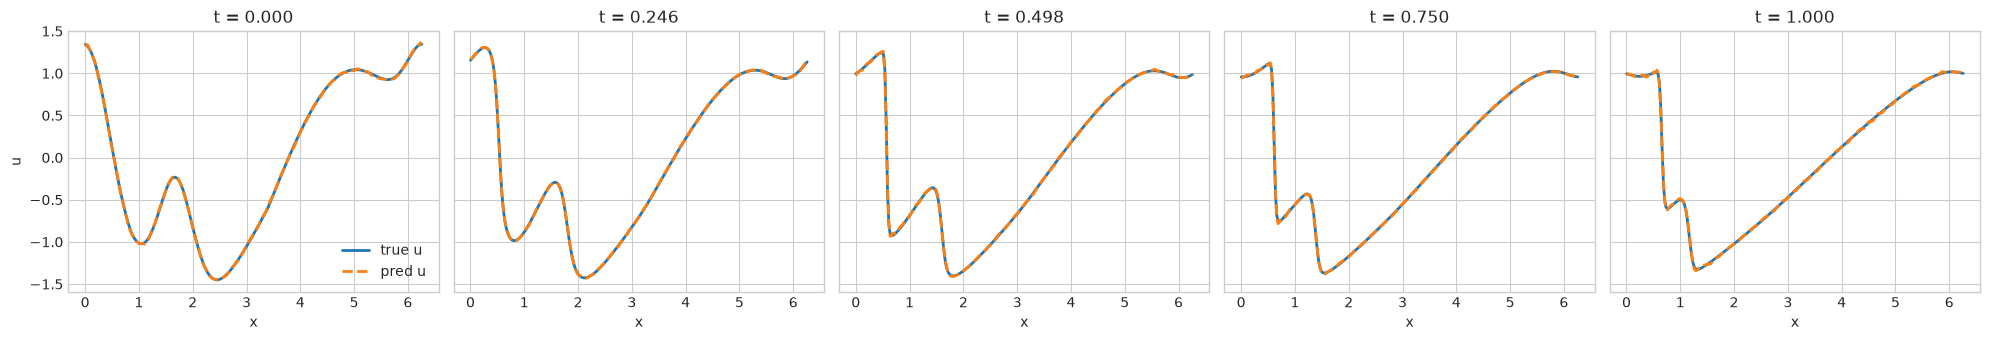

In [6]:
with torch.no_grad():
    u_pred_grid = siren(t_train, x_train).detach().cpu().numpy().reshape(u_grid.shape)

solution_metrics = pd.DataFrame([
    as_metric_row("u", u_pred_grid, u_grid),
]).set_index("quantity")
display(solution_metrics)

plot_time_slices(x_grid, u_grid, pred_grid=u_pred_grid, time_values=t_grid, title_prefix="u", slice_indices=slice_indices)

## 3. Inspect Derivatives Produced by the Fitted Surrogate

Question answered here: after fitting only to solution values, do the surrogate's autodiff derivatives match the clean Burgers reference derivatives well enough not only at the primitive level (`u_t`, `u_x`, `u_xx`) but also across the full second-order feature library actually seen by the minimal SymNet?

In [7]:
reference = build_burgers_reference_derivative_grids(
    u_grid=u_grid,
    x_grid=x_grid,
    nu=NU_TRUE,
)

surrogate_fields = evaluate_model_and_derivatives_in_chunks(
    siren,
    t_flat=t_flat,
    x_flat=x_flat,
    grid_shape=u_grid.shape,
    chunk_size=4096,
    device=device,
)

phase3_feature_names = ["u", "u_x", "u_xx", "u^2", "u*u_x", "u*u_xx", "u_x^2", "u_x*u_xx", "u_xx^2"]
phase3_second_order_feature_names = ["u^2", "u*u_x", "u*u_xx", "u_x^2", "u_x*u_xx", "u_xx^2"]
phase3_heatmap_feature_names = ["u^2", "u*u_x", "u*u_xx", "u_x^2", "u_x*u_xx", "u_xx^2"]

phase3_reference_primitives = {
    "u": np.asarray(reference["u"]["physical"], dtype=np.float64),
    "u_x": np.asarray(reference["u_x"]["physical"], dtype=np.float64),
    "u_xx": np.asarray(reference["u_xx"]["physical"], dtype=np.float64),
}
phase3_surrogate_primitives = {
    "u": np.asarray(surrogate_fields["u"], dtype=np.float64),
    "u_x": np.asarray(surrogate_fields["u_x"], dtype=np.float64),
    "u_xx": np.asarray(surrogate_fields["u_xx"], dtype=np.float64),
}


def build_minimal_feature_library(primitives):
    u = primitives["u"]
    ux = primitives["u_x"]
    uxx = primitives["u_xx"]
    return {
        "u": u,
        "u_x": ux,
        "u_xx": uxx,
        "u^2": u ** 2,
        "u*u_x": u * ux,
        "u*u_xx": u * uxx,
        "u_x^2": ux ** 2,
        "u_x*u_xx": ux * uxx,
        "u_xx^2": uxx ** 2,
    }


phase3_reference_feature_grids = build_minimal_feature_library(phase3_reference_primitives)
phase3_surrogate_feature_grids = build_minimal_feature_library(phase3_surrogate_primitives)

target_derivative_metrics = pd.DataFrame([
    as_metric_row("u_t", surrogate_fields["u_t"], reference["u_t"]["physical"]),
]).set_index("quantity")

derivative_metrics = pd.DataFrame([
    as_metric_row("u_x", surrogate_fields["u_x"], reference["u_x"]["physical"]),
    as_metric_row("u_xx", surrogate_fields["u_xx"], reference["u_xx"]["physical"]),
]).set_index("quantity")

phase3_feature_metrics_df = pd.DataFrame([
    as_metric_row(name, phase3_surrogate_feature_grids[name], phase3_reference_feature_grids[name])
    for name in phase3_feature_names
]).set_index("quantity")
phase3_feature_rank_df = phase3_feature_metrics_df.sort_values(["rel_l2", "rmse"], ascending=[True, True])

phase3_theta_ref = np.column_stack([
    phase3_reference_feature_grids[name].reshape(-1) for name in phase3_feature_names
])
phase3_theta_pred = np.column_stack([
    phase3_surrogate_feature_grids[name].reshape(-1) for name in phase3_feature_names
])
phase3_theta_abs_err = np.abs(phase3_theta_pred - phase3_theta_ref)
phase3_theta_rel_frob = float(np.linalg.norm(phase3_theta_pred - phase3_theta_ref) / np.linalg.norm(phase3_theta_ref))
phase3_theta_max_abs = float(np.max(phase3_theta_abs_err))
phase3_theta_ref_svals = np.linalg.svd(phase3_theta_ref, compute_uv=False)
phase3_theta_pred_svals = np.linalg.svd(phase3_theta_pred, compute_uv=False)
phase3_theta_ref_cond = float(phase3_theta_ref_svals[0] / phase3_theta_ref_svals[-1])
phase3_theta_pred_cond = float(phase3_theta_pred_svals[0] / phase3_theta_pred_svals[-1])

phase3_feature_matrix_summary_df = pd.DataFrame([
    {
        "matrix": "Theta_ref",
        "fro_norm": float(np.linalg.norm(phase3_theta_ref)),
        "min_singular": float(phase3_theta_ref_svals[-1]),
        "max_singular": float(phase3_theta_ref_svals[0]),
        "condition_number": phase3_theta_ref_cond,
    },
    {
        "matrix": "Theta_pred",
        "fro_norm": float(np.linalg.norm(phase3_theta_pred)),
        "min_singular": float(phase3_theta_pred_svals[-1]),
        "max_singular": float(phase3_theta_pred_svals[0]),
        "condition_number": phase3_theta_pred_cond,
    },
    {
        "matrix": "Theta_pred - Theta_ref",
        "fro_norm": float(np.linalg.norm(phase3_theta_pred - phase3_theta_ref)),
        "min_singular": float(np.linalg.svd(phase3_theta_pred - phase3_theta_ref, compute_uv=False)[-1]),
        "max_singular": float(np.linalg.svd(phase3_theta_pred - phase3_theta_ref, compute_uv=False)[0]),
        "condition_number": float("nan"),
    },
]).set_index("matrix")

phase3_column_summary_df = pd.DataFrame([
    {
        "feature": name,
        "||col_ref||_2": float(np.linalg.norm(phase3_theta_ref[:, idx])),
        "||col_pred||_2": float(np.linalg.norm(phase3_theta_pred[:, idx])),
        "norm_ratio(pred/ref)": float(np.linalg.norm(phase3_theta_pred[:, idx]) / np.linalg.norm(phase3_theta_ref[:, idx])),
        "column_rel_l2": float(np.linalg.norm(phase3_theta_pred[:, idx] - phase3_theta_ref[:, idx]) / np.linalg.norm(phase3_theta_ref[:, idx])),
    }
    for idx, name in enumerate(phase3_feature_names)
]).set_index("feature")

phase3_corr_ref = np.corrcoef(phase3_theta_ref, rowvar=False)
phase3_corr_pred = np.corrcoef(phase3_theta_pred, rowvar=False)
phase3_corr_abs_diff = np.abs(phase3_corr_pred - phase3_corr_ref)
np.fill_diagonal(phase3_corr_abs_diff, 0.0)
phase3_max_corr_shift_idx = np.unravel_index(np.argmax(phase3_corr_abs_diff), phase3_corr_abs_diff.shape)
phase3_corr_summary_df = pd.DataFrame([
    {
        "summary": "max |corr_pred - corr_ref| off-diagonal",
        "value": float(phase3_corr_abs_diff[phase3_max_corr_shift_idx]),
        "pair": f"{phase3_feature_names[phase3_max_corr_shift_idx[0]]} vs {phase3_feature_names[phase3_max_corr_shift_idx[1]]}",
    },
    {
        "summary": "Theta relative Frobenius error",
        "value": phase3_theta_rel_frob,
        "pair": "all columns",
    },
    {
        "summary": "Theta max absolute entry error",
        "value": phase3_theta_max_abs,
        "pair": "all columns",
    },
]).set_index("summary")

display(target_derivative_metrics)
display(derivative_metrics)
display(phase3_feature_metrics_df)
display(phase3_column_summary_df)
display(phase3_feature_matrix_summary_df)
display(phase3_corr_summary_df)

               mse    rel_l2      rmse   max_abs
quantity                                        
u_t       0.035534  0.193228  0.188504  1.646756

                 mse    rel_l2       rmse     max_abs
quantity                                             
u_x         0.076159  0.118011   0.275970    2.759550
u_xx      265.762839  0.321211  16.302234  213.587278

                   mse    rel_l2          rmse        max_abs
quantity                                                     
u         5.603034e-05  0.008739      0.007485       0.067407
u_x       7.615923e-02  0.118011      0.275970       2.759550
u_xx      2.657628e+02  0.321211     16.302234     213.587278
u^2       1.593293e-04  0.013909      0.012623       0.107497
u*u_x     6.112420e-02  0.173744      0.247233       2.798556
u*u_xx    2.126154e+02  0.379576     14.581338     246.108627
u_x^2     2.504708e+01  0.115691      5.004706     135.259528
u_x*u_xx  4.501781e+04  0.247028    212.174013    5093.444118
u_xx^2    1.177038e+08  0.410122  10849.137694  240321.180307

          ||col_ref||_2  ||col_pred||_2  norm_ratio(pred/ref)  column_rel_l2
feature                                                                     
u          2.175579e+02    2.175311e+02              0.999877       0.008739
u_x        5.939641e+02    6.141574e+02              1.033997       0.118011
u_xx       1.289072e+04    1.254284e+04              0.973013       0.321211
u^2        2.305075e+02    2.305047e+02              0.999988       0.013909
u*u_x      3.614231e+02    3.677739e+02              1.017572       0.173744
u*u_xx     9.757052e+03    1.052756e+04              1.078970       0.379576
u_x^2      1.098751e+04    1.185001e+04              1.078498       0.115691
u_x*u_xx   2.181555e+05    1.893634e+05              0.868020       0.247028
u_xx^2     6.718964e+06    5.933485e+06              0.883095       0.410122

                            fro_norm  min_singular  max_singular  condition_number
matrix                                                                            
Theta_ref               6.722533e+06    167.889818  6.718985e+06      40020.202703
Theta_pred              5.936540e+06    183.827448  5.933556e+06      32277.856777
Theta_pred - Theta_ref  2.756128e+06      1.129426  2.755606e+06               NaN

                                                 value             pair
summary                                                                
max |corr_pred - corr_ref| off-diagonal       0.136898  u_xx^2 vs u_x^2
Theta relative Frobenius error                0.409984      all columns
Theta max absolute entry error           240321.180307      all columns

Phase 3 interpretation
- Feature errors generally increase once second derivatives enter the library: median rel_L2 for u_xx-containing terms = 0.350394 versus 0.115691 for terms without u_xx.
- The true Burgers transport feature u*u_x has rel_L2 = 0.173744, while u_xx-containing competitors span rel_L2 values [0.247028, 0.379576, 0.410122] for ['u_x*u_xx', 'u*u_xx', 'u_xx^2'].
- Worst-resolved features by rel_L2 are ['u_xx^2', 'u*u_xx', 'u_xx'], which shows how u_xx error propagates into quadratic columns seen by SymNet.
- Theta_pred versus Theta_ref has relative Frobenius error 0.409984; condition numbers are 4.002020e+04 (reference) and 3.227786e+04 (surrogate).
- Largest off-diagonal correlation shift is 0.136898 for u_xx^2 vs u_x^2.
- Most trustworthy features at this stage (rel_L2 < 0.2): ['u', 'u_x', 'u^2', 'u*u_x', 'u_x^2'].
- Intermediate features at this stage (0.2 <= rel_L2 < 0.3): ['u_x*u_xx'].
- Poorly resolved features at this stage (rel_L2 >= 0.3): ['u_xx', 'u*u_xx', 'u_

                   mse          rmse    rel_l2        max_abs
quantity                                                     
u         5.603034e-05      0.007485  0.008739       0.067407
u^2       1.593293e-04      0.012623  0.013909       0.107497
u_x^2     2.504708e+01      5.004706  0.115691     135.259528
u_x       7.615923e-02      0.275970  0.118011       2.759550
u*u_x     6.112420e-02      0.247233  0.173744       2.798556
u_x*u_xx  4.501781e+04    212.174013  0.247028    5093.444118
u_xx      2.657628e+02     16.302234  0.321211     213.587278
u*u_xx    2.126154e+02     14.581338  0.379576     246.108627
u_xx^2    1.177038e+08  10849.137694  0.410122  240321.180307

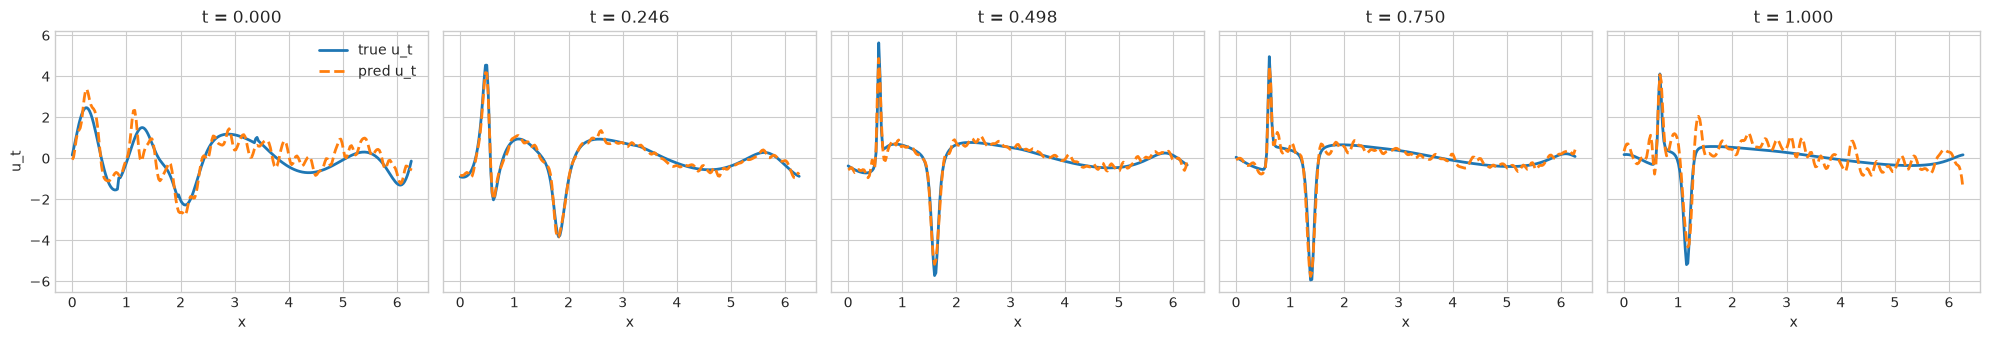

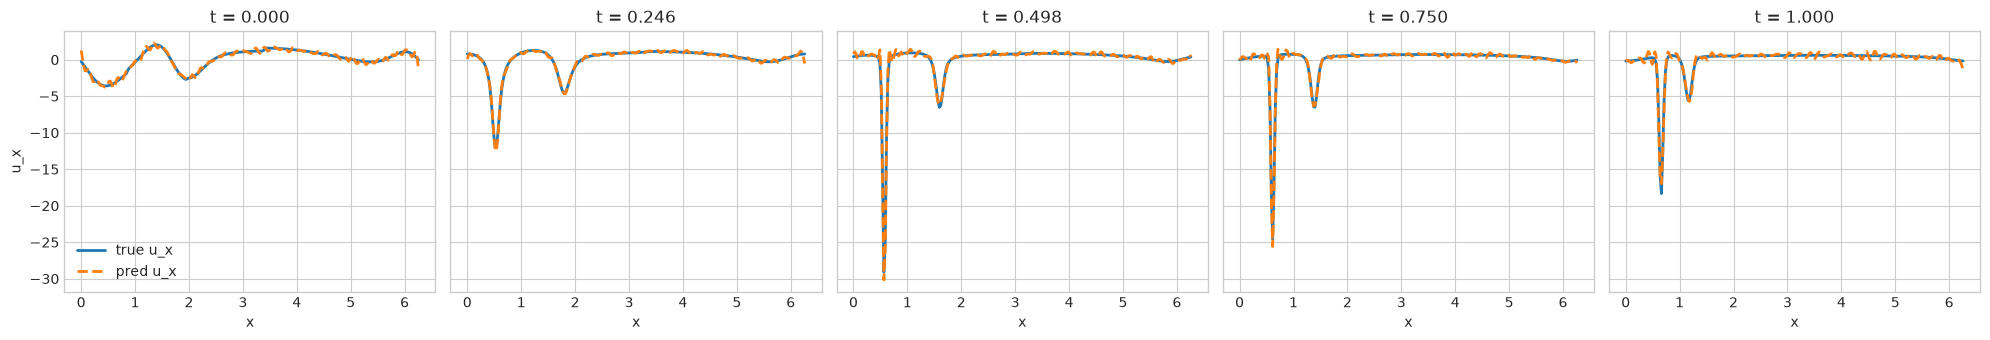

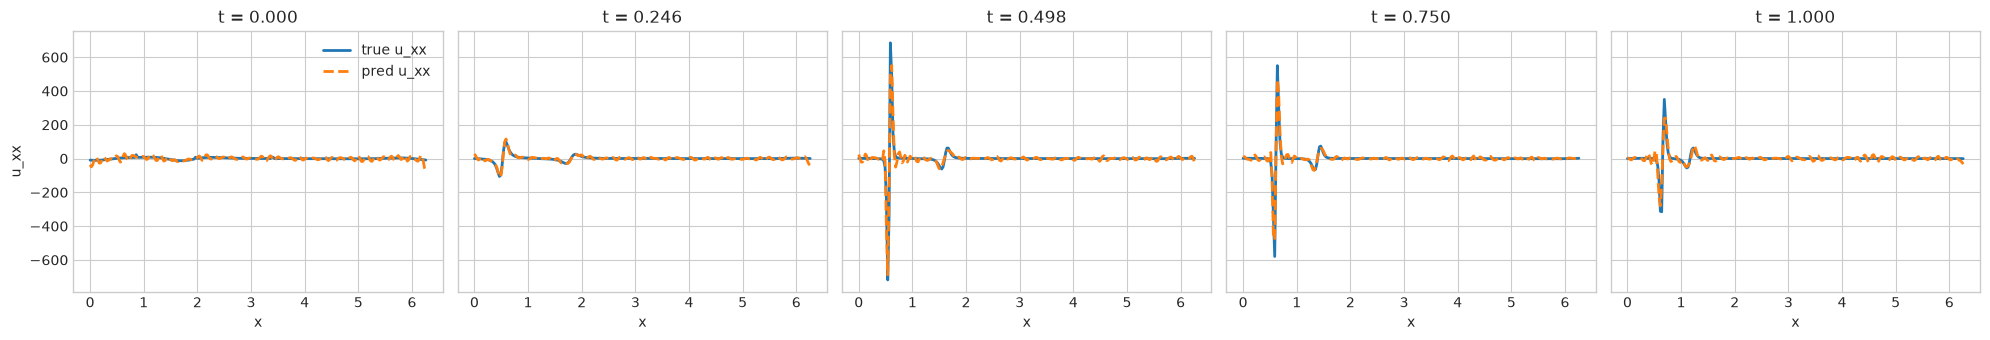

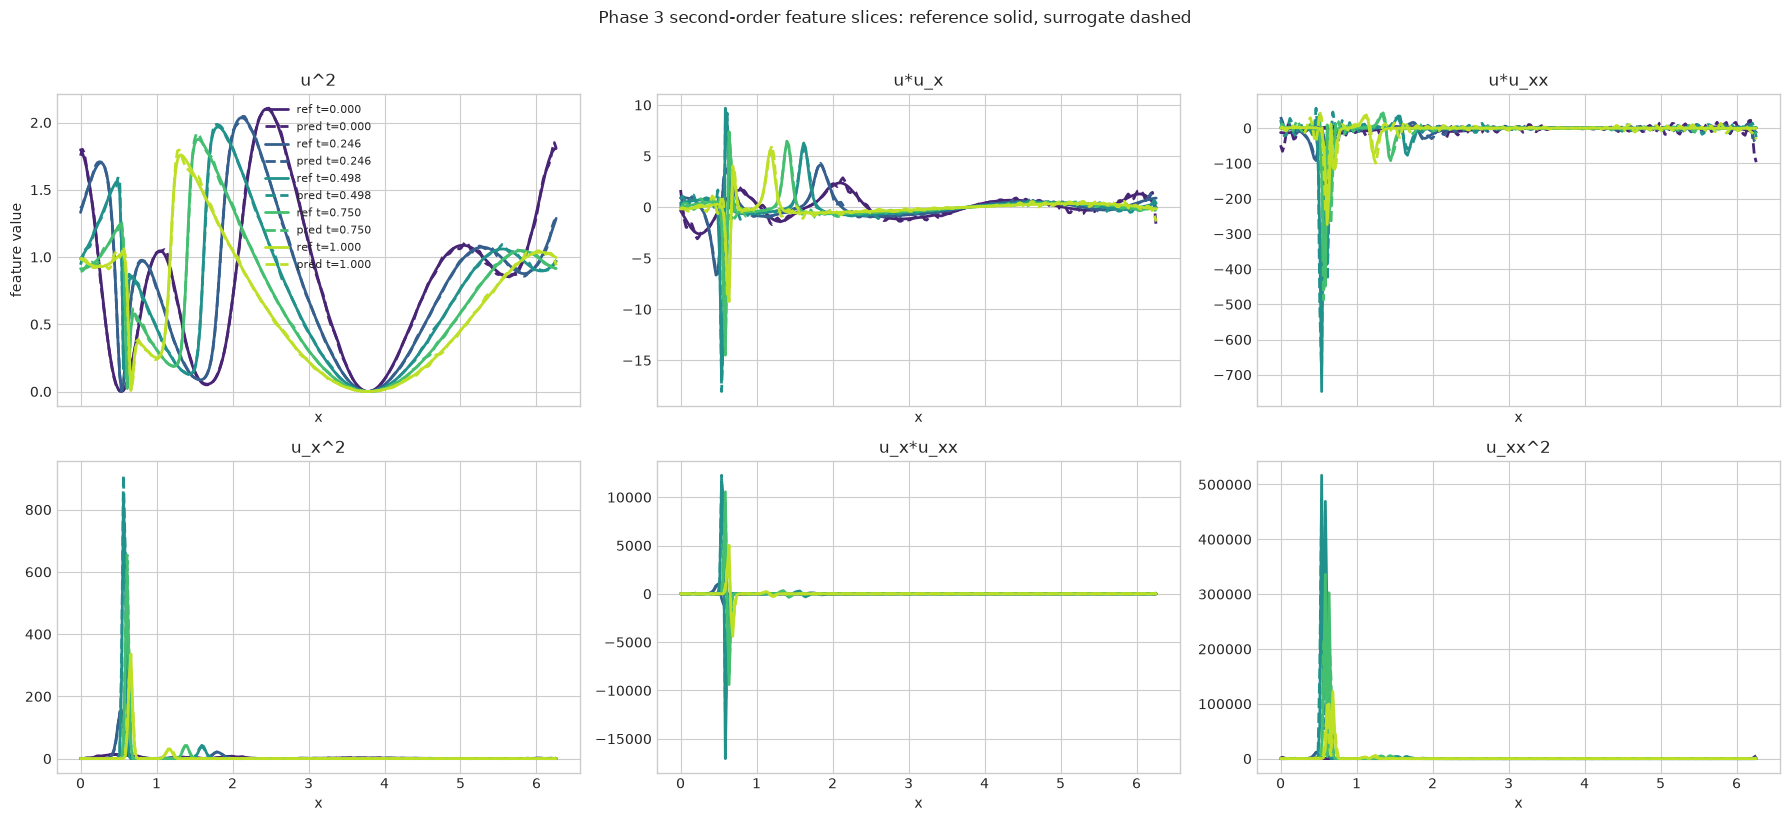

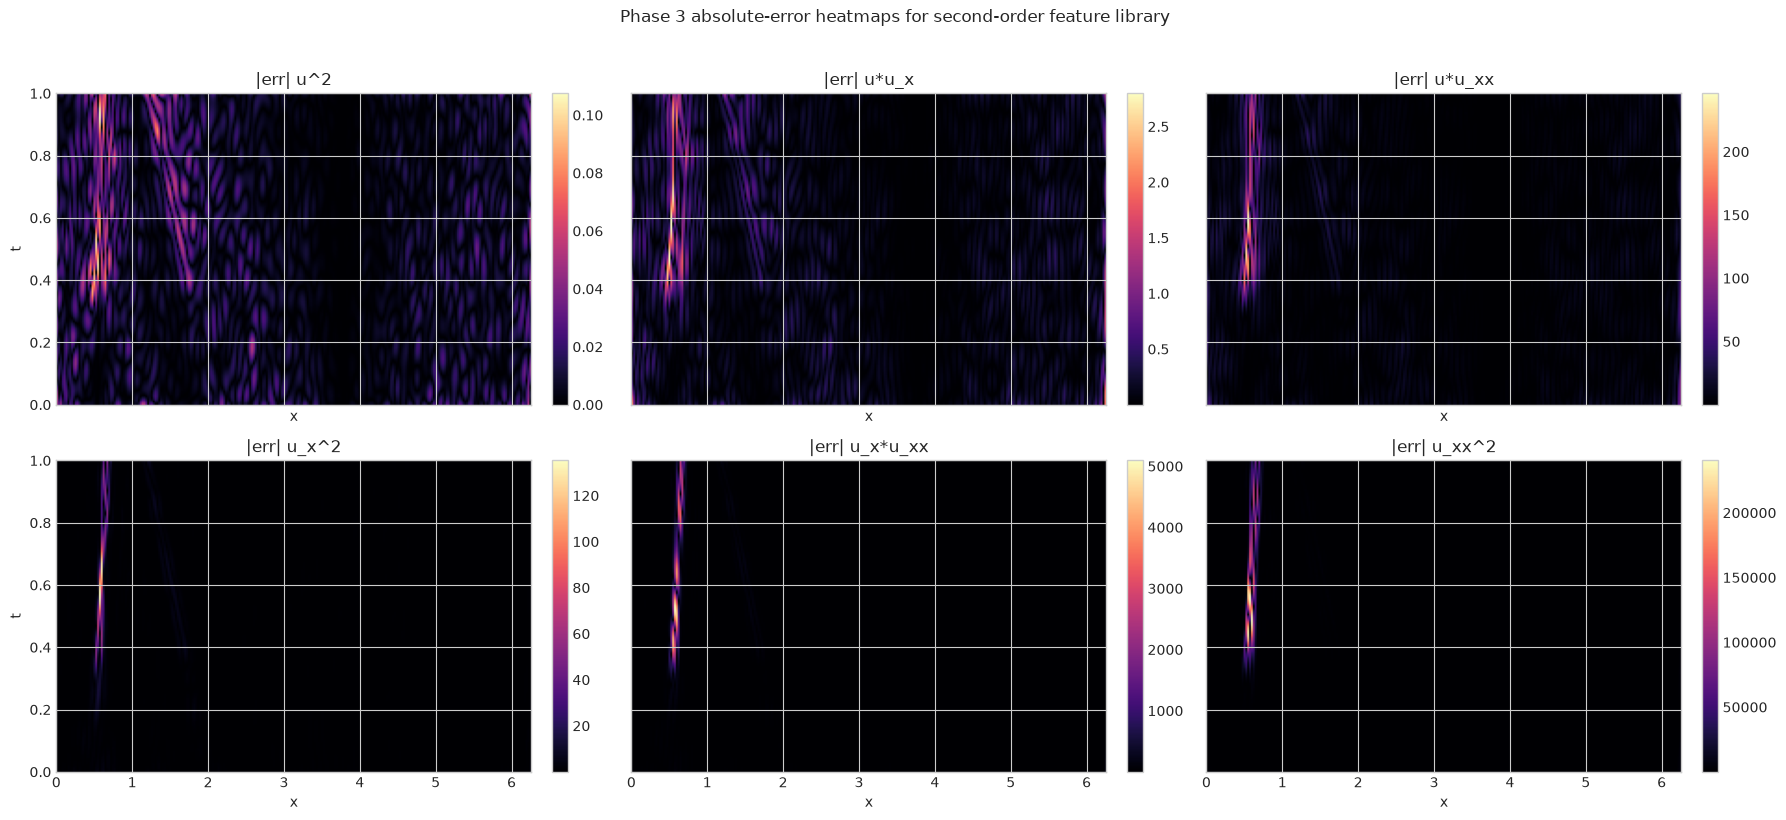

In [8]:
for quantity, ref_key in [("u_t", "u_t"), ("u_x", "u_x"), ("u_xx", "u_xx")]:
    plot_time_slices(
        x_grid,
        reference[ref_key]["physical"],
        pred_grid=surrogate_fields[quantity],
        time_values=t_grid,
        title_prefix=quantity,
        slice_indices=slice_indices,
    )

phase3_slice_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(slice_indices)))
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
axes = axes.ravel()
for ax, feature_name in zip(axes, phase3_second_order_feature_names):
    ref_grid = phase3_reference_feature_grids[feature_name]
    pred_grid = phase3_surrogate_feature_grids[feature_name]
    for color, idx in zip(phase3_slice_colors, slice_indices):
        label_ref = f"ref t={t_grid[idx]:.3f}"
        label_pred = f"pred t={t_grid[idx]:.3f}"
        ax.plot(x_grid, ref_grid[idx], color=color, linewidth=2, label=label_ref)
        ax.plot(x_grid, pred_grid[idx], color=color, linestyle="--", linewidth=2, label=label_pred)
    ax.set_title(feature_name)
    ax.set_xlabel("x")
axes[0].set_ylabel("feature value")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[: 2 * len(slice_indices)], labels[: 2 * len(slice_indices)], loc="best", fontsize=8)
fig.suptitle("Phase 3 second-order feature slices: reference solid, surrogate dashed", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.ravel()
for ax, feature_name in zip(axes, phase3_heatmap_feature_names):
    abs_err = np.abs(phase3_surrogate_feature_grids[feature_name] - phase3_reference_feature_grids[feature_name])
    im = ax.imshow(
        abs_err,
        aspect="auto",
        origin="lower",
        extent=[float(x_grid.min()), float(x_grid.max()), float(t_grid.min()), float(t_grid.max())],
        cmap="magma",
    )
    ax.set_title(f"|err| {feature_name}")
    ax.set_xlabel("x")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
axes[0].set_ylabel("t")
axes[3].set_ylabel("t")
fig.suptitle("Phase 3 absolute-error heatmaps for second-order feature library", y=1.02)
plt.tight_layout()
plt.show()

display(phase3_feature_rank_df[["mse", "rmse", "rel_l2", "max_abs"]])

phase3_rel_l2_lookup = phase3_feature_metrics_df["rel_l2"].to_dict()
phase3_u_xx_terms = ["u*u_xx", "u_x*u_xx", "u_xx^2"]
phase3_u_xx_term_df = phase3_feature_metrics_df.loc[phase3_u_xx_terms].sort_values("rel_l2")
phase3_trustworthy = [name for name in phase3_feature_names if phase3_rel_l2_lookup[name] < 0.2]
phase3_moderate = [name for name in phase3_feature_names if 0.2 <= phase3_rel_l2_lookup[name] < 0.3]
phase3_poorly_resolved = [name for name in phase3_feature_names if phase3_rel_l2_lookup[name] >= 0.3]
phase3_with_uxx = [name for name in phase3_feature_names if "u_xx" in name]
phase3_without_uxx = [name for name in phase3_feature_names if "u_xx" not in name and name != "u_t"]
phase3_median_with_uxx = float(np.median([phase3_rel_l2_lookup[name] for name in phase3_with_uxx]))
phase3_median_without_uxx = float(np.median([phase3_rel_l2_lookup[name] for name in phase3_without_uxx]))

print("Phase 3 interpretation")
print(f"- Feature errors generally increase once second derivatives enter the library: median rel_L2 for u_xx-containing terms = {phase3_median_with_uxx:.6f} versus {phase3_median_without_uxx:.6f} for terms without u_xx.")
print(f"- The true Burgers transport feature u*u_x has rel_L2 = {phase3_rel_l2_lookup['u*u_x']:.6f}, while u_xx-containing competitors span rel_L2 values {phase3_u_xx_term_df['rel_l2'].round(6).tolist()} for {phase3_u_xx_term_df.index.tolist()}.")
print(f"- Worst-resolved features by rel_L2 are {phase3_feature_rank_df.sort_values('rel_l2', ascending=False).head(3).index.tolist()}, which shows how u_xx error propagates into quadratic columns seen by SymNet.")
print(f"- Theta_pred versus Theta_ref has relative Frobenius error {phase3_theta_rel_frob:.6f}; condition numbers are {phase3_theta_ref_cond:.6e} (reference) and {phase3_theta_pred_cond:.6e} (surrogate).")
print(f"- Largest off-diagonal correlation shift is {float(phase3_corr_abs_diff[phase3_max_corr_shift_idx]):.6f} for {phase3_feature_names[phase3_max_corr_shift_idx[0]]} vs {phase3_feature_names[phase3_max_corr_shift_idx[1]]}.")
print(f"- Most trustworthy features at this stage (rel_L2 < 0.2): {phase3_trustworthy}.")
print(f"- Intermediate features at this stage (0.2 <= rel_L2 < 0.3): {phase3_moderate}.")
print(f"- Poorly resolved features at this stage (rel_L2 >= 0.3): {phase3_poorly_resolved}.")
print("- Conclusion: Phase 3 should be read as a diagnostic of the actual discovery matrix Theta, not only of primitive derivative fields, because u_xx errors can contaminate multiple competing quadratic columns simultaneously.")

## 4. Recover Burgers with Direct Least Squares

Question answered here: if we freeze the surrogate and use only the Burgers basis `[u*u_x, u_xx]`, do the surrogate derivatives contain enough information for ordinary least squares to recover `u_t = -u*u_x + 0.02*u_xx`?

In [9]:
theta = np.column_stack([
    (surrogate_fields["u"] * surrogate_fields["u_x"]).reshape(-1),
    surrogate_fields["u_xx"].reshape(-1),
])
y = surrogate_fields["u_t"].reshape(-1)

coeffs_ls, residuals_ls, rank_ls, singular_vals_ls = np.linalg.lstsq(theta, y, rcond=None)
ls_prediction = (theta @ coeffs_ls).reshape(u_grid.shape)
ls_residual_norm = float(np.linalg.norm(y - theta @ coeffs_ls))

print(f"rank(theta) = {rank_ls}")
print(f"singular values = {singular_vals_ls}")
print(f"least-squares residual L2 norm = {ls_residual_norm:.6e}")
print()
print(f"Recovered PDE: u_t = ({coeffs_ls[0]:+.6f}) * u*u_x + ({coeffs_ls[1]:+.6f}) * u_xx")
print(f"Compare c1 against -1.00  -> error = {coeffs_ls[0] + 1.0:+.6e}")
print(f"Compare c2 against +0.02 -> error = {coeffs_ls[1] - 0.02:+.6e}")

display(pd.DataFrame([
    {"coefficient": "u*u_x", "recovered": coeffs_ls[0], "truth": -1.0, "error": coeffs_ls[0] + 1.0},
    {"coefficient": "u_xx", "recovered": coeffs_ls[1], "truth": 0.02, "error": coeffs_ls[1] - 0.02},
]).set_index("coefficient"))

display(pd.DataFrame([
    as_metric_row("LS RHS vs surrogate u_t", ls_prediction, surrogate_fields["u_t"]),
]).set_index("quantity"))

rank(theta) = 2
singular values = [12545.342     269.15878]
least-squares residual L2 norm = 9.797658e+01

Recovered PDE: u_t = (-0.849441) * u*u_x + (+0.016593) * u_xx
Compare c1 against -1.00  -> error = +1.505594e-01
Compare c2 against +0.02 -> error = -3.406685e-03


             recovered  truth     error
coefficient                            
u*u_x        -0.849441  -1.00  0.150559
u_xx          0.016593   0.02 -0.003407

                            mse   rel_l2      rmse   max_abs
quantity                                                    
LS RHS vs surrogate u_t  0.1488  0.39375  0.385747  4.152788

## 5. Define a Minimal SymNet/EQL Model Directly in the Notebook

Question answered here: what is the smallest visible one-product architecture that can represent the Burgers right-hand side from inputs `[u, u_x, u_xx]`?

In [10]:
class MinimalSymNet(nn.Module):
    """
    Three primitive inputs: [u, u_x, u_xx]
    One product channel: (left(features)) * (right(features))
    Final readout: linear primitive term + weighted product term
    """

    def __init__(self):
        super().__init__()
        self.left = nn.Linear(3, 1, bias=False)
        self.right = nn.Linear(3, 1, bias=False)
        self.linear = nn.Linear(3, 1, bias=False)
        self.product_readout = nn.Linear(1, 1, bias=False)

    def forward(self, features):
        z_left = self.left(features)
        z_right = self.right(features)
        product = z_left * z_right
        linear_part = self.linear(features)
        return linear_part + self.product_readout(product)


symnet_demo = MinimalSymNet()
print(symnet_demo)
print()
print("forward map:")
print("z_left  = left([u, u_x, u_xx])")
print("z_right = right([u, u_x, u_xx])")
print("product = z_left * z_right")
print("output  = linear([u, u_x, u_xx]) + product_readout(product)")

MinimalSymNet(
  (left): Linear(in_features=3, out_features=1, bias=False)
  (right): Linear(in_features=3, out_features=1, bias=False)
  (linear): Linear(in_features=3, out_features=1, bias=False)
  (product_readout): Linear(in_features=1, out_features=1, bias=False)
)

forward map:
z_left  = left([u, u_x, u_xx])
z_right = right([u, u_x, u_xx])
product = z_left * z_right
output  = linear([u, u_x, u_xx]) + product_readout(product)


## 6. Hand-Set SymNet Weights to Burgers

Question answered here: without any training, can this minimal product architecture compute `-u*u_x + 0.02*u_xx` exactly when we assign the weights by hand?

In [11]:
symnet_exact = MinimalSymNet().to(device)
initialize_symnet_to_burgers(symnet_exact, diffusion=NU_TRUE)

print("left weight:")
print(symnet_exact.left.weight.detach().cpu().numpy())
print("right weight:")
print(symnet_exact.right.weight.detach().cpu().numpy())
print("linear weight:")
print(symnet_exact.linear.weight.detach().cpu().numpy())
print("product readout weight:")
print(symnet_exact.product_readout.weight.detach().cpu().numpy())

exact_coeffs = product_term_dict(symnet_exact)
print()
print("Expanded polynomial:")
print(pretty_equation(exact_coeffs))
print()
print("By inspection:")
print("left(features)  = u")
print("right(features) = u_x")
print("product_readout(left * right) = -1 * (u * u_x)")
print("linear(features) = 0.02 * u_xx")
print("total = -u*u_x + 0.02*u_xx")

reference_features = np.column_stack([
    reference["u"]["physical"].reshape(-1),
    reference["u_x"]["physical"].reshape(-1),
    reference["u_xx"]["physical"].reshape(-1),
]).astype(np.float32)

reference_rhs = (-reference["u"]["physical"] * reference["u_x"]["physical"] + NU_TRUE * reference["u_xx"]["physical"]).reshape(-1, 1)

with torch.no_grad():
    symnet_exact_rhs = symnet_exact(torch.tensor(reference_features, dtype=torch.float32, device=device)).cpu().numpy()

symnet_exact_metrics = pd.DataFrame([
    as_metric_row("hand-set SymNet vs exact Burgers RHS", symnet_exact_rhs.reshape(u_grid.shape), reference_rhs.reshape(u_grid.shape)),
]).set_index("quantity")
display(symnet_exact_metrics)

left weight:
[[1. 0. 0.]]
right weight:
[[0. 1. 0.]]
linear weight:
[[0.   0.   0.02]]
product readout weight:
[[-1.]]

Expanded polynomial:
u_t_hat = (+0.020000)*u_xx + (-1.000000)*u*u_x

By inspection:
left(features)  = u
right(features) = u_x
product_readout(left * right) = -1 * (u * u_x)
linear(features) = 0.02 * u_xx
total = -u*u_x + 0.02*u_xx


                                               mse        rel_l2          rmse   max_abs
quantity                                                                                
hand-set SymNet vs exact Burgers RHS  5.068321e-15  7.297652e-08  7.119214e-08  0.000002

## 7. Train SymNet Starting from the Exact Burgers Initialization

Question answered here: once the SIREN is frozen, if SymNet starts exactly at the Burgers formula and is trained only to match the surrogate's autodiff `u_t`, does it remain near Burgers or drift toward a different lower-loss representation?

In [12]:
frozen_feature_tensor = torch.tensor(
    np.column_stack([
        surrogate_fields["u"].reshape(-1),
        surrogate_fields["u_x"].reshape(-1),
        surrogate_fields["u_xx"].reshape(-1),
    ]).astype(np.float32),
    dtype=torch.float32,
    device=device,
)
frozen_ut_target = torch.tensor(
    surrogate_fields["u_t"].reshape(-1, 1).astype(np.float32),
    dtype=torch.float32,
    device=device,
)

symnet_frozen = MinimalSymNet().to(device)
initialize_symnet_to_burgers(symnet_frozen, diffusion=NU_TRUE)

symnet_steps = 400
symnet_lr = 1e-2
symnet_log_every = 40
symnet_optimizer = torch.optim.Adam(symnet_frozen.parameters(), lr=symnet_lr)
symnet_loss_fn = nn.MSELoss()

symnet_history = []

for step in range(symnet_steps + 1):
    pred_ut = symnet_frozen(frozen_feature_tensor)
    pde_loss = symnet_loss_fn(pred_ut, frozen_ut_target)

    coeffs = product_term_dict(symnet_frozen)
    row = {
        "step": step,
        "pde_loss": float(pde_loss.item()),
        "u": coeffs["u"],
        "u_x": coeffs["u_x"],
        "u_xx": coeffs["u_xx"],
        "u^2": coeffs["u^2"],
        "u*u_x": coeffs["u*u_x"],
        "u*u_xx": coeffs["u*u_xx"],
        "u_x^2": coeffs["u_x^2"],
        "u_x*u_xx": coeffs["u_x*u_xx"],
        "u_xx^2": coeffs["u_xx^2"],
    }
    symnet_history.append(row)

    if step % symnet_log_every == 0:
        print(
            f"step {step:4d} | pde_loss = {row['pde_loss']:.6e} | "
            f"c(u*u_x) = {row['u*u_x']:+.6f} | c(u_xx) = {row['u_xx']:+.6f} | "
            f"unwanted u^2 = {row['u^2']:+.6f} | unwanted u_x^2 = {row['u_x^2']:+.6f}"
        )

    if step == symnet_steps:
        break

    symnet_optimizer.zero_grad()
    pde_loss.backward()
    symnet_optimizer.step()

symnet_history_df = pd.DataFrame(symnet_history)
display(symnet_history_df.head())
print()
print("final expanded equation:")
print(pretty_equation(product_term_dict(symnet_frozen)))

step    0 | pde_loss = 1.746550e-01 | c(u*u_x) = -1.000000 | c(u_xx) = +0.020000 | unwanted u^2 = -0.000000 | unwanted u_x^2 = -0.000000
step   40 | pde_loss = 2.186110e-01 | c(u*u_x) = -0.695307 | c(u_xx) = +0.010342 | unwanted u^2 = -0.014776 | unwanted u_x^2 = +0.001101
step   80 | pde_loss = 1.313332e-01 | c(u*u_x) = -0.705697 | c(u_xx) = +0.006769 | unwanted u^2 = -0.013044 | unwanted u_x^2 = +0.002574
step  120 | pde_loss = 1.085427e-01 | c(u*u_x) = -0.741770 | c(u_xx) = +0.008436 | unwanted u^2 = -0.017315 | unwanted u_x^2 = +0.002724
step  160 | pde_loss = 1.004459e-01 | c(u*u_x) = -0.776743 | c(u_xx) = +0.008841 | unwanted u^2 = -0.022962 | unwanted u_x^2 = +0.002949
step  200 | pde_loss = 9.584283e-02 | c(u*u_x) = -0.806387 | c(u_xx) = +0.009225 | unwanted u^2 = -0.022383 | unwanted u_x^2 = +0.002717
step  240 | pde_loss = 9.310853e-02 | c(u*u_x) = -0.830350 | c(u_xx) = +0.009505 | unwanted u^2 = -0.020300 | unwanted u_x^2 = +0.002281
step  280 | pde_loss = 9.150402e-02 | c(u

   step   pde_loss         u       u_x      u_xx       u^2     u*u_x    u*u_xx     u_x^2  u_x*u_xx    u_xx^2
0     0   0.174655  0.000000  0.000000  0.020000 -0.000000 -1.000000 -0.000000 -0.000000 -0.000000 -0.000000
1     1  55.571529  0.010000  0.010000  0.010000  0.009801 -0.970200 -0.009702 -0.009801 -0.009900 -0.000099
2     2   1.357876  0.017605  0.002698  0.002537  0.002553 -0.962793 -0.002522 -0.002617 -0.002571 -0.000007
3     3  14.336781  0.023792 -0.003450 -0.004037 -0.003084 -0.957287  0.003152  0.003168  0.003641 -0.000012
4     4  30.290697  0.024825 -0.008706 -0.005994 -0.008257 -0.947501  0.008260  0.008157  0.005898 -0.000052

     step  pde_loss         u       u_x      u_xx       u^2     u*u_x    u*u_xx     u_x^2  u_x*u_xx    u_xx^2
396   396  0.089969 -0.026598  0.038616  0.010041 -0.012032 -0.880637 -0.003643  0.000822 -0.000599 -0.000002
397   397  0.089965 -0.026573  0.038521  0.010042 -0.012002 -0.880796 -0.003642  0.000817 -0.000599 -0.000002
398   398  0.089961 -0.026548  0.038427  0.010044 -0.011971 -0.880953 -0.003640  0.000812 -0.000599 -0.000002
399   399  0.089958 -0.026523  0.038333  0.010046 -0.011941 -0.881108 -0.003638  0.000806 -0.000599 -0.000002
400   400  0.089954 -0.026498  0.038241  0.010047 -0.011912 -0.881262 -0.003637  0.000801 -0.000599 -0.000002

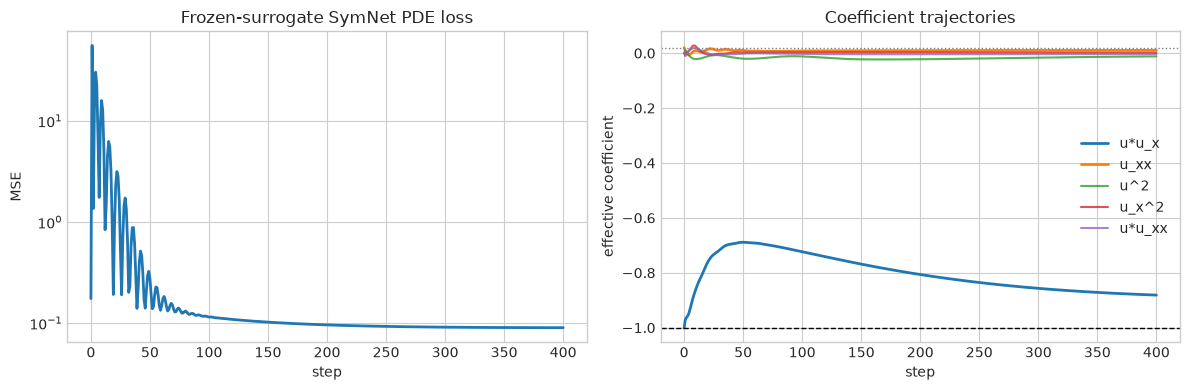

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(symnet_history_df["step"], symnet_history_df["pde_loss"], linewidth=2)
axes[0].set_title("Frozen-surrogate SymNet PDE loss")
axes[0].set_xlabel("step")
axes[0].set_ylabel("MSE")
axes[0].set_yscale("log")

axes[1].plot(symnet_history_df["step"], symnet_history_df["u*u_x"], label="u*u_x", linewidth=2)
axes[1].plot(symnet_history_df["step"], symnet_history_df["u_xx"], label="u_xx", linewidth=2)
axes[1].plot(symnet_history_df["step"], symnet_history_df["u^2"], label="u^2", alpha=0.8)
axes[1].plot(symnet_history_df["step"], symnet_history_df["u_x^2"], label="u_x^2", alpha=0.8)
axes[1].plot(symnet_history_df["step"], symnet_history_df["u*u_xx"], label="u*u_xx", alpha=0.8)
axes[1].axhline(-1.0, color="black", linestyle="--", linewidth=1)
axes[1].axhline(0.02, color="gray", linestyle=":", linewidth=1)
axes[1].set_title("Coefficient trajectories")
axes[1].set_xlabel("step")
axes[1].set_ylabel("effective coefficient")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

display(symnet_history_df.tail())

## 8. Optional Next Experiment: Joint SIREN + SymNet Training

Question answered here: if we start from the same exact Burgers SymNet initialization but now let both the surrogate and SymNet move, how do the data loss, PDE loss, derivative fidelity, Burgers coefficients, and weight drift compare against the frozen-surrogate case above?

This section is intentionally off by default so it does not obscure the simpler experiments.

In [14]:
RUN_OPTIONAL_JOINT = False
joint_steps = 300
joint_batch_size = 4096
joint_lr = 5e-4
joint_lambda_pde = 1.0
joint_log_every = 50

if RUN_OPTIONAL_JOINT:
    joint_siren = copy.deepcopy(siren).to(device)
    joint_symnet = MinimalSymNet().to(device)
    initialize_symnet_to_burgers(joint_symnet, diffusion=NU_TRUE)

    joint_optimizer = torch.optim.Adam(
        list(joint_siren.parameters()) + list(joint_symnet.parameters()),
        lr=joint_lr,
    )
    joint_history = []

    for step in range(joint_steps + 1):
        idx = torch.randint(0, len(t_train), (joint_batch_size,), device=device)
        t_batch = t_train[idx].clone().detach().requires_grad_(True)
        x_batch = x_train[idx].clone().detach().requires_grad_(True)
        u_batch_true = u_train[idx]

        u_batch_pred = joint_siren(t_batch, x_batch)
        ut_batch = torch.autograd.grad(
            u_batch_pred,
            t_batch,
            grad_outputs=torch.ones_like(u_batch_pred),
            create_graph=True,
            retain_graph=True,
        )[0]
        ux_batch = torch.autograd.grad(
            u_batch_pred,
            x_batch,
            grad_outputs=torch.ones_like(u_batch_pred),
            create_graph=True,
            retain_graph=True,
        )[0]
        uxx_batch = torch.autograd.grad(
            ux_batch,
            x_batch,
            grad_outputs=torch.ones_like(ux_batch),
            create_graph=True,
            retain_graph=True,
        )[0]

        feat_batch = torch.cat([u_batch_pred, ux_batch, uxx_batch], dim=1)
        rhs_batch = joint_symnet(feat_batch)

        data_loss = loss_fn(u_batch_pred, u_batch_true)
        pde_loss = loss_fn(ut_batch, rhs_batch)
        total_loss = data_loss + joint_lambda_pde * pde_loss

        if step % joint_log_every == 0:
            full_fields = evaluate_model_and_derivatives_in_chunks(
                joint_siren,
                t_flat=t_flat,
                x_flat=x_flat,
                grid_shape=u_grid.shape,
                chunk_size=4096,
                device=device,
            )
            coeffs = product_term_dict(joint_symnet)
            joint_history.append({
                "step": step,
                "data_loss": float(data_loss.item()),
                "pde_loss": float(pde_loss.item()),
                "u_rel_l2": compute_error_metrics(full_fields["u"], u_grid)["rel_l2"],
                "ut_rel_l2": compute_error_metrics(full_fields["u_t"], reference["u_t"]["physical"])["rel_l2"],
                "ux_rel_l2": compute_error_metrics(full_fields["u_x"], reference["u_x"]["physical"])["rel_l2"],
                "uxx_rel_l2": compute_error_metrics(full_fields["u_xx"], reference["u_xx"]["physical"])["rel_l2"],
                "u*u_x": coeffs["u*u_x"],
                "u_xx": coeffs["u_xx"],
                "u^2": coeffs["u^2"],
                "u_x^2": coeffs["u_x^2"],
            })
            print(
                f"joint step {step:4d} | data_loss = {float(data_loss.item()):.6e} | "
                f"pde_loss = {float(pde_loss.item()):.6e} | c(u*u_x) = {coeffs['u*u_x']:+.6f} | c(u_xx) = {coeffs['u_xx']:+.6f}"
            )

        if step == joint_steps:
            break

        joint_optimizer.zero_grad()
        total_loss.backward()
        joint_optimizer.step()

    joint_history_df = pd.DataFrame(joint_history)
    display(joint_history_df)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(joint_history_df["step"], joint_history_df["data_loss"], label="data_loss")
    axes[0].plot(joint_history_df["step"], joint_history_df["pde_loss"], label="pde_loss")
    axes[0].set_yscale("log")
    axes[0].set_title("Joint losses")
    axes[0].legend(loc="best")

    axes[1].plot(joint_history_df["step"], joint_history_df["u*u_x"], label="u*u_x")
    axes[1].plot(joint_history_df["step"], joint_history_df["u_xx"], label="u_xx")
    axes[1].plot(joint_history_df["step"], joint_history_df["u^2"], label="u^2")
    axes[1].plot(joint_history_df["step"], joint_history_df["u_x^2"], label="u_x^2")
    axes[1].set_title("Joint coefficient drift")
    axes[1].legend(loc="best")

    axes[2].plot(joint_history_df["step"], joint_history_df["u_rel_l2"], label="u")
    axes[2].plot(joint_history_df["step"], joint_history_df["ut_rel_l2"], label="u_t")
    axes[2].plot(joint_history_df["step"], joint_history_df["ux_rel_l2"], label="u_x")
    axes[2].plot(joint_history_df["step"], joint_history_df["uxx_rel_l2"], label="u_xx")
    axes[2].set_title("Derivative fidelity during joint training")
    axes[2].legend(loc="best")

    plt.tight_layout()
    plt.show()
else:
    print("Optional joint experiment skipped. Set RUN_OPTIONAL_JOINT = True to execute it.")

Optional joint experiment skipped. Set RUN_OPTIONAL_JOINT = True to execute it.


## 9. Randomly Initialized SymNet, Frozen Surrogate

Question answered here: keeping the surrogate fixed, can the same minimal SymNet architecture find Burgers from ordinary random initialization when it is trained only against the frozen surrogate derivative field?
The diagnostic below evaluates the unchanged data-only `siren` over the full grid and checks that it matches the frozen SymNet inputs and target; derivative references are the same physical-coordinate references as Phase 3 (periodic centered spatial differences and the clean-state Burgers RHS for `u_t`). Reuse the five true-versus-predicted solution slices in Phase 2 for this exact surrogate.


In [15]:
# Diagnostic copies only: never normalize or replace the training tensor.
phase9_scale_primitives = frozen_feature_tensor.detach().cpu().numpy().copy()
phase9_scale_feature_names = list(phase3_feature_names)


def frozen_feature_scale_table(primitive_values):
    values = np.asarray(primitive_values, dtype=np.float64)
    if values.ndim != 2 or values.shape[1] != 3 or not len(values):
        raise ValueError("Expected a nonempty frozen [u, u_x, u_xx] matrix")
    if not np.isfinite(values).all():
        raise ValueError("Frozen feature matrix contains nonfinite values")
    # Reuse the notebook's degree-2 library; float64 is for diagnostic reductions only.
    library = build_minimal_feature_library(dict(zip(["u", "u_x", "u_xx"], values.T)))
    return pd.DataFrame([
        {"feature": name,
         "RMS magnitude": float(np.sqrt(np.mean(library[name] ** 2))),
         "L2 column norm": float(np.linalg.norm(library[name])),
         "max absolute value": float(np.max(np.abs(library[name])))}
        for name in phase9_scale_feature_names
    ]).set_index("feature")


def feature_scale_ratios(table):
    ratios = {}
    for column in ["RMS magnitude", "L2 column norm"]:
        smallest, largest = float(table[column].min()), float(table[column].max())
        # Do not hide zero columns by dropping them or adding epsilon.
        ratios[column] = largest / smallest if smallest > 0 else (np.inf if largest > 0 else np.nan)
    return ratios


def print_feature_scales(table, label):
    print(label + " (raw, unscaled; first three rows are primitive features)")
    print(table.to_string(float_format=lambda value: f"{value:.6e}"))
    for scope, subset in [("primitives", table.loc[["u", "u_x", "u_xx"]]),
                          ("full degree-2 library", table)]:
        ratios = feature_scale_ratios(subset)
        print(f"{scope}: largest RMS / smallest RMS = {ratios['RMS magnitude']:.6e}; "
              f"largest L2 norm / smallest L2 norm = {ratios['L2 column norm']:.6e}")


phase9_feature_scale_table = frozen_feature_scale_table(phase9_scale_primitives)
phase9_feature_scale_ratios = feature_scale_ratios(phase9_feature_scale_table)
print_feature_scales(phase9_feature_scale_table, "Phase 9 frozen feature scales")


Phase 9 frozen feature scales (raw, unscaled; first three rows are primitive features)
          RMS magnitude  L2 column norm  max absolute value
feature                                                    
u          8.564483e-01    2.175311e+02        1.451401e+00
u_x        2.418017e+00    6.141574e+02        3.033428e+01
u_xx       4.938278e+01    1.254284e+04        7.341176e+02
u^2        9.075268e-01    2.305047e+02        2.106566e+00
u*u_x      1.447974e+00    3.677739e+02        1.928072e+01
u*u_xx     4.144839e+01    1.052756e+04        8.009168e+02
u_x^2      4.665504e+01    1.185001e+04        9.201687e+02
u_x*u_xx   7.455484e+02    1.893634e+05        1.560460e+04
u_xx^2     2.336090e+04    5.933485e+06        5.389286e+05
primitives: largest RMS / smallest RMS = 5.765997e+01; largest L2 norm / smallest L2 norm = 5.765997e+01
full degree-2 library: largest RMS / smallest RMS = 2.727649e+04; largest L2 norm / smallest L2 norm = 2.727649e+04


In [16]:
# Diagnose the unchanged data-only SIREN that supplied the frozen tensors.
# Input autodiff is needed for derivatives; no parameter update is performed.
phase9_siren_training_mode = siren.training
try:
    phase9_surrogate_fields = evaluate_model_and_derivatives_in_chunks(
        siren,
        t_flat=t_flat,
        x_flat=x_flat,
        grid_shape=u_grid.shape,
        chunk_size=4096,
        device=device,
    )
finally:
    siren.train(phase9_siren_training_mode)

# Catch out-of-order execution that would diagnose a different surrogate field.
for phase9_column, phase9_name in enumerate(["u", "u_x", "u_xx"]):
    np.testing.assert_allclose(
        phase9_surrogate_fields[phase9_name].reshape(-1),
        frozen_feature_tensor[:, phase9_column].detach().cpu().numpy(),
        rtol=1e-5, atol=1e-6,
        err_msg="Phase 9 diagnostic surrogate does not match the frozen SymNet inputs",
    )
np.testing.assert_allclose(
    phase9_surrogate_fields["u_t"].reshape(-1),
    frozen_ut_target.detach().cpu().numpy().reshape(-1),
    rtol=1e-5, atol=1e-6,
    err_msg="Phase 9 diagnostic surrogate does not match the frozen SymNet target",
)

# Same physical-coordinate derivative reference as Phase 3; u uses clean data directly.
phase9_surrogate_metrics = pd.DataFrame([
    as_metric_row(
        name, phase9_surrogate_fields[name],
        u_grid if name == "u" else reference[name]["physical"],
    )
    for name in ["u", "u_t", "u_x", "u_xx"]
]).set_index("quantity")[["mse", "rmse", "rel_l2", "max_abs"]]
phase9_full_grid_surrogate_data_mse = float(phase9_surrogate_metrics.loc["u", "mse"])
print(f"\nFULL-GRID SURROGATE DATA MSE = {phase9_full_grid_surrogate_data_mse:.6e}\n")
print(phase9_surrogate_metrics.rename(columns={
    "mse": "MSE", "rmse": "RMSE", "rel_l2": "relative L2 error",
    "max_abs": "max absolute error",
}).to_string(float_format=lambda value: f"{value:.6e}"))
print("Solution slices: reuse the five true-vs-predicted u slices in Phase 2 (same frozen SIREN).")



FULL-GRID SURROGATE DATA MSE = 5.603034e-05

                  MSE         RMSE  relative L2 error  max absolute error
quantity                                                                 
u        5.603034e-05 7.485342e-03       8.738905e-03        6.740668e-02
u_t      3.553359e-02 1.885035e-01       1.932282e-01        1.646756e+00
u_x      7.615923e-02 2.759696e-01       1.180107e-01        2.759550e+00
u_xx     2.657628e+02 1.630223e+01       3.212108e-01        2.135873e+02
Solution slices: reuse the five true-vs-predicted u slices in Phase 2 (same frozen SIREN).


In [17]:
torch.manual_seed(SEED)
random_frozen_epochs = 1000
random_frozen_lr = 1e-2
random_frozen_checkpoints = sorted({0, 100, 500, 1000, random_frozen_epochs})
random_frozen_loss_fn = nn.MSELoss()

random_frozen_symnet = MinimalSymNet().to(device)
initial_random_frozen_coeffs = product_term_dict(random_frozen_symnet)
initial_random_frozen_pde_mse = float(
    random_frozen_loss_fn(random_frozen_symnet(frozen_feature_tensor), frozen_ut_target).item()
)

print("initial SymNet effective equation:")
print(pretty_equation(initial_random_frozen_coeffs))
print(f"initial PDE MSE = {initial_random_frozen_pde_mse:.6e}")
display(pd.DataFrame([initial_random_frozen_coeffs]).T.rename(columns={0: "initial_coefficient"}))

random_frozen_optimizer = torch.optim.Adam(random_frozen_symnet.parameters(), lr=random_frozen_lr)
random_frozen_loss_history = []
random_frozen_coeff_history = []

for epoch in range(random_frozen_epochs + 1):
    pred_ut = random_frozen_symnet(frozen_feature_tensor)
    pde_loss = random_frozen_loss_fn(pred_ut, frozen_ut_target)

    random_frozen_loss_history.append({
        "epoch": epoch,
        "pde_loss": float(pde_loss.item()),
    })

    if epoch in random_frozen_checkpoints:
        coeffs = product_term_dict(random_frozen_symnet)
        coeff_row = {"epoch": epoch, "pde_loss": float(pde_loss.item())}
        coeff_row.update(coeffs)
        random_frozen_coeff_history.append(coeff_row)
        print(f"epoch {epoch:4d} | raw PDE MSE = {float(pde_loss.item()):.6e}")
        print(pretty_equation(coeffs))

    if epoch == random_frozen_epochs:
        break

    random_frozen_optimizer.zero_grad()
    pde_loss.backward()
    random_frozen_optimizer.step()

random_frozen_loss_df = pd.DataFrame(random_frozen_loss_history)
random_frozen_coeff_df = pd.DataFrame(random_frozen_coeff_history)
final_random_frozen_coeffs = product_term_dict(random_frozen_symnet)
random_frozen_summary = {
    "optimizer": "Adam",
    "learning_rate": random_frozen_lr,
    "epochs": random_frozen_epochs,
    "initial_pde_mse": initial_random_frozen_pde_mse,
    "final_pde_mse": float(random_frozen_loss_df.iloc[-1]["pde_loss"]),
    "initial_equation": pretty_equation(initial_random_frozen_coeffs),
    "final_equation": pretty_equation(final_random_frozen_coeffs),
    "final_uux_coeff": float(final_random_frozen_coeffs["u*u_x"]),
    "final_uxx_coeff": float(final_random_frozen_coeffs["u_xx"]),
    "hand_init_final_pde_mse": float(symnet_history_df.iloc[-1]["pde_loss"]),
    "hand_init_final_uux_coeff": float(symnet_history_df.iloc[-1]["u*u_x"]),
    "hand_init_final_uxx_coeff": float(symnet_history_df.iloc[-1]["u_xx"]),
}

display(random_frozen_coeff_df)
print("initial equation:")
print(random_frozen_summary["initial_equation"])
print("final equation:")
print(random_frozen_summary["final_equation"])
print(f"recovered coeff(u*u_x) = {random_frozen_summary['final_uux_coeff']:+.6f} (truth -1.000000)")
print(f"recovered coeff(u_xx)  = {random_frozen_summary['final_uxx_coeff']:+.6f} (truth +0.020000)")
print(f"final PDE MSE = {random_frozen_summary['final_pde_mse']:.6e}")
print()
print("comparison to the hand-initialized frozen-surrogate run:")
print(f"hand-init final PDE MSE = {random_frozen_summary['hand_init_final_pde_mse']:.6e}")
print(f"hand-init final coeff(u*u_x) = {random_frozen_summary['hand_init_final_uux_coeff']:+.6f}")
print(f"hand-init final coeff(u_xx)  = {random_frozen_summary['hand_init_final_uxx_coeff']:+.6f}")


initial SymNet effective equation:
u_t_hat = (-0.011439)*u + (+0.457775)*u_x + (-0.051236)*u_xx + (+0.000486)*u^2 + (-0.034568)*u*u_x + (+0.053249)*u*u_xx + (-0.018224)*u_x^2 + (+0.040649)*u_x*u_xx + (-0.019467)*u_xx^2
initial PDE MSE = 2.064857e+05
epoch    0 | raw PDE MSE = 2.064857e+05
u_t_hat = (-0.011439)*u + (+0.457775)*u_x + (-0.051236)*u_xx + (+0.000486)*u^2 + (-0.034568)*u*u_x + (+0.053249)*u*u_xx + (-0.018224)*u_x^2 + (+0.040649)*u_x*u_xx + (-0.019467)*u_xx^2
epoch  100 | raw PDE MSE = 1.900342e+01
u_t_hat = (-0.021286)*u + (+0.296798)*u_x + (+0.056132)*u_xx + (+0.004213)*u^2 + (-0.004107)*u*u_x + (+0.008244)*u*u_xx + (-0.001365)*u_x^2 + (+0.001991)*u_x*u_xx + (+0.000218)*u_xx^2
epoch  500 | raw PDE MSE = 1.112197e+00
u_t_hat = (-0.136236)*u + (+0.256814)*u_x + (+0.002197)*u_xx + (+0.004264)*u^2 + (-0.005177)*u*u_x + (+0.008234)*u*u_xx + (-0.000094)*u_x^2 + (+0.000122)*u_x*u_xx + (+0.000038)*u_xx^2
epoch 1000 | raw PDE MSE = 9.651142e-01
u_t_hat = (-0.166766)*u + (+0.163397)*

          initial_coefficient
u                   -0.011439
u_x                  0.457775
u_xx                -0.051236
u^2                  0.000486
u*u_x               -0.034568
u*u_xx               0.053249
u_x^2               -0.018224
u_x*u_xx             0.040649
u_xx^2              -0.019467

   epoch       pde_loss         u       u_x      u_xx       u^2     u*u_x    u*u_xx     u_x^2  u_x*u_xx    u_xx^2
0      0  206485.718750 -0.011439  0.457775 -0.051236  0.000486 -0.034568  0.053249 -0.018224  0.040649 -0.019467
1    100      19.003422 -0.021286  0.296798  0.056132  0.004213 -0.004107  0.008244 -0.001365  0.001991  0.000218
2    500       1.112197 -0.136236  0.256814  0.002197  0.004264 -0.005177  0.008234 -0.000094  0.000122  0.000038
3   1000       0.965114 -0.166766  0.163397 -0.001735  0.004231 -0.005406  0.008171  0.000067 -0.000123  0.000032

   epoch       pde_loss         u       u_x      u_xx       u^2     u*u_x    u*u_xx     u_x^2  u_x*u_xx    u_xx^2
0      0  206485.718750 -0.011439  0.457775 -0.051236  0.000486 -0.034568  0.053249 -0.018224  0.040649 -0.019467
1    100      19.003422 -0.021286  0.296798  0.056132  0.004213 -0.004107  0.008244 -0.001365  0.001991  0.000218
2    500       1.112197 -0.136236  0.256814  0.002197  0.004264 -0.005177  0.008234 -0.000094  0.000122  0.000038
3   1000       0.965114 -0.166766  0.163397 -0.001735  0.004231 -0.005406  0.008171  0.000067 -0.000123  0.000032

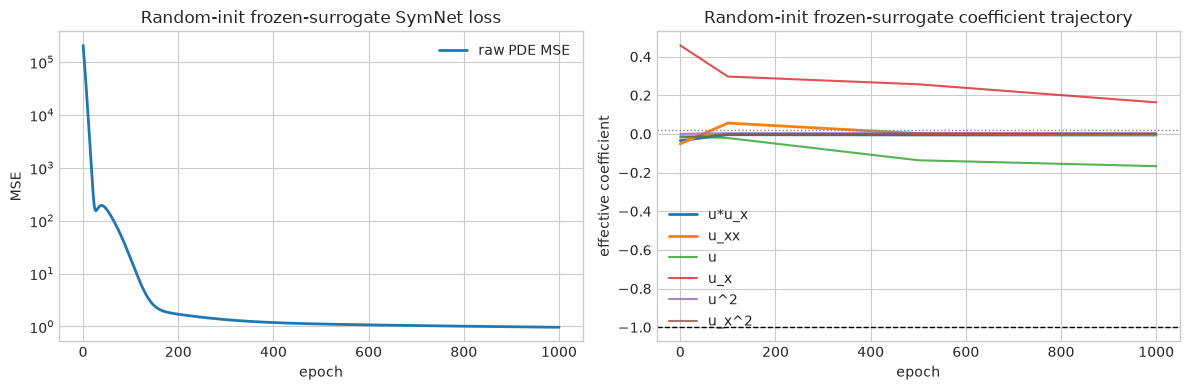

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(random_frozen_loss_df["epoch"], random_frozen_loss_df["pde_loss"], label="raw PDE MSE", linewidth=2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Random-init frozen-surrogate SymNet loss")
axes[0].legend(loc="best")

axes[1].plot(random_frozen_coeff_df["epoch"], random_frozen_coeff_df["u*u_x"], label="u*u_x", linewidth=2)
axes[1].plot(random_frozen_coeff_df["epoch"], random_frozen_coeff_df["u_xx"], label="u_xx", linewidth=2)
axes[1].plot(random_frozen_coeff_df["epoch"], random_frozen_coeff_df["u"], label="u", alpha=0.8)
axes[1].plot(random_frozen_coeff_df["epoch"], random_frozen_coeff_df["u_x"], label="u_x", alpha=0.8)
axes[1].plot(random_frozen_coeff_df["epoch"], random_frozen_coeff_df["u^2"], label="u^2", alpha=0.8)
axes[1].plot(random_frozen_coeff_df["epoch"], random_frozen_coeff_df["u_x^2"], label="u_x^2", alpha=0.8)
axes[1].axhline(-1.0, color="black", linestyle="--", linewidth=1)
axes[1].axhline(0.02, color="gray", linestyle=":", linewidth=1)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("effective coefficient")
axes[1].set_title("Random-init frozen-surrogate coefficient trajectory")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

display(random_frozen_coeff_df[["epoch", "pde_loss", "u", "u_x", "u_xx", "u^2", "u*u_x", "u*u_xx", "u_x^2", "u_x*u_xx", "u_xx^2"]])


### Section 9 Interpretation

- Did random initialization converge to the same basin as the hand-initialized run? No. On September 3, 2026, the random-init frozen-surrogate run converged to a different basin dominated by linear `u` and `u_x` terms instead of the Burgers `u*u_x` plus `u_xx` structure.
- Did it reach a similarly low PDE loss? No. Its final PDE MSE was about `9.65e-01`, versus about `8.996e-02` for the hand-initialized frozen-surrogate run.
- Did it recover the same support? No. The final effective equation retained large spurious linear terms and drove `u*u_x` and `u_xx` close to zero rather than isolating the Burgers support.
- Did it recover approximately correct Burgers coefficients? No. The final coefficients were `coeff(u*u_x) = -0.005406` and `coeff(u_xx) = -0.001735`, far from `-1.0` and `+0.02`.
- Did it settle into a different low-loss equation? Yes. The frozen surrogate admits a non-Burgers equation with lower loss than the random start but clearly not the Burgers basin, so this section is best described as case B: lower loss with wrong coefficients and wrong support.
For the saved run, the solution fit `u` is good (~0.87% relative L2 error), but derivative fidelity is poor for a clean optimization control (~12–32% errors), so confidence in Phase 9 as a pure SymNet optimization test is limited by surrogate error.


## 9B. Random Initialization Reliability Across Seeds and Training Horizon

Phase 9 above is preserved as the original single-seed, 1,000-epoch demonstration. Phase 16 showed that additional optimization time can improve some structured initializations. Phase 9B tests whether the same phenomenon rescues ordinary random initialization. Each seed below follows one continuous trajectory to 5,000 epochs on the exact frozen surrogate and feature field; checkpoints are observations, not restarts. The optimizer, learning rate, loss, architecture, coefficient extraction, and physical references are unchanged.


In [1]:
# Phase 9B changes only the seed count and training horizon; no input is normalized.
phase9b_seeds = list(range(20))
phase9b_max_epochs = 5000
phase9b_checkpoints = [0, 100, 500, 1000, 2000, 3000, 5000]
phase9b_feature_names = ["u", "u_x", "u_xx", "u^2", "u*u_x", "u*u_xx", "u_x^2", "u_x*u_xx", "u_xx^2"]
phase9b_ls_fallback = np.array([-0.02660689502954483, 0.031647738069295883, 0.009979595430195332, -0.0048546576872468, -0.8924551010131836, -0.002123536774888635, 0.000003829637535091024, -0.0006162812933325768, 0.00000110644759843126], dtype=np.float64)
phase9b_true_fallback = np.array([0.0, 0.0, 0.02, 0.0, -1.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float64)
phase9b_xi_ls_reference = np.array([float(globals().get("direct_coeff_dict", {}).get(name, phase9b_ls_fallback[index])) for index, name in enumerate(phase9b_feature_names)])
phase9b_xi_true_reference = np.array([float(globals().get("phase14_true_coeff_dict", {}).get(name, phase9b_true_fallback[index])) for index, name in enumerate(phase9b_feature_names)])
def phase9b_coeff_vector_from_dict(coeff_dict):
    return np.array([float(coeff_dict[name]) for name in phase9b_feature_names], dtype=np.float64)
# Phase 15/16 define these later in notebook order. These are their existing values,
# with a fallback so Phase 9B remains a self-contained diagnostic subsection.
phase9b_good_pde_threshold = float(globals().get("phase16_good_pde_threshold", 9.429386482e-02))
phase9b_good_xi_threshold = float(globals().get("phase16_good_xi_threshold", 1.162858117e-02))
phase9b_output_dir = Path("run_results") / "phase9b_random_initialization_reliability"
phase9b_output_dir.mkdir(parents=True, exist_ok=True)
phase9b_checkpoint_rows = []
phase9b_summary_rows = []
phase9b_histories = {}

for phase9b_seed in phase9b_seeds:
    torch.manual_seed(phase9b_seed)
    phase9b_model = MinimalSymNet().to(device)
    phase9b_optimizer = torch.optim.Adam(phase9b_model.parameters(), lr=1e-2)
    phase9b_rows = []
    phase9b_first_good_epoch = None

    for phase9b_epoch in range(phase9b_max_epochs + 1):
        phase9b_pred = phase9b_model(frozen_feature_tensor)
        phase9b_loss = random_frozen_loss_fn(phase9b_pred, frozen_ut_target)
        phase9b_coeffs = product_term_dict(phase9b_model)
        phase9b_xi = phase9b_coeff_vector_from_dict(phase9b_coeffs)
        phase9b_xi_ls_distance = float(np.linalg.norm(phase9b_xi - phase9b_xi_ls_reference))
        phase9b_xi_true_distance = float(np.linalg.norm(phase9b_xi - phase9b_xi_true_reference))
        phase9b_is_good = bool((float(phase9b_loss.item()) <= phase9b_good_pde_threshold) and
                               (phase9b_xi_ls_distance <= phase9b_good_xi_threshold))

        phase9b_gradient_norm = None
        phase9b_optimizer.zero_grad()
        phase9b_loss.backward()
        if phase9b_epoch in phase9b_checkpoints:
            phase9b_gradient_norm = float(torch.sqrt(sum(
                torch.sum(parameter.grad.detach() ** 2)
                for parameter in phase9b_model.parameters() if parameter.grad is not None
            )).item())
            phase9b_row = {
                "seed": phase9b_seed, "epoch": phase9b_epoch,
                "pde_mse": float(phase9b_loss.item()),
                "xi_dist_to_ls": phase9b_xi_ls_distance,
                "xi_dist_to_true": phase9b_xi_true_distance,
                "gradient_norm": phase9b_gradient_norm,
                "good_basin": phase9b_is_good,
            }
            phase9b_row.update({f"xi_{name}": float(value) for name, value in zip(phase9b_feature_names, phase9b_xi)})
            phase9b_rows.append(phase9b_row)
            phase9b_checkpoint_rows.append(phase9b_row.copy())
            if phase9b_is_good and phase9b_first_good_epoch is None:
                phase9b_first_good_epoch = phase9b_epoch

        if phase9b_epoch == phase9b_max_epochs:
            break
        phase9b_optimizer.step()

    phase9b_history = pd.DataFrame(phase9b_rows)
    phase9b_histories[phase9b_seed] = phase9b_history
    phase9b_history.to_csv(phase9b_output_dir / f"seed_{phase9b_seed:02d}_checkpoints.csv", index=False)
    phase9b_final = phase9b_history.iloc[-1]
    phase9b_initial = phase9b_history.iloc[0]
    phase9b_summary_rows.append({
        "seed": phase9b_seed,
        "initial_pde_mse": float(phase9b_initial["pde_mse"]),
        "final_pde_mse": float(phase9b_final["pde_mse"]),
        "final_coeff(u*u_x)": float(phase9b_final["xi_u*u_x"]),
        "final_coeff(u_xx)": float(phase9b_final["xi_u_xx"]),
        "final_xi_dist_to_LS": float(phase9b_final["xi_dist_to_ls"]),
        "final_xi_dist_to_true": float(phase9b_final["xi_dist_to_true"]),
        "ever_reached_good_basin": bool(phase9b_history["good_basin"].any()),
        "first_good_epoch": phase9b_first_good_epoch,
    })

phase9b_checkpoint_df = pd.DataFrame(phase9b_checkpoint_rows)
phase9b_summary_df = pd.DataFrame(phase9b_summary_rows)
phase9b_summary_df.to_csv(phase9b_output_dir / "per_seed_summary.csv", index=False)

phase9b_aggregate_rows = []
for phase9b_epoch in phase9b_checkpoints:
    phase9b_group = phase9b_checkpoint_df[phase9b_checkpoint_df["epoch"] == phase9b_epoch]
    phase9b_aggregate_rows.append({
        "epoch": phase9b_epoch,
        "success_count": int(phase9b_group["good_basin"].sum()),
        "success_rate": float(phase9b_group["good_basin"].mean()),
        "median_pde_mse": float(phase9b_group["pde_mse"].median()),
        "Q25_pde_mse": float(phase9b_group["pde_mse"].quantile(0.25)),
        "Q75_pde_mse": float(phase9b_group["pde_mse"].quantile(0.75)),
        "median_xi_dist_to_LS": float(phase9b_group["xi_dist_to_ls"].median()),
        "Q25_xi_dist_to_LS": float(phase9b_group["xi_dist_to_ls"].quantile(0.25)),
        "Q75_xi_dist_to_LS": float(phase9b_group["xi_dist_to_ls"].quantile(0.75)),
    })
phase9b_aggregate_df = pd.DataFrame(phase9b_aggregate_rows)
phase9b_aggregate_df.to_csv(phase9b_output_dir / "aggregate_by_checkpoint.csv", index=False)
phase9b_checkpoint_df.to_csv(phase9b_output_dir / "all_checkpoint_rows.csv", index=False)

display(phase9b_summary_df)
display(phase9b_aggregate_df)
print(f"Phase 9B histories and tables saved to {phase9b_output_dir}")


Phase 9B histories and tables saved to run_results/phase9b_random_initialization_reliability


    seed  initial_pde_mse  final_pde_mse  final_coeff(u*u_x)  final_coeff(u_xx)  final_xi_dist_to_LS  final_xi_dist_to_true  ever_reached_good_basin first_good_epoch
0      0     2.064857e+05       0.880432           -0.008365          -0.002163             0.894786               1.005665                    False             None
1      1     1.207339e+04       0.880031           -0.001246          -0.003769             0.901822               1.013199                    False             None
2      2     2.041962e+05       0.674192           -0.050387          -0.001195             0.889620               1.004445                    False             None
3      3     5.226501e+06       1.944017           -0.040596          -0.005580             0.889431               0.997908                    False             None
4      4     3.118890e+07       2.127978            0.090403           0.006032             1.098667               1.210624                    False             None
5   

   epoch  success_count  success_rate  median_pde_mse   Q25_pde_mse   Q75_pde_mse  median_xi_dist_to_LS  Q25_xi_dist_to_LS  Q75_xi_dist_to_LS
0      0              0           0.0   226925.093750  58597.547852  4.535160e+06              1.025432           0.973774           1.078723
1    100              0           0.0       36.413934      9.360059  1.905142e+02              1.017474           0.982058           1.125602
2    500              0           0.0        1.657851      1.069541  4.834067e+00              0.945350           0.918467           1.083469
3   1000              0           0.0        1.228389      0.927084  2.107950e+00              0.919459           0.903949           1.050530
4   2000              0           0.0        0.918264      0.892312  1.457756e+00              0.911658           0.901019           0.964162
5   3000              0           0.0        0.894433      0.886728  1.124625e+00              0.906004           0.900653           0.922222
6   50

Empty DataFrame
Columns: [seed, first_good_epoch]
Index: []

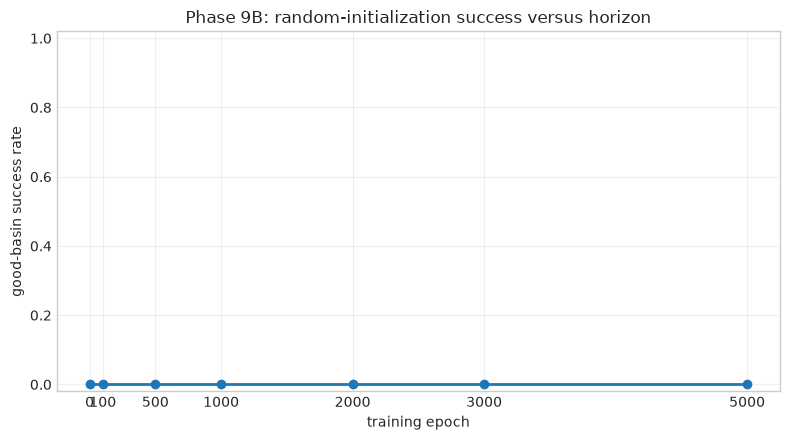

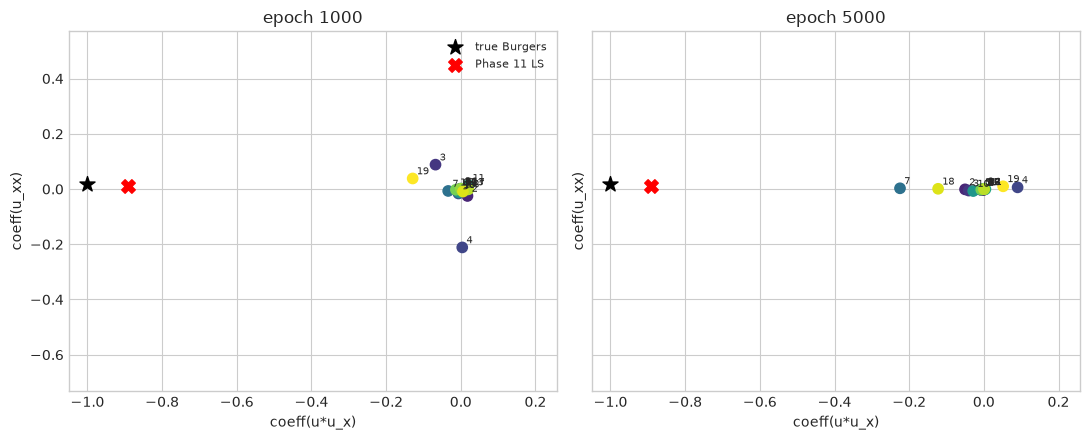

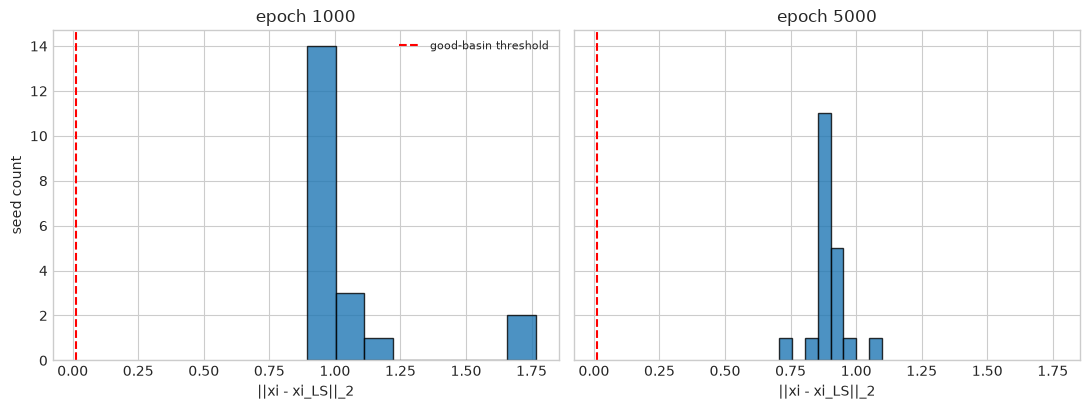

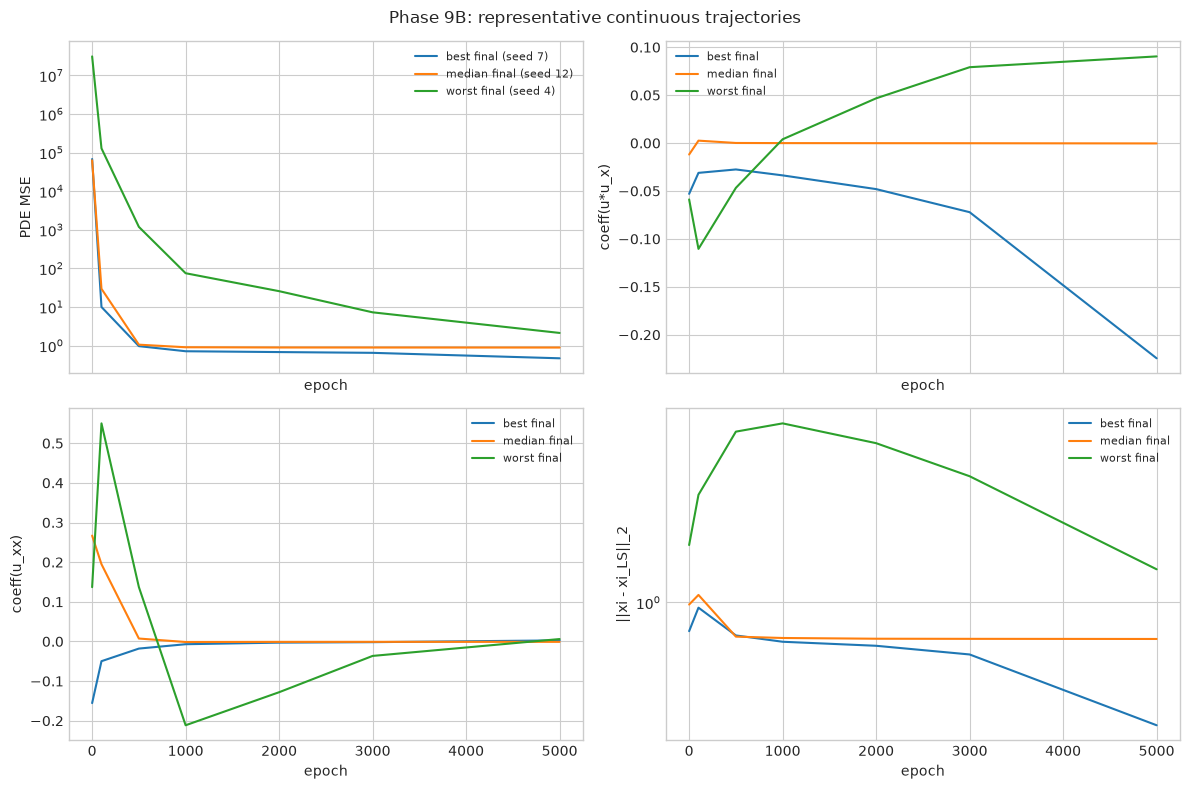

In [1]:
# Primary success-rate plot.
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(phase9b_aggregate_df["epoch"], phase9b_aggregate_df["success_rate"], "-o", linewidth=2)
ax.set(xlabel="training epoch", ylabel="good-basin success rate", title="Phase 9B: random-initialization success versus horizon", ylim=(-0.02, 1.02))
ax.set_xticks(phase9b_checkpoints)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(phase9b_output_dir / "success_rate_vs_epoch.png", dpi=160, bbox_inches="tight")
plt.show()

# Coefficient-space snapshots with identical limits.
phase9b_scatter = phase9b_checkpoint_df[phase9b_checkpoint_df["epoch"].isin([1000, 5000])]
phase9b_x = phase9b_checkpoint_df["xi_u*u_x"].to_numpy()
phase9b_y = phase9b_checkpoint_df["xi_u_xx"].to_numpy()
phase9b_xlim = (min(-1.05, phase9b_x.min() - 0.05), max(0.1, phase9b_x.max() + 0.05))
phase9b_ylim = (min(-0.05, phase9b_y.min() - 0.01), max(0.06, phase9b_y.max() + 0.01))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for phase9b_ax, phase9b_epoch in zip(axes, [1000, 5000]):
    phase9b_snap = phase9b_scatter[phase9b_scatter["epoch"] == phase9b_epoch]
    phase9b_ax.scatter(phase9b_snap["xi_u*u_x"], phase9b_snap["xi_u_xx"], c=phase9b_snap["seed"], cmap="viridis", s=55)
    for _, phase9b_row in phase9b_snap.iterrows(): phase9b_ax.annotate(str(int(phase9b_row["seed"])), (phase9b_row["xi_u*u_x"], phase9b_row["xi_u_xx"]), fontsize=7, xytext=(3,3), textcoords="offset points")
    phase9b_ax.scatter([-1.0], [0.02], color="black", marker="*", s=130, label="true Burgers")
    phase9b_ax.scatter([-0.892455], [0.009980], color="red", marker="X", s=95, label="Phase 11 LS")
    phase9b_ax.set(xlabel="coeff(u*u_x)", ylabel="coeff(u_xx)", title=f"epoch {phase9b_epoch}", xlim=phase9b_xlim, ylim=phase9b_ylim)
axes[0].legend(loc="best", fontsize=8)
plt.tight_layout()
fig.savefig(phase9b_output_dir / "coefficient_scatter_1000_5000.png", dpi=160, bbox_inches="tight")
plt.show()

# LS-distance distributions.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True, sharey=True)
for phase9b_ax, phase9b_epoch in zip(axes, [1000, 5000]):
    phase9b_values = phase9b_scatter.loc[phase9b_scatter["epoch"] == phase9b_epoch, "xi_dist_to_ls"]
    phase9b_ax.hist(phase9b_values, bins=8, alpha=0.8, edgecolor="black")
    phase9b_ax.axvline(phase9b_good_xi_threshold, color="red", linestyle="--", label="good-basin threshold")
    phase9b_ax.set(xlabel="||xi - xi_LS||_2", title=f"epoch {phase9b_epoch}")
axes[0].set_ylabel("seed count")
axes[0].legend(fontsize=8)
plt.tight_layout()
fig.savefig(phase9b_output_dir / "xi_distance_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

# Automatically selected best, median, and worst final seeds.
phase9b_ordered = phase9b_summary_df.sort_values("final_xi_dist_to_LS").reset_index(drop=True)
phase9b_representative = {
    "best final": int(phase9b_ordered.iloc[0]["seed"]),
    "median final": int(phase9b_ordered.iloc[len(phase9b_ordered) // 2]["seed"]),
    "worst final": int(phase9b_ordered.iloc[-1]["seed"]),
}
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for phase9b_label, phase9b_seed in phase9b_representative.items():
    phase9b_history = phase9b_histories[phase9b_seed]
    axes[0, 0].plot(phase9b_history["epoch"], phase9b_history["pde_mse"], label=f"{phase9b_label} (seed {phase9b_seed})")
    axes[0, 1].plot(phase9b_history["epoch"], phase9b_history["xi_u*u_x"], label=phase9b_label)
    axes[1, 0].plot(phase9b_history["epoch"], phase9b_history["xi_u_xx"], label=phase9b_label)
    axes[1, 1].plot(phase9b_history["epoch"], phase9b_history["xi_dist_to_ls"], label=phase9b_label)
axes[0, 0].set_yscale("log")
axes[1, 1].set_yscale("log")
axes[0, 0].set_ylabel("PDE MSE"); axes[0, 1].set_ylabel("coeff(u*u_x)")
axes[1, 0].set_ylabel("coeff(u_xx)"); axes[1, 1].set_ylabel("||xi - xi_LS||_2")
for phase9b_ax in axes.flat: phase9b_ax.set_xlabel("epoch"); phase9b_ax.legend(fontsize=8)
fig.suptitle("Phase 9B: representative continuous trajectories")
plt.tight_layout()
fig.savefig(phase9b_output_dir / "representative_trajectories.png", dpi=160, bbox_inches="tight")
plt.show()

phase9b_first_passage = phase9b_summary_df[phase9b_summary_df["ever_reached_good_basin"]][["seed", "first_good_epoch"]]
display(phase9b_first_passage.sort_values("first_good_epoch"))


In [1]:
phase9b_success_1000 = float(phase9b_aggregate_df.loc[phase9b_aggregate_df["epoch"] == 1000, "success_rate"].iloc[0])
phase9b_success_2000 = float(phase9b_aggregate_df.loc[phase9b_aggregate_df["epoch"] == 2000, "success_rate"].iloc[0])
phase9b_success_5000 = float(phase9b_aggregate_df.loc[phase9b_aggregate_df["epoch"] == 5000, "success_rate"].iloc[0])
phase9b_successful = phase9b_summary_df[phase9b_summary_df["ever_reached_good_basin"]]
phase9b_best_seed = int(phase9b_summary_df.loc[phase9b_summary_df["final_xi_dist_to_LS"].idxmin(), "seed"])
phase9b_worst_seed = int(phase9b_summary_df.loc[phase9b_summary_df["final_xi_dist_to_LS"].idxmax(), "seed"])
phase9b_median_first = float(phase9b_successful["first_good_epoch"].median()) if len(phase9b_successful) else None
print("Phase 9B interpretation:")
if phase9b_success_5000 < 0.1:
    print("Failure from ordinary random initialization is robust across seeds and persists under a substantially longer optimization horizon.")
elif phase9b_success_5000 < 0.75:
    print("Ordinary random initialization is unreliable and strongly seed-dependent. Some trajectories eventually reach the Burgers-like basin, but many do not, and successful convergence can require substantially longer optimization.")
else:
    print("The earlier Phase 9 failure was primarily a finite-training-horizon effect, rather than evidence that random initialization itself prevents recovery.")
print("Phase 16 showed that additional optimization time can improve some structured initializations; Phase 9B tests whether the same phenomenon rescues ordinary random initialization.")
print("The measured success-rate curve distinguishes convergence speed from convergence reachability; it does not establish that either is the cause of the original failure by itself.")
print()
print("Machine-readable diagnostic:")
print(f"number_of_seeds={len(phase9b_seeds)}")
print(f"success_rate_at_1000={phase9b_success_1000:.6f}")
print(f"success_rate_at_2000={phase9b_success_2000:.6f}")
print(f"success_rate_at_5000={phase9b_success_5000:.6f}")
print(f"median_xi_distance_at_1000={float(phase9b_aggregate_df.loc[phase9b_aggregate_df['epoch']==1000, 'median_xi_dist_to_LS'].iloc[0]):.9e}")
print(f"median_xi_distance_at_5000={float(phase9b_aggregate_df.loc[phase9b_aggregate_df['epoch']==5000, 'median_xi_dist_to_LS'].iloc[0]):.9e}")
print(f"best_seed={phase9b_best_seed}")
print(f"worst_seed={phase9b_worst_seed}")
print(f"median_first_good_epoch={phase9b_median_first if phase9b_median_first is not None else 'None'}")


Phase 9B interpretation:
Failure from ordinary random initialization is robust across seeds and persists under a substantially longer optimization horizon.
Phase 16 showed that additional optimization time can improve some structured initializations; Phase 9B tests whether the same phenomenon rescues ordinary random initialization.
The measured success-rate curve distinguishes convergence speed from convergence reachability; it does not establish that either is the cause of the original failure by itself.

Machine-readable diagnostic:
number_of_seeds=20
success_rate_at_1000=0.000000
success_rate_at_2000=0.000000
success_rate_at_5000=0.000000
median_xi_distance_at_1000=9.194588920e-01
median_xi_distance_at_5000=9.016126525e-01
best_seed=7
worst_seed=4
median_first_good_epoch=None


## 10. Randomly Initialized SymNet + Joint SIREN/SymNet Training

Question answered here: once both the surrogate and the minimal SymNet start from ordinary initialization and are allowed to adapt together, does low data loss plus low internal PDE loss also correspond to correct derivatives and the Burgers equation?

In [19]:
torch.manual_seed(SEED)
lam_data = 1.0
lam_pde = 0.5
random_joint_epochs = 1000
random_joint_batch_size = 4096
random_joint_lr = 5e-4
random_joint_checkpoints = sorted({0, 100, 500, 1000, random_joint_epochs})
random_joint_loss_fn = nn.MSELoss()

random_joint_siren = SirenMLP(
    hidden_size=64,
    hidden_layers=3,
    first_omega_0=20.0,
    hidden_omega_0=1.0,
).to(device)
random_joint_symnet = MinimalSymNet().to(device)

with torch.no_grad():
    initial_random_joint_data_mse = float(random_joint_loss_fn(random_joint_siren(t_train, x_train), u_train).item())

t_init = t_train[:random_joint_batch_size].clone().detach().requires_grad_(True)
x_init = x_train[:random_joint_batch_size].clone().detach().requires_grad_(True)
u_init = random_joint_siren(t_init, x_init)
ut_init = torch.autograd.grad(u_init, t_init, grad_outputs=torch.ones_like(u_init), create_graph=False, retain_graph=True)[0]
ux_init = torch.autograd.grad(u_init, x_init, grad_outputs=torch.ones_like(u_init), create_graph=True, retain_graph=True)[0]
uxx_init = torch.autograd.grad(ux_init, x_init, grad_outputs=torch.ones_like(ux_init), create_graph=False, retain_graph=False)[0]
initial_random_joint_pde_mse = float(
    random_joint_loss_fn(ut_init, random_joint_symnet(torch.cat([u_init.detach(), ux_init.detach(), uxx_init.detach()], dim=1))).item()
)
initial_random_joint_coeffs = product_term_dict(random_joint_symnet)

print(f"initial data MSE = {initial_random_joint_data_mse:.6e}")
print(f"initial raw PDE MSE = {initial_random_joint_pde_mse:.6e}")
print("initial SymNet effective equation:")
print(pretty_equation(initial_random_joint_coeffs))
display(pd.DataFrame([initial_random_joint_coeffs]).T.rename(columns={0: "initial_coefficient"}))

random_joint_optimizer = torch.optim.Adam(
    list(random_joint_siren.parameters()) + list(random_joint_symnet.parameters()),
    lr=random_joint_lr,
)

random_joint_loss_history = []
random_joint_coeff_history = []

for epoch in range(random_joint_epochs + 1):
    idx = torch.randint(0, len(t_train), (random_joint_batch_size,), device=device)
    t_batch = t_train[idx].clone().detach().requires_grad_(True)
    x_batch = x_train[idx].clone().detach().requires_grad_(True)
    u_batch_true = u_train[idx]

    u_batch_pred = random_joint_siren(t_batch, x_batch)
    ut_batch = torch.autograd.grad(u_batch_pred, t_batch, grad_outputs=torch.ones_like(u_batch_pred), create_graph=True, retain_graph=True)[0]
    ux_batch = torch.autograd.grad(u_batch_pred, x_batch, grad_outputs=torch.ones_like(u_batch_pred), create_graph=True, retain_graph=True)[0]
    uxx_batch = torch.autograd.grad(ux_batch, x_batch, grad_outputs=torch.ones_like(ux_batch), create_graph=True, retain_graph=True)[0]
    rhs_batch = random_joint_symnet(torch.cat([u_batch_pred, ux_batch, uxx_batch], dim=1))

    data_loss = random_joint_loss_fn(u_batch_pred, u_batch_true)
    pde_loss = random_joint_loss_fn(ut_batch, rhs_batch)
    total_loss = lam_data * data_loss + lam_pde * pde_loss

    random_joint_loss_history.append({
        "epoch": epoch,
        "data_loss": float(data_loss.item()),
        "pde_loss": float(pde_loss.item()),
        "total_loss": float(total_loss.item()),
    })

    if epoch in random_joint_checkpoints:
        coeffs = product_term_dict(random_joint_symnet)
        coeff_row = {
            "epoch": epoch,
            "data_loss": float(data_loss.item()),
            "pde_loss": float(pde_loss.item()),
            "total_loss": float(total_loss.item()),
        }
        coeff_row.update(coeffs)
        random_joint_coeff_history.append(coeff_row)
        print(
            f"epoch {epoch:4d} | data MSE = {float(data_loss.item()):.6e} | "
            f"raw PDE MSE = {float(pde_loss.item()):.6e} | total loss = {float(total_loss.item()):.6e}"
        )
        print(pretty_equation(coeffs))

    if epoch == random_joint_epochs:
        break

    random_joint_optimizer.zero_grad()
    total_loss.backward()
    random_joint_optimizer.step()

random_joint_loss_df = pd.DataFrame(random_joint_loss_history)
random_joint_coeff_df = pd.DataFrame(random_joint_coeff_history)
random_joint_fields = evaluate_model_and_derivatives_in_chunks(
    random_joint_siren,
    t_flat=t_flat,
    x_flat=x_flat,
    grid_shape=u_grid.shape,
    chunk_size=4096,
    device=device,
)
random_joint_solution_metrics = pd.DataFrame([
    as_metric_row("u", random_joint_fields["u"], u_grid),
]).set_index("quantity")
random_joint_derivative_metrics = pd.DataFrame([
    as_metric_row("u_t", random_joint_fields["u_t"], reference["u_t"]["physical"]),
    as_metric_row("u_x", random_joint_fields["u_x"], reference["u_x"]["physical"]),
    as_metric_row("u_xx", random_joint_fields["u_xx"], reference["u_xx"]["physical"]),
]).set_index("quantity")
final_random_joint_coeffs = product_term_dict(random_joint_symnet)
random_joint_summary = {
    "optimizer": "Adam",
    "learning_rate": random_joint_lr,
    "epochs": random_joint_epochs,
    "initial_data_mse": initial_random_joint_data_mse,
    "final_data_mse": float(random_joint_loss_df.iloc[-1]["data_loss"]),
    "initial_pde_mse": initial_random_joint_pde_mse,
    "final_pde_mse": float(random_joint_loss_df.iloc[-1]["pde_loss"]),
    "initial_equation": pretty_equation(initial_random_joint_coeffs),
    "final_equation": pretty_equation(final_random_joint_coeffs),
    "final_uux_coeff": float(final_random_joint_coeffs["u*u_x"]),
    "final_uxx_coeff": float(final_random_joint_coeffs["u_xx"]),
}

display(random_joint_solution_metrics)
display(random_joint_derivative_metrics)
display(random_joint_coeff_df)
print("initial equation:")
print(random_joint_summary["initial_equation"])
print("final equation:")
print(random_joint_summary["final_equation"])
print(f"recovered coeff(u*u_x) = {random_joint_summary['final_uux_coeff']:+.6f} (truth -1.000000)")
print(f"recovered coeff(u_xx)  = {random_joint_summary['final_uxx_coeff']:+.6f} (truth +0.020000)")


initial data MSE = 1.576198e+00
initial raw PDE MSE = 5.039675e+02
initial SymNet effective equation:
u_t_hat = (+0.125140)*u + (+0.389047)*u_x + (+0.295680)*u_xx + (+0.018618)*u^2 + (-0.127232)*u*u_x + (+0.001522)*u*u_xx + (-0.169741)*u_x^2 + (+0.020785)*u_x*u_xx + (-0.000405)*u_xx^2
epoch    0 | data MSE = 1.545579e+00 | raw PDE MSE = 7.817963e+02 | total loss = 3.924438e+02
u_t_hat = (+0.125140)*u + (+0.389047)*u_x + (+0.295680)*u_xx + (+0.018618)*u^2 + (-0.127232)*u*u_x + (+0.001522)*u*u_xx + (-0.169741)*u_x^2 + (+0.020785)*u_x*u_xx + (-0.000405)*u_xx^2
epoch  100 | data MSE = 8.303983e-01 | raw PDE MSE = 1.410925e+01 | total loss = 7.885023e+00
u_t_hat = (+0.150256)*u + (+0.372236)*u_x + (+0.276068)*u_xx + (+0.011342)*u^2 + (-0.126442)*u*u_x + (-0.000786)*u*u_xx + (-0.160852)*u_x^2 + (+0.014565)*u_x*u_xx + (-0.000037)*u_xx^2
epoch  500 | data MSE = 6.086199e-01 | raw PDE MSE = 1.190176e+00 | total loss = 1.203708e+00
u_t_hat = (+0.167894)*u + (+0.373548)*u_x + (+0.267987)*u_xx + (

          initial_coefficient
u                    0.125140
u_x                  0.389047
u_xx                 0.295680
u^2                  0.018618
u*u_x               -0.127232
u*u_xx               0.001522
u_x^2               -0.169741
u_x*u_xx             0.020785
u_xx^2              -0.000405

               mse   rel_l2      rmse   max_abs
quantity                                       
u         0.454098  0.78672  0.673868  1.289135

                  mse    rel_l2       rmse     max_abs
quantity                                              
u_t          1.231943  1.137749   1.109929    6.666527
u_x          5.179158  0.973172   2.275776   28.807596
u_xx      2581.011465  1.001009  50.803656  757.577672

   epoch  data_loss    pde_loss  total_loss         u       u_x      u_xx       u^2     u*u_x    u*u_xx     u_x^2  u_x*u_xx    u_xx^2
0      0   1.545579  781.796326  392.443756  0.125140  0.389047  0.295680  0.018618 -0.127232  0.001522 -0.169741  0.020785 -0.000405
1    100   0.830398   14.109249    7.885023  0.150256  0.372236  0.276068  0.011342 -0.126442 -0.000786 -0.160852  0.014565 -0.000037
2    500   0.608620    1.190176    1.203708  0.167894  0.373548  0.267987  0.009464 -0.130099 -0.000368 -0.161040  0.014939 -0.000060
3   1000   0.450415    0.365075    0.632953  0.173554  0.373709  0.264648  0.009119 -0.130912 -0.000314 -0.161011  0.014971 -0.000061

   epoch  data_loss    pde_loss  total_loss         u       u_x      u_xx       u^2     u*u_x    u*u_xx     u_x^2  u_x*u_xx    u_xx^2
0      0   1.545579  781.796326  392.443756  0.125140  0.389047  0.295680  0.018618 -0.127232  0.001522 -0.169741  0.020785 -0.000405
1    100   0.830398   14.109249    7.885023  0.150256  0.372236  0.276068  0.011342 -0.126442 -0.000786 -0.160852  0.014565 -0.000037
2    500   0.608620    1.190176    1.203708  0.167894  0.373548  0.267987  0.009464 -0.130099 -0.000368 -0.161040  0.014939 -0.000060
3   1000   0.450415    0.365075    0.632953  0.173554  0.373709  0.264648  0.009119 -0.130912 -0.000314 -0.161011  0.014971 -0.000061

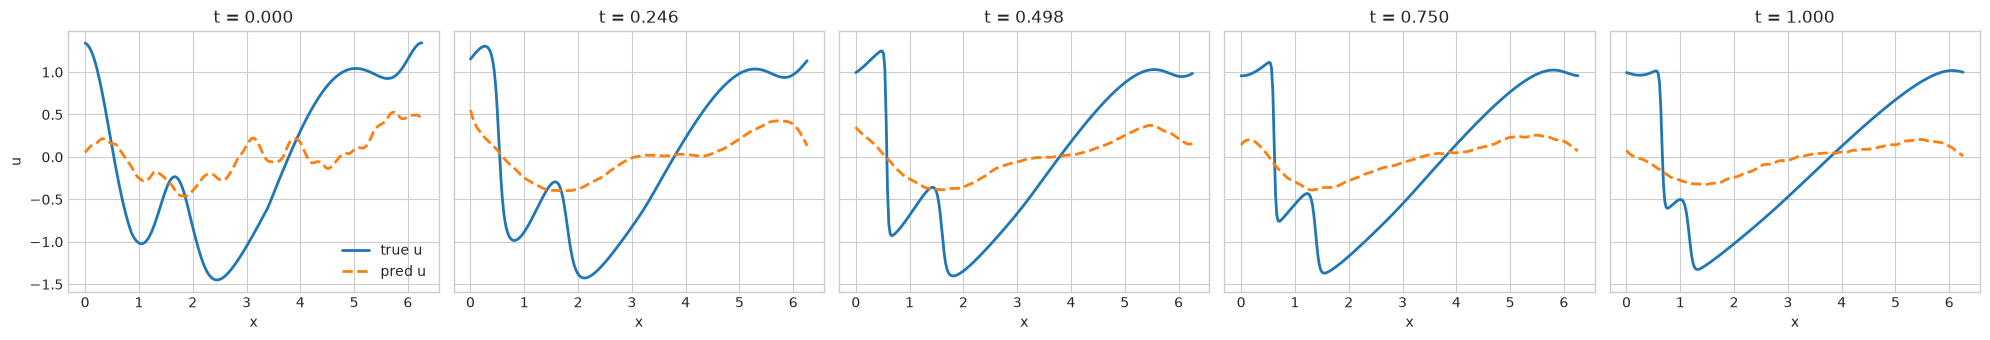

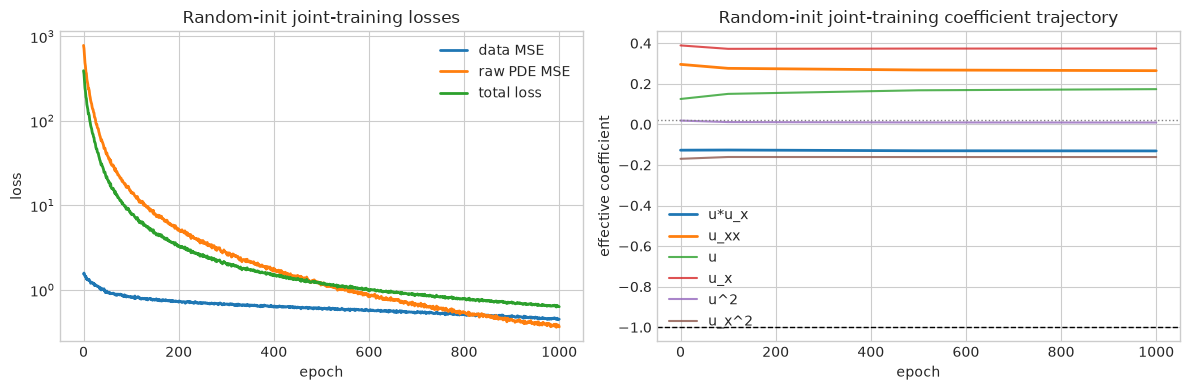

In [20]:
plot_time_slices(
    x_grid,
    u_grid,
    pred_grid=random_joint_fields["u"],
    time_values=t_grid,
    title_prefix="u",
    slice_indices=slice_indices,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(random_joint_loss_df["epoch"], random_joint_loss_df["data_loss"], label="data MSE", linewidth=2)
axes[0].plot(random_joint_loss_df["epoch"], random_joint_loss_df["pde_loss"], label="raw PDE MSE", linewidth=2)
axes[0].plot(random_joint_loss_df["epoch"], random_joint_loss_df["total_loss"], label="total loss", linewidth=2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Random-init joint-training losses")
axes[0].legend(loc="best")

axes[1].plot(random_joint_coeff_df["epoch"], random_joint_coeff_df["u*u_x"], label="u*u_x", linewidth=2)
axes[1].plot(random_joint_coeff_df["epoch"], random_joint_coeff_df["u_xx"], label="u_xx", linewidth=2)
axes[1].plot(random_joint_coeff_df["epoch"], random_joint_coeff_df["u"], label="u", alpha=0.8)
axes[1].plot(random_joint_coeff_df["epoch"], random_joint_coeff_df["u_x"], label="u_x", alpha=0.8)
axes[1].plot(random_joint_coeff_df["epoch"], random_joint_coeff_df["u^2"], label="u^2", alpha=0.8)
axes[1].plot(random_joint_coeff_df["epoch"], random_joint_coeff_df["u_x^2"], label="u_x^2", alpha=0.8)
axes[1].axhline(-1.0, color="black", linestyle="--", linewidth=1)
axes[1].axhline(0.02, color="gray", linestyle=":", linewidth=1)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("effective coefficient")
axes[1].set_title("Random-init joint-training coefficient trajectory")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

display(random_joint_coeff_df[["epoch", "data_loss", "pde_loss", "total_loss", "u", "u_x", "u_xx", "u^2", "u*u_x", "u*u_xx", "u_x^2", "u_x*u_xx", "u_xx^2"]])


### Section 10 Interpretation

- Compare Section 10 against Section 8: Section 8 showed that the architecture can represent Burgers and that the Burgers basin is stable when initialized there, ending near `coeff(u*u_x) = -0.881262`, `coeff(u_xx) = +0.010047`, and PDE MSE about `8.996e-02`. Section 10 did not return to that basin from random initialization.
- Compare Section 10 against Section 9: Section 10 achieved lower internal PDE loss than the frozen-surrogate random-init run (`3.651e-01` versus `9.651e-01`), but it still converged to the wrong support and wrong coefficients, with `u*u_x` stuck near `-0.130912` and `u_xx` near `+0.264648`.
- Did low internal PDE loss coincide with good derivatives and Burgers recovery? No. Even with data MSE reduced to about `4.50e-01` and PDE MSE reduced to about `3.65e-01`, the final derivative errors remained poor: relative L2 was about `1.14` for `u_t`, `0.97` for `u_x`, and `1.00` for `u_xx`, and the discovered equation was still far from Burgers.
- Is there evidence of SIREN/SymNet co-adaptation? Yes. Compared with Section 9, allowing the surrogate to move reduced the internal PDE loss further without recovering the correct PDE or correct derivatives, which is consistent with co-adaptation toward an internally easier but physically wrong explanation.
- Overall diagnosis: Section 10 is best interpreted as case B. The end-to-end system finds a lower-loss internal agreement than the frozen-surrogate random-init run, but that lower loss does not correspond to correct Burgers recovery.

## 11. Direct Coefficient-Space Control

The previous experiments show that the minimal SymNet can represent the Burgers equation, but random initialization does not recover it even with the surrogate frozen. This leaves two possibilities: the difficulty may lie in optimizing SymNet's internal parameters into the correct PDE coefficients, or the frozen surrogate derivatives may themselves favor a non-Burgers equation.

To separate these effects, bypass the SymNet parameterization and fit the same candidate PDE terms directly by least squares,

`u_t ≈ Theta xi`.

Here least squares searches directly over `xi`, whereas SymNet + Adam searches over internal weights `theta` that indirectly generate `xi(theta)`. The final prediction is still `u_t_hat = Theta xi`, but this control removes the nonlinear `theta -> xi` map.

In [21]:
ls_feature_names = ["u", "u_x", "u_xx", "u^2", "u*u_x", "u*u_xx", "u_x^2", "u_x*u_xx", "u_xx^2"]
ls_feature_arrays = {
    "u": surrogate_fields["u"].reshape(-1),
    "u_x": surrogate_fields["u_x"].reshape(-1),
    "u_xx": surrogate_fields["u_xx"].reshape(-1),
}
ls_feature_arrays["u^2"] = ls_feature_arrays["u"] ** 2
ls_feature_arrays["u*u_x"] = ls_feature_arrays["u"] * ls_feature_arrays["u_x"]
ls_feature_arrays["u*u_xx"] = ls_feature_arrays["u"] * ls_feature_arrays["u_xx"]
ls_feature_arrays["u_x^2"] = ls_feature_arrays["u_x"] ** 2
ls_feature_arrays["u_x*u_xx"] = ls_feature_arrays["u_x"] * ls_feature_arrays["u_xx"]
ls_feature_arrays["u_xx^2"] = ls_feature_arrays["u_xx"] ** 2

theta_direct = np.column_stack([ls_feature_arrays[name] for name in ls_feature_names])
y_direct = surrogate_fields["u_t"].reshape(-1)
direct_coeffs, direct_residuals, direct_rank, direct_singular_vals = np.linalg.lstsq(theta_direct, y_direct, rcond=None)
direct_coeff_dict = {name: float(value) for name, value in zip(ls_feature_names, direct_coeffs)}
direct_ut_hat = theta_direct @ direct_coeffs
direct_pde_mse = float(np.mean((y_direct - direct_ut_hat) ** 2))

def pretty_linear_equation(coeff_dict, ordered_names):
    terms = [f"({coeff_dict[name]:+.6f})*{name}" for name in ordered_names]
    return "u_t_hat = " + " + ".join(terms)

direct_ls_summary = {
    "method": "direct least squares",
    "pde_mse": direct_pde_mse,
    "u*u_x": direct_coeff_dict["u*u_x"],
    "u_xx": direct_coeff_dict["u_xx"],
    "equation": pretty_linear_equation(direct_coeff_dict, ls_feature_names),
}

print("phase-9 frozen surrogate reused: yes")
print("candidate library reused: full 9-term degree-2 expansion of MinimalSymNet")
print(f"rank(Theta) = {direct_rank}")
print(f"singular values = {direct_singular_vals}")
print()
print("Direct least-squares recovered PDE:")
print(direct_ls_summary["equation"])
print()
print("All nine coefficients:")
display(pd.DataFrame([direct_coeff_dict]).T.rename(columns={0: "coefficient"}))
print(f"coeff(u*u_x) vs true -1.000000: {direct_ls_summary['u*u_x']:+.6f} | error = {direct_ls_summary['u*u_x'] + 1.0:+.6e}")
print(f"coeff(u_xx)  vs true +0.020000: {direct_ls_summary['u_xx']:+.6f} | error = {direct_ls_summary['u_xx'] - 0.02:+.6e}")
print(f"PDE MSE on the frozen-surrogate comparison points = {direct_ls_summary['pde_mse']:.6e}")

phase11_comparison_df = pd.DataFrame([
    {
        "experiment": "hand-initialized frozen SymNet",
        "PDE MSE": float(symnet_history_df.iloc[-1]["pde_loss"]),
        "coeff(u*u_x)": float(symnet_history_df.iloc[-1]["u*u_x"]),
        "coeff(u_xx)": float(symnet_history_df.iloc[-1]["u_xx"]),
    },
    {
        "experiment": "random-initialized frozen SymNet",
        "PDE MSE": float(random_frozen_summary["final_pde_mse"]),
        "coeff(u*u_x)": float(random_frozen_summary["final_uux_coeff"]),
        "coeff(u_xx)": float(random_frozen_summary["final_uxx_coeff"]),
    },
    {
        "experiment": "direct least squares",
        "PDE MSE": direct_ls_summary["pde_mse"],
        "coeff(u*u_x)": direct_ls_summary["u*u_x"],
        "coeff(u_xx)": direct_ls_summary["u_xx"],
    },
])
display(phase11_comparison_df)


phase-9 frozen surrogate reused: yes
candidate library reused: full 9-term degree-2 expansion of MinimalSymNet
rank(Theta) = 9
singular values = [5.9335560e+06 1.8776408e+05 1.0214019e+04 6.3995151e+03 4.6394316e+03
 3.2321191e+02 2.3124373e+02 2.1920988e+02 1.8382745e+02]

Direct least-squares recovered PDE:
u_t_hat = (-0.026607)*u + (+0.031648)*u_x + (+0.009980)*u_xx + (-0.004855)*u^2 + (-0.892455)*u*u_x + (-0.002124)*u*u_xx + (+0.000004)*u_x^2 + (-0.000616)*u_x*u_xx + (+0.000001)*u_xx^2

All nine coefficients:
coeff(u*u_x) vs true -1.000000: -0.892455 | error = +1.075449e-01
coeff(u_xx)  vs true +0.020000: +0.009980 | error = -1.002040e-02
PDE MSE on the frozen-surrogate comparison points = 8.851884e-02


          coefficient
u           -0.026607
u_x          0.031648
u_xx         0.009980
u^2         -0.004855
u*u_x       -0.892455
u*u_xx      -0.002124
u_x^2        0.000004
u_x*u_xx    -0.000616
u_xx^2       0.000001

                         experiment   PDE MSE  coeff(u*u_x)  coeff(u_xx)
0    hand-initialized frozen SymNet  0.089954     -0.881262     0.010047
1  random-initialized frozen SymNet  0.965114     -0.005406    -0.001735
2              direct least squares  0.088519     -0.892455     0.009980

### Section 11 Interpretation

- On September 3, 2026, direct least squares on the exact frozen Phase 9 derivative field recovered a coefficient vector very close to the hand-initialized frozen-SymNet basin: `coeff(u*u_x) = -0.892455`, `coeff(u_xx) = +0.009980`, and PDE MSE `8.851884e-02`.
- That is far closer to Burgers than the random-initialized frozen-SymNet run, which ended at `coeff(u*u_x) = -0.005406`, `coeff(u_xx) = -0.001735`, and PDE MSE `9.651142e-01`.
- The evidence therefore points primarily to the `theta -> xi` side of the pipeline: the frozen surrogate derivatives contain enough information to recover a much more Burgers-like coefficient vector directly in `xi`, while Adam from random SymNet initialization fails to reach that basin through the nonlinear parameterization.
- This is still not exact Burgers recovery, so the frozen derivative field is imperfect; but the dominant gap exposed by this control is not direct coefficient identifiability.

## 12. Deterministic Parameter-Space Geometry

Phase 11 showed that direct least squares in coefficient space and the hand-initialized frozen SymNet both reach essentially the same Burgers-like basin, while random frozen-SymNet optimization does not. The next question is whether the nonlinear map from SymNet parameters `theta` to expanded PDE coefficients `xi(theta)` makes an otherwise simple coefficient-space problem locally awkward in parameter space.

With the surrogate frozen, the coefficient-space loss is `L(xi) = ||Theta xi - u_t||^2`, but the SymNet actually optimizes `L(theta) = ||Theta xi(theta) - u_t||^2`. We therefore examine only deterministic slices and local geometry of this frozen loss, without any additional training.

One structural caution matters here: for a product path `(a^T z)(b^T z)`, the rescaling `a -> c a` and `b -> b / c` can leave the represented product unchanged. That redundancy can create flat or poorly conditioned directions in parameter space even when the induced PDE coefficients change in a much simpler way.

reference frozen PDE MSE at theta_ref = 8.995417e-02


                    direction  alpha_span  reference_pde_mse  min_alpha  min_pde_mse  coeff(u*u_x) at min  coeff(u_xx) at min  max |alpha| with PDE MSE <= 2x ref
0               left[u] basis        1.25           0.089954        0.0     0.089954            -0.881262            0.010047                             0.25000
1            right[u_x] basis        1.25           0.089954        0.0     0.089954            -0.881262            0.010047                             0.25000
2       product readout basis        1.25           0.089954        0.0     0.089954            -0.881262            0.010047                             0.21875
3          linear[u_xx] basis        0.05           0.089954        0.0     0.089954            -0.881262            0.010047                             0.00500
4  product rescaling symmetry        1.00           0.089954        0.0     0.089954            -0.881262            0.010047                             0.80000

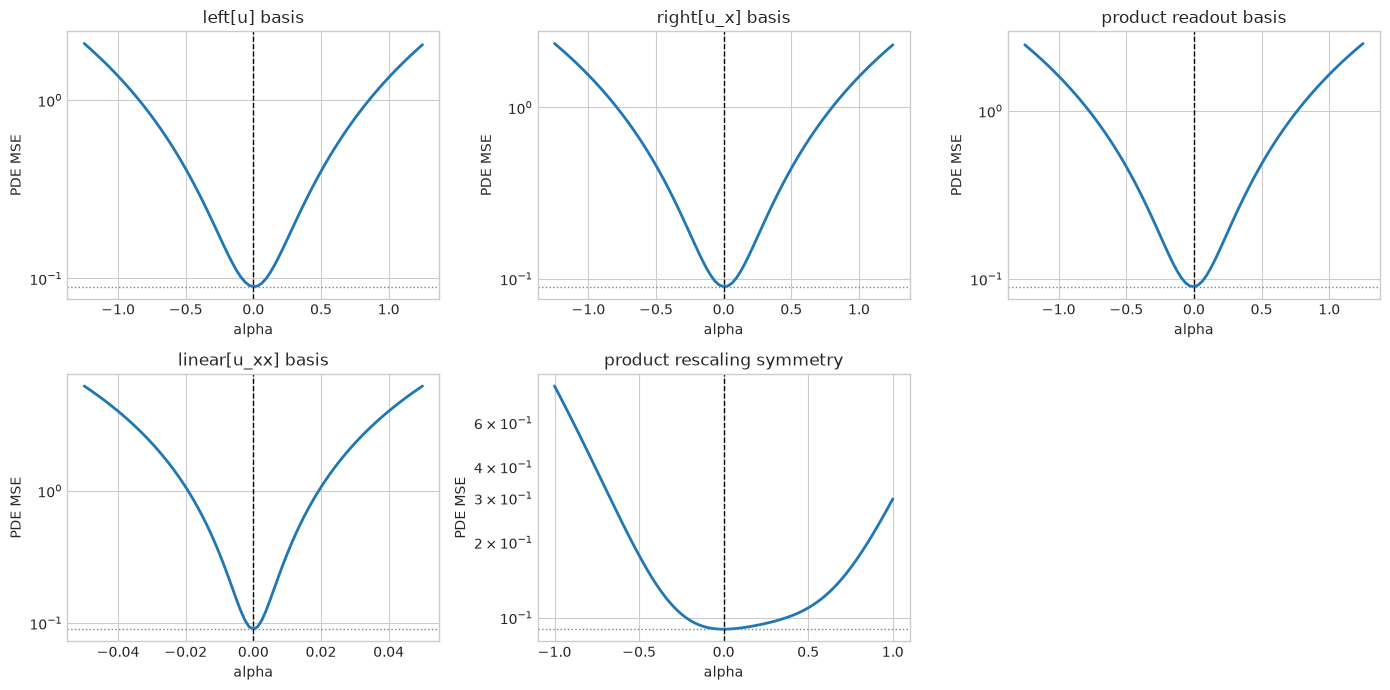

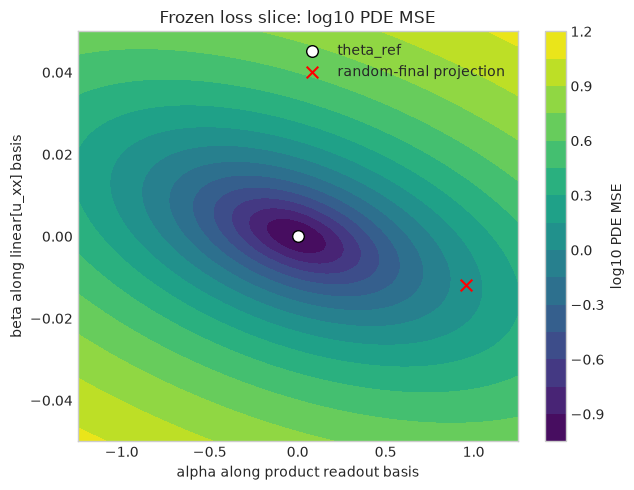

In [22]:
theta_param_names = [
    "left[u]",
    "left[u_x]",
    "left[u_xx]",
    "right[u]",
    "right[u_x]",
    "right[u_xx]",
    "linear[u]",
    "linear[u_x]",
    "linear[u_xx]",
    "product_readout",
]
phase12_coeff_names = ["u", "u_x", "u_xx", "u^2", "u*u_x", "u*u_xx", "u_x^2", "u_x*u_xx", "u_xx^2"]

u_col = frozen_feature_tensor[:, 0].detach().cpu().to(torch.float64)
ux_col = frozen_feature_tensor[:, 1].detach().cpu().to(torch.float64)
uxx_col = frozen_feature_tensor[:, 2].detach().cpu().to(torch.float64)
phase12_theta_matrix = torch.stack([
    u_col,
    ux_col,
    uxx_col,
    u_col ** 2,
    u_col * ux_col,
    u_col * uxx_col,
    ux_col ** 2,
    ux_col * uxx_col,
    uxx_col ** 2,
], dim=1)
phase12_ut_target = frozen_ut_target.detach().cpu().to(torch.float64).reshape(-1)

def flatten_symnet_params(model):
    return torch.tensor([
        *model.left.weight.detach().cpu().reshape(-1).tolist(),
        *model.right.weight.detach().cpu().reshape(-1).tolist(),
        *model.linear.weight.detach().cpu().reshape(-1).tolist(),
        float(model.product_readout.weight.detach().cpu().reshape(-1)[0]),
    ], dtype=torch.float64)

def coeff_vector_from_theta(theta_flat):
    left = theta_flat[0:3]
    right = theta_flat[3:6]
    linear = theta_flat[6:9]
    alpha = theta_flat[9]
    return torch.stack([
        linear[0],
        linear[1],
        linear[2],
        alpha * left[0] * right[0],
        alpha * (left[0] * right[1] + left[1] * right[0]),
        alpha * (left[0] * right[2] + left[2] * right[0]),
        alpha * left[1] * right[1],
        alpha * (left[1] * right[2] + left[2] * right[1]),
        alpha * left[2] * right[2],
    ])

def frozen_pde_mse_from_theta(theta_flat):
    coeff_vec = coeff_vector_from_theta(theta_flat)
    pred = phase12_theta_matrix @ coeff_vec
    return torch.mean((pred - phase12_ut_target) ** 2)

theta_ref = flatten_symnet_params(symnet_frozen)
theta_bad = flatten_symnet_params(random_frozen_symnet)
ref_loss_value = float(frozen_pde_mse_from_theta(theta_ref).item())

rescale_direction = torch.zeros_like(theta_ref)
rescale_direction[0] = theta_ref[0]
rescale_direction[4] = -theta_ref[4]
if float(torch.linalg.norm(rescale_direction).item()) > 0.0:
    rescale_direction = rescale_direction / torch.linalg.norm(rescale_direction)

direction_specs = [
    {"label": "left[u] basis", "vector": torch.nn.functional.one_hot(torch.tensor(0), num_classes=len(theta_ref)).to(torch.float64), "span": 1.25},
    {"label": "right[u_x] basis", "vector": torch.nn.functional.one_hot(torch.tensor(4), num_classes=len(theta_ref)).to(torch.float64), "span": 1.25},
    {"label": "product readout basis", "vector": torch.nn.functional.one_hot(torch.tensor(9), num_classes=len(theta_ref)).to(torch.float64), "span": 1.25},
    {"label": "linear[u_xx] basis", "vector": torch.nn.functional.one_hot(torch.tensor(8), num_classes=len(theta_ref)).to(torch.float64), "span": 0.05},
    {"label": "product rescaling symmetry", "vector": rescale_direction.clone(), "span": 1.00},
]

slice_alpha_grid = {}
slice_results = {}
slice_summary_rows = []
for spec in direction_specs:
    alphas = np.linspace(-spec["span"], spec["span"], 81)
    rows = []
    for alpha in alphas:
        theta_here = theta_ref + float(alpha) * spec["vector"]
        coeff_here = coeff_vector_from_theta(theta_here)
        loss_here = float(frozen_pde_mse_from_theta(theta_here).item())
        rows.append({
            "alpha": float(alpha),
            "pde_mse": loss_here,
            "coeff(u*u_x)": float(coeff_here[4].item()),
            "coeff(u_xx)": float(coeff_here[2].item()),
        })
    slice_df = pd.DataFrame(rows)
    slice_alpha_grid[spec["label"]] = alphas
    slice_results[spec["label"]] = slice_df

    near_ref = slice_df[slice_df["pde_mse"] <= 2.0 * ref_loss_value]
    min_idx = int(slice_df["pde_mse"].idxmin())
    slice_summary_rows.append({
        "direction": spec["label"],
        "alpha_span": spec["span"],
        "reference_pde_mse": ref_loss_value,
        "min_alpha": float(slice_df.loc[min_idx, "alpha"]),
        "min_pde_mse": float(slice_df.loc[min_idx, "pde_mse"]),
        "coeff(u*u_x) at min": float(slice_df.loc[min_idx, "coeff(u*u_x)"]),
        "coeff(u_xx) at min": float(slice_df.loc[min_idx, "coeff(u_xx)"]),
        "max |alpha| with PDE MSE <= 2x ref": float(np.max(np.abs(near_ref["alpha"].to_numpy()))) if len(near_ref) else 0.0,
    })

phase12_slice_summary_df = pd.DataFrame(slice_summary_rows)
display(phase12_slice_summary_df)
print(f"reference frozen PDE MSE at theta_ref = {ref_loss_value:.6e}")

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.reshape(2, 3)
for ax, spec in zip(axes.flat, direction_specs):
    slice_df = slice_results[spec["label"]]
    ax.plot(slice_df["alpha"], slice_df["pde_mse"], linewidth=2)
    ax.axvline(0.0, color="black", linestyle="--", linewidth=1)
    ax.axhline(ref_loss_value, color="gray", linestyle=":", linewidth=1)
    ax.set_yscale("log")
    ax.set_title(spec["label"])
    ax.set_xlabel("alpha")
    ax.set_ylabel("PDE MSE")
axes[1, 2].axis("off")
plt.tight_layout()
plt.show()

alpha_grid_2d = np.linspace(-1.25, 1.25, 61)
beta_grid_2d = np.linspace(-0.05, 0.05, 61)
v1 = torch.nn.functional.one_hot(torch.tensor(9), num_classes=len(theta_ref)).to(torch.float64)
v2 = torch.nn.functional.one_hot(torch.tensor(8), num_classes=len(theta_ref)).to(torch.float64)
loss_grid_2d = np.zeros((len(beta_grid_2d), len(alpha_grid_2d)), dtype=np.float64)
for j, beta in enumerate(beta_grid_2d):
    for i, alpha in enumerate(alpha_grid_2d):
        theta_here = theta_ref + float(alpha) * v1 + float(beta) * v2
        loss_grid_2d[j, i] = float(frozen_pde_mse_from_theta(theta_here).item())

phase12_2d_slice = {
    "alpha_grid": alpha_grid_2d,
    "beta_grid": beta_grid_2d,
    "loss_grid": loss_grid_2d,
}

bad_projection_alpha = float((theta_bad - theta_ref)[9].item())
bad_projection_beta = float((theta_bad - theta_ref)[8].item())

fig, ax = plt.subplots(figsize=(6.5, 5.0))
heat = ax.contourf(alpha_grid_2d, beta_grid_2d, np.log10(loss_grid_2d), levels=20, cmap="viridis")
ax.scatter([0.0], [0.0], color="white", edgecolor="black", s=70, label="theta_ref")
if alpha_grid_2d.min() <= bad_projection_alpha <= alpha_grid_2d.max() and beta_grid_2d.min() <= bad_projection_beta <= beta_grid_2d.max():
    ax.scatter([bad_projection_alpha], [bad_projection_beta], color="red", marker="x", s=70, label="random-final projection")
ax.set_xlabel("alpha along product readout basis")
ax.set_ylabel("beta along linear[u_xx] basis")
ax.set_title("Frozen loss slice: log10 PDE MSE")
fig.colorbar(heat, ax=ax, label="log10 PDE MSE")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


In [23]:
def jacobian_summary(theta_point, label):
    theta_point = theta_point.clone().detach().requires_grad_(True)
    jac = torch.autograd.functional.jacobian(coeff_vector_from_theta, theta_point)
    jac_np = jac.detach().cpu().numpy()
    singular_vals = np.linalg.svd(jac_np, compute_uv=False)
    tol = singular_vals[0] * 1e-10 if singular_vals[0] > 0 else 0.0
    rank = int(np.sum(singular_vals > tol))
    positive_singular_vals = singular_vals[singular_vals > tol]
    cond = float(positive_singular_vals[0] / positive_singular_vals[-1]) if len(positive_singular_vals) else np.inf
    return {
        "point": label,
        "shape": jac_np.shape,
        "singular_values": singular_vals,
        "rank": rank,
        "condition_number": cond,
        "jacobian": jac_np,
    }

jacobian_ref = jacobian_summary(theta_ref, "Burgers-like frozen SymNet")
jacobian_bad = jacobian_summary(theta_bad, "random-init frozen final SymNet")

for summary in [jacobian_ref, jacobian_bad]:
    print(summary["point"])
    print(f"Jacobian shape = {summary['shape']}")
    print(f"singular values = {summary['singular_values']}")
    print(f"numerical rank = {summary['rank']}")
    print(f"condition number = {summary['condition_number']:.6e}")
    print()

phase12_jacobian_df = pd.DataFrame([
    {
        "point": jacobian_ref["point"],
        "shape": str(jacobian_ref["shape"]),
        "rank": jacobian_ref["rank"],
        "condition_number": jacobian_ref["condition_number"],
    },
    {
        "point": jacobian_bad["point"],
        "shape": str(jacobian_bad["shape"]),
        "rank": jacobian_bad["rank"],
        "condition_number": jacobian_bad["condition_number"],
    },
])
display(phase12_jacobian_df)

def hessian_eigs(theta_point):
    theta_point = theta_point.clone().detach().requires_grad_(True)
    hess = torch.autograd.functional.hessian(frozen_pde_mse_from_theta, theta_point)
    hess_np = hess.detach().cpu().numpy()
    eigvals = np.linalg.eigvalsh(hess_np)
    return hess_np, eigvals

hess_ref, hess_ref_eigs = hessian_eigs(theta_ref)
hess_bad, hess_bad_eigs = hessian_eigs(theta_bad)
print("Hessian eigenvalues at Burgers-like frozen SymNet:")
print(hess_ref_eigs)
print()
print("Hessian eigenvalues at random-init frozen final SymNet:")
print(hess_bad_eigs)

phase12_hessian_df = pd.DataFrame([
    {
        "point": "Burgers-like frozen SymNet",
        "min_eigenvalue": float(hess_ref_eigs.min()),
        "max_eigenvalue": float(hess_ref_eigs.max()),
        "num_negative_eigs": int(np.sum(hess_ref_eigs < -1e-10)),
        "num_near_zero_eigs": int(np.sum(np.abs(hess_ref_eigs) <= 1e-10)),
    },
    {
        "point": "random-init frozen final SymNet",
        "min_eigenvalue": float(hess_bad_eigs.min()),
        "max_eigenvalue": float(hess_bad_eigs.max()),
        "num_negative_eigs": int(np.sum(hess_bad_eigs < -1e-10)),
        "num_near_zero_eigs": int(np.sum(np.abs(hess_bad_eigs) <= 1e-10)),
    },
])
display(phase12_hessian_df)


Burgers-like frozen SymNet
Jacobian shape = (9, 10)
singular values = [1.62405736e+00 1.01617015e+00 1.01546683e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 7.48701905e-01 7.45632106e-01
 4.26580901e-17]
numerical rank = 8
condition number = 2.178095e+00

random-init frozen final SymNet
Jacobian shape = (9, 10)
singular values = [1.00000000e+00 1.00000000e+00 1.00000000e+00 1.21236385e-01
 4.43054350e-02 3.51914927e-02 2.53638803e-02 1.95825447e-02
 3.85389829e-18]
numerical rank = 8
condition number = 5.106589e+01

Hessian eigenvalues at Burgers-like frozen SymNet:
[1.27272808e-02 2.00423236e-02 1.24633276e+00 1.52736160e+00
 2.16655477e+00 5.63994474e+00 1.14589911e+03 1.37324925e+03
 2.62364296e+03 6.57168729e+05]

Hessian eigenvalues at random-init frozen final SymNet:
[-1.07521279e+00 -4.67365787e-01  7.91848539e-04  2.56887343e-02
  1.42449021e+00  6.80663782e+00  7.95647205e+00  2.32558044e+02
  5.56143813e+03  1.00351670e+06]


                             point    shape  rank  condition_number
0       Burgers-like frozen SymNet  (9, 10)     8          2.178095
1  random-init frozen final SymNet  (9, 10)     8         51.065886

                             point  min_eigenvalue  max_eigenvalue  num_negative_eigs  num_near_zero_eigs
0       Burgers-like frozen SymNet        0.012727    6.571687e+05                  0                   0
1  random-init frozen final SymNet       -1.075213    1.003517e+06                  2                   0

### Section 12 Interpretation

- On September 3, 2026, the Burgers-like frozen-SymNet point sat at the minimum of every deterministic 1D slice tested here, but the local width depended strongly on direction. Along the product-rescaling symmetry direction the PDE MSE stayed within `2x` of the reference value out to about `|alpha| = 0.8`, while the left-factor, right-factor, and product-readout basis directions tolerated only about `|alpha| = 0.22` to `0.25`.
- The sharpest tested direction was the linear `u_xx` coefficient: PDE MSE doubled after only about `|alpha| = 0.005`, so the Burgers-like basin is not uniformly broad in parameter space. It is better described as a mixed geometry with flat redundant directions and sharp physically important directions.
- The coefficient-map Jacobian `d xi / d theta` had shape `(9, 10)` and numerical rank `8` at both points, with one near-zero singular value in each case that is consistent with SymNet parameter redundancy. The Burgers-like point was otherwise well conditioned on its active subspace, with singular values `[1.624057, 1.016170, 1.015467, 1.000000, 1.000000, 1.000000, 0.748702, 0.745632, 4.27e-17]` and condition number about `2.18`, whereas the bad frozen Phase 9 point had singular values `[1.000000, 1.000000, 1.000000, 0.121236, 0.044305, 0.035191, 0.025364, 0.019583, 3.85e-18]` and condition number about `51.1`.
- The optional Hessian sharpened the same picture. At the Burgers-like point all ten Hessian eigenvalues were positive, ranging from about `1.27e-02` up to `6.57e+05`, which is consistent with a locally stable but anisotropic basin. At the bad frozen Phase 9 point the Hessian had two negative eigenvalues (about `-1.08` and `-0.47`), so that point looks locally more saddle-like.
- These deterministic slices do not map the whole loss surface, but they do strengthen the `theta -> xi` optimization-geometry hypothesis: direct movement in coefficient space is simple enough to recover a Burgers-like solution, while the SymNet parameterization introduces redundant flat directions, sharp directions, and worse local conditioning away from the good basin.

## 13. Controlled SymNet Reparameterization

The previous phases suggest that coefficient-space recovery on the frozen surrogate field is much easier than optimization through the original SymNet parameters. One possible source of difficulty is the continuous product-factor scale redundancy: for `(a^T z)(b^T z)`, the rescaling `a -> c a` and `b -> b / c` leaves the represented quadratic terms unchanged while redistributing magnitude across the internal parameters.

To test that idea directly, keep the same frozen derivative field and the same optimizer setup as before, but replace the product path with a normalized-factor variant in which the left and right factor weights are normalized before forming the product. The product readout still controls the overall magnitude. This is only a diagnostic reparameterization, not a global architectural change.

In [24]:
class NormalizedFactorSymNet(nn.Module):
    def __init__(self, eps=1e-12):
        super().__init__()
        self.left = nn.Linear(3, 1, bias=False)
        self.right = nn.Linear(3, 1, bias=False)
        self.linear = nn.Linear(3, 1, bias=False)
        self.product_readout = nn.Linear(1, 1, bias=False)
        self.eps = eps

    def normalized_weights(self):
        left_hat = torch.nn.functional.normalize(self.left.weight, dim=1, eps=self.eps)
        right_hat = torch.nn.functional.normalize(self.right.weight, dim=1, eps=self.eps)
        return left_hat, right_hat

    def forward(self, features):
        left_hat, right_hat = self.normalized_weights()
        left_val = features @ left_hat.T
        right_val = features @ right_hat.T
        product_val = left_val * right_val
        return self.linear(features) + self.product_readout(product_val)

def normalized_product_term_dict(model):
    left_hat, right_hat = model.normalized_weights()
    left = left_hat.detach().cpu().numpy().reshape(-1)
    right = right_hat.detach().cpu().numpy().reshape(-1)
    linear = model.linear.weight.detach().cpu().numpy().reshape(-1)
    alpha = float(model.product_readout.weight.detach().cpu().numpy().reshape(-1)[0])
    return {
        "u": float(linear[0]),
        "u_x": float(linear[1]),
        "u_xx": float(linear[2]),
        "u^2": float(alpha * left[0] * right[0]),
        "u*u_x": float(alpha * (left[0] * right[1] + left[1] * right[0])),
        "u*u_xx": float(alpha * (left[0] * right[2] + left[2] * right[0])),
        "u_x^2": float(alpha * left[1] * right[1]),
        "u_x*u_xx": float(alpha * (left[1] * right[2] + left[2] * right[1])),
        "u_xx^2": float(alpha * left[2] * right[2]),
    }

def coefficient_dict_for_model(model):
    if isinstance(model, NormalizedFactorSymNet):
        return normalized_product_term_dict(model)
    return product_term_dict(model)

def initialize_normalized_symnet_to_burgers(model, diffusion=0.02):
    with torch.no_grad():
        model.left.weight.zero_()
        model.right.weight.zero_()
        model.linear.weight.zero_()
        model.product_readout.weight.zero_()
        model.left.weight[0, 0] = 1.0
        model.right.weight[0, 1] = 1.0
        model.linear.weight[0, 2] = diffusion
        model.product_readout.weight[0, 0] = -1.0

normalized_exact = NormalizedFactorSymNet().to(device)
initialize_normalized_symnet_to_burgers(normalized_exact, diffusion=NU_TRUE)
normalized_exact_coeffs = coefficient_dict_for_model(normalized_exact)

print("normalized-factor representability check:")
print(pretty_equation(normalized_exact_coeffs))
print(f"coeff(u*u_x) = {normalized_exact_coeffs['u*u_x']:+.6f} (target -1.000000)")
print(f"coeff(u_xx)  = {normalized_exact_coeffs['u_xx']:+.6f} (target +0.020000)")
display(pd.DataFrame([normalized_exact_coeffs]).T.rename(columns={0: 'coefficient'}))


normalized-factor representability check:
u_t_hat = (+0.020000)*u_xx + (-1.000000)*u*u_x
coeff(u*u_x) = -1.000000 (target -1.000000)
coeff(u_xx)  = +0.020000 (target +0.020000)


          coefficient
u                0.00
u_x              0.00
u_xx             0.02
u^2             -0.00
u*u_x           -1.00
u*u_xx          -0.00
u_x^2           -0.00
u_x*u_xx        -0.00
u_xx^2          -0.00

normalized-factor random-init frozen run:
initial PDE MSE = 2.522545e+06
final equation:
u_t_hat = (+0.688724)*u + (+0.139684)*u_x + (+0.281238)*u_xx + (+0.035222)*u^2 + (-0.036762)*u*u_x + (+0.035041)*u*u_xx + (-0.035957)*u_x^2 + (+0.021289)*u_x*u_xx + (+0.000119)*u_xx^2
recovered coeff(u*u_x) = -0.036762 (truth -1.000000)
recovered coeff(u_xx)  = +0.281238 (truth +0.020000)
final PDE MSE = 6.961301e+01
coefficient distance to Phase 11 LS solution = 1.154956e+00


   epoch      pde_loss         u       u_x      u_xx       u^2     u*u_x    u*u_xx     u_x^2  u_x*u_xx    u_xx^2
0      0  2.522545e+06 -0.011439  0.457775 -0.051236  0.001700 -0.120932  0.186286 -0.063755  0.142206 -0.068104
1    100  3.738570e+02 -0.040012  0.280549  0.204409  0.033623 -0.047233  0.045579 -0.044320  0.027960  0.000683
2    500  1.004839e+02  0.449656  0.249825  0.338153  0.034599 -0.042888  0.040973 -0.040974  0.025618  0.000141
3   1000  6.961301e+01  0.688724  0.139684  0.281238  0.035222 -0.036762  0.035041 -0.035957  0.021289  0.000119

                                    experiment    PDE MSE  coeff(u*u_x)  coeff(u_xx)  ||xi - xi_LS||_2
0      hand-initialized original frozen SymNet   0.089954     -0.881262     0.010047          0.014883
1           original random-init frozen SymNet   0.965114     -0.005406    -0.001735          0.907846
2                Phase 11 direct least squares   0.088519     -0.892455     0.009980          0.000000
3  normalized-factor random-init frozen SymNet  69.613007     -0.036762     0.281238          1.154956

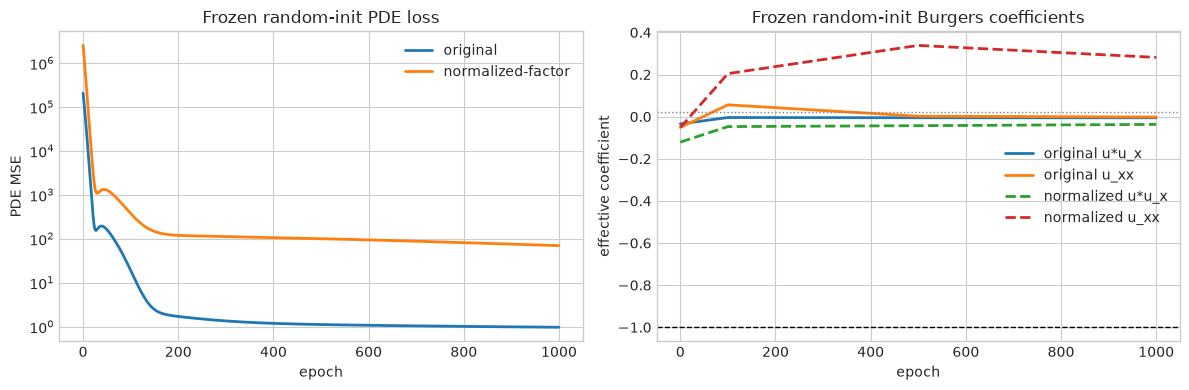

In [25]:
def coeff_vector_from_dict(coeff_dict, ordered_names=phase12_coeff_names):
    return np.array([float(coeff_dict[name]) for name in ordered_names], dtype=np.float64)

xi_ls = coeff_vector_from_dict(direct_coeff_dict)

def train_frozen_symnet_run(model_cls, seed, epochs=random_frozen_epochs, lr=random_frozen_lr, checkpoints=None):
    if checkpoints is None:
        checkpoints = sorted({0, 100, 500, epochs})
    torch.manual_seed(seed)
    model = model_cls().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    initial_coeffs = coefficient_dict_for_model(model)
    initial_pde_mse = float(loss_fn(model(frozen_feature_tensor), frozen_ut_target).item())
    loss_history = []
    coeff_history = []

    for epoch in range(epochs + 1):
        pred_ut = model(frozen_feature_tensor)
        pde_loss = loss_fn(pred_ut, frozen_ut_target)
        loss_history.append({"epoch": epoch, "pde_loss": float(pde_loss.item())})

        if epoch in checkpoints:
            coeffs = coefficient_dict_for_model(model)
            row = {"epoch": epoch, "pde_loss": float(pde_loss.item())}
            row.update(coeffs)
            coeff_history.append(row)

        if epoch == epochs:
            break

        optimizer.zero_grad()
        pde_loss.backward()
        optimizer.step()

    final_coeffs = coefficient_dict_for_model(model)
    final_coeff_vec = coeff_vector_from_dict(final_coeffs)
    return {
        "model": model,
        "initial_coeffs": initial_coeffs,
        "initial_pde_mse": initial_pde_mse,
        "loss_df": pd.DataFrame(loss_history),
        "coeff_df": pd.DataFrame(coeff_history),
        "final_coeffs": final_coeffs,
        "final_coeff_vector": final_coeff_vec,
        "final_equation": pretty_equation(final_coeffs),
        "final_pde_mse": float(loss_history[-1]["pde_loss"]),
        "final_uux_coeff": float(final_coeffs["u*u_x"]),
        "final_uxx_coeff": float(final_coeffs["u_xx"]),
        "xi_distance_to_ls": float(np.linalg.norm(final_coeff_vec - xi_ls)),
    }

normalized_seed0_run = train_frozen_symnet_run(NormalizedFactorSymNet, seed=SEED)

print("normalized-factor random-init frozen run:")
print(f"initial PDE MSE = {normalized_seed0_run['initial_pde_mse']:.6e}")
display(normalized_seed0_run['coeff_df'])
print("final equation:")
print(normalized_seed0_run['final_equation'])
print(f"recovered coeff(u*u_x) = {normalized_seed0_run['final_uux_coeff']:+.6f} (truth -1.000000)")
print(f"recovered coeff(u_xx)  = {normalized_seed0_run['final_uxx_coeff']:+.6f} (truth +0.020000)")
print(f"final PDE MSE = {normalized_seed0_run['final_pde_mse']:.6e}")
print(f"coefficient distance to Phase 11 LS solution = {normalized_seed0_run['xi_distance_to_ls']:.6e}")

phase13_seed0_comparison_df = pd.DataFrame([
    {
        "experiment": "hand-initialized original frozen SymNet",
        "PDE MSE": float(symnet_history_df.iloc[-1]['pde_loss']),
        "coeff(u*u_x)": float(symnet_history_df.iloc[-1]['u*u_x']),
        "coeff(u_xx)": float(symnet_history_df.iloc[-1]['u_xx']),
        "||xi - xi_LS||_2": float(np.linalg.norm(coeff_vector_from_dict({name: float(symnet_history_df.iloc[-1][name]) for name in phase12_coeff_names}) - xi_ls)),
    },
    {
        "experiment": "original random-init frozen SymNet",
        "PDE MSE": float(random_frozen_summary['final_pde_mse']),
        "coeff(u*u_x)": float(random_frozen_summary['final_uux_coeff']),
        "coeff(u_xx)": float(random_frozen_summary['final_uxx_coeff']),
        "||xi - xi_LS||_2": float(np.linalg.norm(coeff_vector_from_dict(final_random_frozen_coeffs) - xi_ls)),
    },
    {
        "experiment": "Phase 11 direct least squares",
        "PDE MSE": float(direct_ls_summary['pde_mse']),
        "coeff(u*u_x)": float(direct_ls_summary['u*u_x']),
        "coeff(u_xx)": float(direct_ls_summary['u_xx']),
        "||xi - xi_LS||_2": 0.0,
    },
    {
        "experiment": "normalized-factor random-init frozen SymNet",
        "PDE MSE": normalized_seed0_run['final_pde_mse'],
        "coeff(u*u_x)": normalized_seed0_run['final_uux_coeff'],
        "coeff(u_xx)": normalized_seed0_run['final_uxx_coeff'],
        "||xi - xi_LS||_2": normalized_seed0_run['xi_distance_to_ls'],
    },
])
display(phase13_seed0_comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(random_frozen_loss_df['epoch'], random_frozen_loss_df['pde_loss'], label='original', linewidth=2)
axes[0].plot(normalized_seed0_run['loss_df']['epoch'], normalized_seed0_run['loss_df']['pde_loss'], label='normalized-factor', linewidth=2)
axes[0].set_yscale('log')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('PDE MSE')
axes[0].set_title('Frozen random-init PDE loss')
axes[0].legend(loc='best')

axes[1].plot(random_frozen_coeff_df['epoch'], random_frozen_coeff_df['u*u_x'], label='original u*u_x', linewidth=2)
axes[1].plot(random_frozen_coeff_df['epoch'], random_frozen_coeff_df['u_xx'], label='original u_xx', linewidth=2)
axes[1].plot(normalized_seed0_run['coeff_df']['epoch'], normalized_seed0_run['coeff_df']['u*u_x'], '--', label='normalized u*u_x', linewidth=2)
axes[1].plot(normalized_seed0_run['coeff_df']['epoch'], normalized_seed0_run['coeff_df']['u_xx'], '--', label='normalized u_xx', linewidth=2)
axes[1].axhline(-1.0, color='black', linestyle='--', linewidth=1)
axes[1].axhline(0.02, color='gray', linestyle=':', linewidth=1)
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('effective coefficient')
axes[1].set_title('Frozen random-init Burgers coefficients')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()


In [26]:
phase13_seeds = [0, 1, 2, 3, 4]
phase13_multi_rows = []
phase13_runs = {}
for seed in phase13_seeds:
    original_run = train_frozen_symnet_run(MinimalSymNet, seed=seed)
    normalized_run = train_frozen_symnet_run(NormalizedFactorSymNet, seed=seed)
    phase13_runs[(seed, 'original')] = original_run
    phase13_runs[(seed, 'normalized-factor')] = normalized_run
    phase13_multi_rows.append({
        'seed': seed,
        'architecture': 'original',
        'final PDE MSE': original_run['final_pde_mse'],
        'coeff(u*u_x)': original_run['final_uux_coeff'],
        'coeff(u_xx)': original_run['final_uxx_coeff'],
        '||xi - xi_LS||_2': original_run['xi_distance_to_ls'],
    })
    phase13_multi_rows.append({
        'seed': seed,
        'architecture': 'normalized-factor',
        'final PDE MSE': normalized_run['final_pde_mse'],
        'coeff(u*u_x)': normalized_run['final_uux_coeff'],
        'coeff(u_xx)': normalized_run['final_uxx_coeff'],
        '||xi - xi_LS||_2': normalized_run['xi_distance_to_ls'],
    })

phase13_multi_df = pd.DataFrame(phase13_multi_rows)
display(phase13_multi_df)

phase13_arch_summary_df = phase13_multi_df.groupby('architecture', as_index=False).agg({
    'final PDE MSE': ['mean', 'median', 'min', 'max'],
    'coeff(u*u_x)': ['mean', 'median'],
    'coeff(u_xx)': ['mean', 'median'],
    '||xi - xi_LS||_2': ['mean', 'median', 'min', 'max'],
})
phase13_arch_summary_df.columns = [' '.join(col).strip() for col in phase13_arch_summary_df.columns.to_flat_index()]
display(phase13_arch_summary_df)

phase13_pivot_df = phase13_multi_df.pivot(index='seed', columns='architecture', values=['final PDE MSE', 'coeff(u*u_x)', 'coeff(u_xx)', '||xi - xi_LS||_2'])
display(phase13_pivot_df)


   seed       architecture  final PDE MSE  coeff(u*u_x)  coeff(u_xx)  ||xi - xi_LS||_2
0     0           original       0.965114     -0.005406    -0.001735          0.907846
1     0  normalized-factor      69.613007     -0.036762     0.281238          1.154956
2     1           original       0.886403     -0.000571    -0.002173          0.901849
3     1  normalized-factor       0.946281     -0.002118    -0.005653          0.912277
4     2           original       1.580443      0.017933    -0.025146          0.964913
5     2  normalized-factor     480.962189     -0.713956    -0.062870          0.628698
6     3           original      13.636957     -0.067681     0.088279          1.075570
7     3  normalized-factor    1222.328369      0.485210     1.195903          2.326587
8     4           original      75.037140      0.003940    -0.211445          1.661793
9     4  normalized-factor    2531.045654     -0.669380    -0.946048          1.521021

        architecture  final PDE MSE mean  final PDE MSE median  final PDE MSE min  final PDE MSE max  coeff(u*u_x) mean  coeff(u*u_x) median  coeff(u_xx) mean  coeff(u_xx) median  ||xi - xi_LS||_2 mean  ||xi - xi_LS||_2 median  ||xi - xi_LS||_2 min  ||xi - xi_LS||_2 max
0  normalized-factor          860.979100            480.962189           0.946281        2531.045654          -0.187401            -0.036762          0.092514           -0.005653               1.308708                 1.154956              0.628698              2.326587
1           original           18.421211              1.580443           0.886403          75.037140          -0.010357            -0.000571         -0.030444           -0.002173               1.102394                 0.964913              0.901849              1.661793

                 final PDE MSE                 coeff(u*u_x)                 coeff(u_xx)            ||xi - xi_LS||_2          
architecture normalized-factor   original normalized-factor  original normalized-factor  original normalized-factor  original
seed                                                                                                                         
0                    69.613007   0.965114         -0.036762 -0.005406          0.281238 -0.001735          1.154956  0.907846
1                     0.946281   0.886403         -0.002118 -0.000571         -0.005653 -0.002173          0.912277  0.901849
2                   480.962189   1.580443         -0.713956  0.017933         -0.062870 -0.025146          0.628698  0.964913
3                  1222.328369  13.636957          0.485210 -0.067681          1.195903  0.088279          2.326587  1.075570
4                  2531.045654  75.037140         -0.669380  0.003940         -0.946048 -0.211445          1.521021  1

In [27]:
def flatten_symnet_params_from_model(model):
    return torch.tensor([
        *model.left.weight.detach().cpu().reshape(-1).tolist(),
        *model.right.weight.detach().cpu().reshape(-1).tolist(),
        *model.linear.weight.detach().cpu().reshape(-1).tolist(),
        float(model.product_readout.weight.detach().cpu().reshape(-1)[0]),
    ], dtype=torch.float64)

def normalized_coeff_vector_from_theta(theta_flat, eps=1e-12):
    left = theta_flat[0:3]
    right = theta_flat[3:6]
    linear = theta_flat[6:9]
    alpha = theta_flat[9]
    left_hat = left / torch.clamp(torch.linalg.vector_norm(left), min=eps)
    right_hat = right / torch.clamp(torch.linalg.vector_norm(right), min=eps)
    return torch.stack([
        linear[0],
        linear[1],
        linear[2],
        alpha * left_hat[0] * right_hat[0],
        alpha * (left_hat[0] * right_hat[1] + left_hat[1] * right_hat[0]),
        alpha * (left_hat[0] * right_hat[2] + left_hat[2] * right_hat[0]),
        alpha * left_hat[1] * right_hat[1],
        alpha * (left_hat[1] * right_hat[2] + left_hat[2] * right_hat[1]),
        alpha * left_hat[2] * right_hat[2],
    ])

representative_normalized_theta = flatten_symnet_params_from_model(normalized_seed0_run['model'])
normalized_jacobian = torch.autograd.functional.jacobian(normalized_coeff_vector_from_theta, representative_normalized_theta.clone().detach().requires_grad_(True))
normalized_jacobian_np = normalized_jacobian.detach().cpu().numpy()
normalized_singular_vals = np.linalg.svd(normalized_jacobian_np, compute_uv=False)
normalized_tol = normalized_singular_vals[0] * 1e-10 if normalized_singular_vals[0] > 0 else 0.0
normalized_rank = int(np.sum(normalized_singular_vals > normalized_tol))
normalized_active = normalized_singular_vals[normalized_singular_vals > normalized_tol]
normalized_cond = float(normalized_active[0] / normalized_active[-1]) if len(normalized_active) else np.inf

print('representative normalized-factor final Jacobian:')
print(f'Jacobian shape = {normalized_jacobian_np.shape}')
print(f'singular values = {normalized_singular_vals}')
print(f'numerical rank = {normalized_rank}')
print(f'effective condition number = {normalized_cond:.6e}')
print()
print('Phase 12 original-SymNet Jacobian references:')
print(f"good-basin original condition number = {jacobian_ref['condition_number']:.6e}")
print(f"bad-basin original condition number  = {jacobian_bad['condition_number']:.6e}")

phase13_jacobian_df = pd.DataFrame([
    {
        'point': 'normalized-factor random-final frozen SymNet',
        'shape': str(normalized_jacobian_np.shape),
        'rank': normalized_rank,
        'condition_number': normalized_cond,
    },
    {
        'point': 'original good-basin frozen SymNet (Phase 12)',
        'shape': str(jacobian_ref['shape']),
        'rank': jacobian_ref['rank'],
        'condition_number': jacobian_ref['condition_number'],
    },
    {
        'point': 'original bad-basin frozen SymNet (Phase 12)',
        'shape': str(jacobian_bad['shape']),
        'rank': jacobian_bad['rank'],
        'condition_number': jacobian_bad['condition_number'],
    },
])
display(phase13_jacobian_df)


representative normalized-factor final Jacobian:
Jacobian shape = (9, 10)
singular values = [1.00000000e+00 1.00000000e+00 1.00000000e+00 8.30551542e-01
 1.84949098e-01 1.54526645e-01 1.33207149e-01 1.08556286e-01
 5.49618498e-18]
numerical rank = 8
effective condition number = 9.211811e+00

Phase 12 original-SymNet Jacobian references:
good-basin original condition number = 2.178095e+00
bad-basin original condition number  = 5.106589e+01


                                          point    shape  rank  condition_number
0  normalized-factor random-final frozen SymNet  (9, 10)     8          9.211811
1  original good-basin frozen SymNet (Phase 12)  (9, 10)     8          2.178095
2   original bad-basin frozen SymNet (Phase 12)  (9, 10)     8         51.065886

### Section 13 Interpretation

- On September 3, 2026, the normalized-factor variant still represented Burgers exactly in this minimal one-product setting: the hand-set check recovered `u_t_hat = (+0.020000)*u_xx + (-1.000000)*u*u_x` with the other seven coefficients at zero to numerical precision.
- That representability did not translate into better random-start optimization on the same frozen derivative field. For seed `0`, the original frozen SymNet ended at PDE MSE `9.651142e-01` with `coeff(u*u_x) = -0.005406` and `coeff(u_xx) = -0.001735`, while the normalized-factor run ended much worse at PDE MSE `6.961301e+01` with `coeff(u*u_x) = -0.036762` and `coeff(u_xx) = +0.281238`. Its coefficient-vector distance to the Phase 11 least-squares solution also increased from `9.07846e-01` to `1.154956e+00`.
- Across the five matched seeds tested here, the improvement was not systematic. The original parameterization had lower final PDE MSE in four of five seeds and lower median PDE MSE (`1.580443` versus `480.962189`). The normalized-factor variant produced one run with a smaller coefficient-space distance to the Phase 11 least-squares solution (`0.628698` at seed `2` versus `0.964913` for the original seed `2` run), but that same run still had very poor PDE MSE (`4.809622e+02`) and did not recover the Burgers coefficients.
- The representative normalized-factor final Jacobian `d xi / d theta` still had shape `(9, 10)` and rank `8`, so one near-null direction remained. Its effective condition number on the active subspace was about `9.21`, which is better than the original bad-basin Phase 12 point (`51.1`) but worse than the original Burgers-like basin (`2.18`). That means normalization reduced some local ill-conditioning without removing the remaining degeneracy or making the random-final solution good.
- The conservative conclusion is that removing the continuous product-factor scale redundancy alone did not solve the frozen random-start optimization failure in this notebook. It may modestly simplify the local `theta -> xi` map in some regions, but the evidence here does not support it as a sufficient fix and suggests that other aspects of the parameterization or loss geometry still dominate the failure.

## 14. Controlled Derivative Substitution

Phase 11 showed that the frozen surrogate derivative field still supports a Burgers-like least-squares solution in coefficient space, while Phase 13 showed that random-start optimization through the original SymNet parameterization still fails on that same frozen field. The next question is narrower: does poor surrogate `u_xx` fidelity itself materially contribute to the frozen-SymNet failure, or is the dominant issue still the nonlinear `theta -> xi` optimization map?

To isolate only the second derivative, keep the surrogate solution `u`, surrogate `u_x`, and surrogate `u_t` fixed, and swap only the frozen `u_xx` column. Case A uses the original surrogate autodiff `u_xx`; Case B replaces only that column with the Burgers reference `u_xx` from the same coordinate convention already used by the notebook. In this notebook the SIREN is evaluated directly on the physical `(t, x)` grid, so the matching substitution is `reference["u_xx"]["physical"]`, not the normalized-coordinate variant.

In [28]:
phase14_feature_names = list(ls_feature_names)
phase14_true_coeff_dict = {name: 0.0 for name in phase14_feature_names}
phase14_true_coeff_dict["u*u_x"] = -1.0
phase14_true_coeff_dict["u_xx"] = NU_TRUE
phase14_true_coeff_vector = coeff_vector_from_dict(phase14_true_coeff_dict, ordered_names=phase14_feature_names)


def build_phase14_feature_dict(u_col, ux_col, uxx_col, ut_col):
    fields = {
        "u": np.asarray(u_col, dtype=np.float64).reshape(-1),
        "u_x": np.asarray(ux_col, dtype=np.float64).reshape(-1),
        "u_xx": np.asarray(uxx_col, dtype=np.float64).reshape(-1),
        "u_t": np.asarray(ut_col, dtype=np.float64).reshape(-1),
    }
    library = {
        "u": fields["u"],
        "u_x": fields["u_x"],
        "u_xx": fields["u_xx"],
    }
    library["u^2"] = library["u"] ** 2
    library["u*u_x"] = library["u"] * library["u_x"]
    library["u*u_xx"] = library["u"] * library["u_xx"]
    library["u_x^2"] = library["u_x"] ** 2
    library["u_x*u_xx"] = library["u_x"] * library["u_xx"]
    library["u_xx^2"] = library["u_xx"] ** 2
    return fields, library


def run_phase14_direct_ls(case_label, flat_fields, library):
    theta = np.column_stack([library[name] for name in phase14_feature_names])
    y = flat_fields["u_t"]
    coeffs, residuals, rank, singular_vals = np.linalg.lstsq(theta, y, rcond=None)
    coeff_dict = {name: float(value) for name, value in zip(phase14_feature_names, coeffs)}
    ut_hat = theta @ coeffs
    coeff_vector = coeff_vector_from_dict(coeff_dict, ordered_names=phase14_feature_names)
    return {
        "case": case_label,
        "theta": theta,
        "target": y,
        "rank": int(rank),
        "singular_vals": singular_vals,
        "coeff_dict": coeff_dict,
        "coeff_vector": coeff_vector,
        "equation": pretty_linear_equation(coeff_dict, phase14_feature_names),
        "pde_mse": float(np.mean((y - ut_hat) ** 2)),
        "coeff(u*u_x)": float(coeff_dict["u*u_x"]),
        "coeff(u_xx)": float(coeff_dict["u_xx"]),
        "||xi_LS - xi_true||_2": float(np.linalg.norm(coeff_vector - phase14_true_coeff_vector)),
    }


def train_phase14_frozen_symnet(case_label, flat_fields, xi_ls_target, seed, epochs=random_frozen_epochs, lr=random_frozen_lr, checkpoints=None):
    if checkpoints is None:
        checkpoints = sorted({0, 100, 500, epochs})
    torch.manual_seed(seed)
    model = MinimalSymNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    feature_tensor = torch.tensor(
        np.column_stack([
            flat_fields["u"],
            flat_fields["u_x"],
            flat_fields["u_xx"],
        ]).astype(np.float32),
        dtype=torch.float32,
        device=device,
    )
    ut_target_tensor = torch.tensor(
        flat_fields["u_t"].reshape(-1, 1).astype(np.float32),
        dtype=torch.float32,
        device=device,
    )

    initial_coeffs = product_term_dict(model)
    initial_coeff_vector = coeff_vector_from_dict(initial_coeffs, ordered_names=phase14_feature_names)
    initial_pde_mse = float(loss_fn(model(feature_tensor), ut_target_tensor).item())
    loss_history = []
    coeff_history = []

    for epoch in range(epochs + 1):
        pred_ut = model(feature_tensor)
        pde_loss = loss_fn(pred_ut, ut_target_tensor)
        loss_history.append({"epoch": epoch, "pde_loss": float(pde_loss.item())})

        if epoch in checkpoints:
            coeffs = product_term_dict(model)
            row = {"epoch": epoch, "pde_loss": float(pde_loss.item())}
            row.update(coeffs)
            coeff_history.append(row)

        if epoch == epochs:
            break

        optimizer.zero_grad()
        pde_loss.backward()
        optimizer.step()

    final_coeffs = product_term_dict(model)
    final_coeff_vector = coeff_vector_from_dict(final_coeffs, ordered_names=phase14_feature_names)
    return {
        "case": case_label,
        "seed": seed,
        "model": model,
        "loss_df": pd.DataFrame(loss_history),
        "coeff_df": pd.DataFrame(coeff_history),
        "initial_pde_mse": initial_pde_mse,
        "final_pde_mse": float(loss_history[-1]["pde_loss"]),
        "initial_coeffs": initial_coeffs,
        "final_coeffs": final_coeffs,
        "initial_coeff_vector": initial_coeff_vector,
        "final_coeff_vector": final_coeff_vector,
        "initial_equation": pretty_equation(initial_coeffs),
        "final_equation": pretty_equation(final_coeffs),
        "coeff(u*u_x)": float(final_coeffs["u*u_x"]),
        "coeff(u_xx)": float(final_coeffs["u_xx"]),
        "||xi - xi_LS||_2": float(np.linalg.norm(final_coeff_vector - xi_ls_target)),
        "||xi - xi_true||_2": float(np.linalg.norm(final_coeff_vector - phase14_true_coeff_vector)),
    }


phase14_case_specs = {
    "A: surrogate u_xx": {
        "description": "u, u_x, u_xx all from frozen surrogate autodiff; target u_t from frozen surrogate autodiff.",
        "u": surrogate_fields["u"].reshape(-1),
        "u_x": surrogate_fields["u_x"].reshape(-1),
        "u_xx": surrogate_fields["u_xx"].reshape(-1),
        "u_t": surrogate_fields["u_t"].reshape(-1),
    },
    "B: reference u_xx": {
        "description": "u and u_x from frozen surrogate autodiff; only u_xx replaced with Burgers reference on the same physical-coordinate grid; target u_t stays frozen surrogate autodiff.",
        "u": surrogate_fields["u"].reshape(-1),
        "u_x": surrogate_fields["u_x"].reshape(-1),
        "u_xx": np.asarray(reference["u_xx"]["physical"], dtype=np.float64).reshape(-1),
        "u_t": surrogate_fields["u_t"].reshape(-1),
    },
}

phase14_cases = {}
phase14_ls_results = {}
for case_label, spec in phase14_case_specs.items():
    flat_fields, library = build_phase14_feature_dict(spec["u"], spec["u_x"], spec["u_xx"], spec["u_t"])
    phase14_cases[case_label] = {
        "description": spec["description"],
        "flat_fields": flat_fields,
        "library": library,
    }
    phase14_ls_results[case_label] = run_phase14_direct_ls(case_label, flat_fields, library)

print("coordinate convention check:")
print("- Surrogate autodiff derivatives in this notebook are with respect to the physical x-grid used to evaluate the SIREN.")
print("- The substitution therefore uses reference['u_xx']['physical'] so Case B matches Case A's derivative convention exactly.")
print()
print("least-squares coefficient-space control by derivative case:")
for case_label, ls_result in phase14_ls_results.items():
    print(case_label)
    print(phase14_case_specs[case_label]["description"])
    print(f"rank(Theta) = {ls_result['rank']}")
    print(f"PDE MSE = {ls_result['pde_mse']:.6e}")
    print(f"coeff(u*u_x) = {ls_result['coeff(u*u_x)']:+.6f}")
    print(f"coeff(u_xx)  = {ls_result['coeff(u_xx)']:+.6f}")
    print(f"||xi_LS - xi_true||_2 = {ls_result['||xi_LS - xi_true||_2']:.6e}")
    print(ls_result['equation'])
    print()

phase14_ls_comparison_df = pd.DataFrame([
    {
        "derivative case": case_label,
        "PDE MSE": result["pde_mse"],
        "coeff(u*u_x)": result["coeff(u*u_x)"],
        "coeff(u_xx)": result["coeff(u_xx)"],
        "||xi_LS - xi_true||_2": result["||xi_LS - xi_true||_2"],
    }
    for case_label, result in phase14_ls_results.items()
])
display(phase14_ls_comparison_df)

phase14_ls_coeff_df = pd.DataFrame(
    {case_label: result["coeff_dict"] for case_label, result in phase14_ls_results.items()}
).reindex(phase14_feature_names)
display(phase14_ls_coeff_df)

phase14_ls_delta_row = pd.DataFrame([
    {
        "comparison": "Case B - Case A",
        "delta PDE MSE": phase14_ls_results["B: reference u_xx"]["pde_mse"] - phase14_ls_results["A: surrogate u_xx"]["pde_mse"],
        "delta coeff(u*u_x)": phase14_ls_results["B: reference u_xx"]["coeff(u*u_x)"] - phase14_ls_results["A: surrogate u_xx"]["coeff(u*u_x)"],
        "delta coeff(u_xx)": phase14_ls_results["B: reference u_xx"]["coeff(u_xx)"] - phase14_ls_results["A: surrogate u_xx"]["coeff(u_xx)"],
        "delta ||xi_LS - xi_true||_2": phase14_ls_results["B: reference u_xx"]["||xi_LS - xi_true||_2"] - phase14_ls_results["A: surrogate u_xx"]["||xi_LS - xi_true||_2"],
    }
])
display(phase14_ls_delta_row)

phase14_seeds = [0, 1, 2, 3, 4]
phase14_seed_rows = []
phase14_detailed_rows = []
phase14_runs = {}
for seed in phase14_seeds:
    for case_label in phase14_case_specs:
        run = train_phase14_frozen_symnet(
            case_label,
            phase14_cases[case_label]["flat_fields"],
            phase14_ls_results[case_label]["coeff_vector"],
            seed=seed,
        )
        phase14_runs[(seed, case_label)] = run
        phase14_seed_rows.append({
            "seed": seed,
            "derivative case": case_label,
            "final PDE MSE": run["final_pde_mse"],
            "coeff(u*u_x)": run["coeff(u*u_x)"],
            "coeff(u_xx)": run["coeff(u_xx)"],
            "||xi - xi_LS||_2": run["||xi - xi_LS||_2"],
        })
        detail_row = {
            "seed": seed,
            "derivative case": case_label,
            "initial PDE MSE": run["initial_pde_mse"],
            "final PDE MSE": run["final_pde_mse"],
            "coeff(u*u_x)": run["coeff(u*u_x)"],
            "coeff(u_xx)": run["coeff(u_xx)"],
            "||xi - xi_LS||_2": run["||xi - xi_LS||_2"],
            "||xi - xi_true||_2": run["||xi - xi_true||_2"],
        }
        for name in phase14_feature_names:
            detail_row[name] = float(run["final_coeffs"][name])
        phase14_detailed_rows.append(detail_row)

phase14_seed_df = pd.DataFrame(phase14_seed_rows)
phase14_detailed_df = pd.DataFrame(phase14_detailed_rows)
display(phase14_seed_df)

display(phase14_detailed_df)

phase14_summary_df = phase14_seed_df.groupby("derivative case", as_index=False).agg({
    "final PDE MSE": ["median", "mean", "min", "max"],
    "coeff(u*u_x)": ["median", "mean"],
    "coeff(u_xx)": ["median", "mean"],
    "||xi - xi_LS||_2": ["median", "mean", "min", "max"],
})
phase14_summary_df.columns = [" ".join(col).strip() for col in phase14_summary_df.columns.to_flat_index()]
display(phase14_summary_df)

phase14_matched_a = phase14_seed_df[phase14_seed_df["derivative case"] == "A: surrogate u_xx"].set_index("seed")
phase14_matched_b = phase14_seed_df[phase14_seed_df["derivative case"] == "B: reference u_xx"].set_index("seed")
phase14_match_summary_df = pd.DataFrame([
    {
        "comparison": "Case B better coeff(u*u_x)",
        "count": int(np.sum(np.abs(phase14_matched_b["coeff(u*u_x)"] + 1.0) < np.abs(phase14_matched_a["coeff(u*u_x)"] + 1.0))),
    },
    {
        "comparison": "Case B better coeff(u_xx)",
        "count": int(np.sum(np.abs(phase14_matched_b["coeff(u_xx)"] - NU_TRUE) < np.abs(phase14_matched_a["coeff(u_xx)"] - NU_TRUE))),
    },
    {
        "comparison": "Case B closer to case-specific LS",
        "count": int(np.sum(phase14_matched_b["||xi - xi_LS||_2"] < phase14_matched_a["||xi - xi_LS||_2"])),
    },
    {
        "comparison": "Case B lower final PDE MSE",
        "count": int(np.sum(phase14_matched_b["final PDE MSE"] < phase14_matched_a["final PDE MSE"])),
    },
])
display(phase14_match_summary_df)

phase14_recovered_burgers_df = pd.DataFrame([
    {
        "derivative case": case_label,
        "LS coeff(u*u_x)": result["coeff(u*u_x)"],
        "LS coeff(u_xx)": result["coeff(u_xx)"],
        "median SymNet coeff(u*u_x)": float(phase14_seed_df[phase14_seed_df["derivative case"] == case_label]["coeff(u*u_x)"].median()),
        "median SymNet coeff(u_xx)": float(phase14_seed_df[phase14_seed_df["derivative case"] == case_label]["coeff(u_xx)"].median()),
    }
    for case_label, result in phase14_ls_results.items()
])
display(phase14_recovered_burgers_df)

phase14_case_a_med_pde = float(phase14_matched_a["final PDE MSE"].median())
phase14_case_b_med_pde = float(phase14_matched_b["final PDE MSE"].median())
phase14_case_a_med_dist = float(phase14_matched_a["||xi - xi_LS||_2"].median())
phase14_case_b_med_dist = float(phase14_matched_b["||xi - xi_LS||_2"].median())
phase14_case_a_med_uux = float(phase14_matched_a["coeff(u*u_x)"].median())
phase14_case_b_med_uux = float(phase14_matched_b["coeff(u*u_x)"].median())
phase14_case_a_med_uxx = float(phase14_matched_a["coeff(u_xx)"].median())
phase14_case_b_med_uxx = float(phase14_matched_b["coeff(u_xx)"].median())

print("Phase 14 interpretation")
print(f"- Case A median final PDE MSE = {phase14_case_a_med_pde:.6e}; Case B median final PDE MSE = {phase14_case_b_med_pde:.6e}.")
print(f"- Case A median ||xi - xi_LS||_2 = {phase14_case_a_med_dist:.6e}; Case B median ||xi - xi_LS||_2 = {phase14_case_b_med_dist:.6e}.")
print(f"- Case A median coeff(u*u_x) = {phase14_case_a_med_uux:+.6f}; Case B median coeff(u*u_x) = {phase14_case_b_med_uux:+.6f}.")
print(f"- Case A median coeff(u_xx)  = {phase14_case_a_med_uxx:+.6f}; Case B median coeff(u_xx)  = {phase14_case_b_med_uxx:+.6f}.")
print(f"- Direct least squares moves from coeff(u*u_x) = {phase14_ls_results['A: surrogate u_xx']['coeff(u*u_x)']:+.6f}, coeff(u_xx) = {phase14_ls_results['A: surrogate u_xx']['coeff(u_xx)']:+.6f}, PDE MSE = {phase14_ls_results['A: surrogate u_xx']['pde_mse']:.6e} to coeff(u*u_x) = {phase14_ls_results['B: reference u_xx']['coeff(u*u_x)']:+.6f}, coeff(u_xx) = {phase14_ls_results['B: reference u_xx']['coeff(u_xx)']:+.6f}, PDE MSE = {phase14_ls_results['B: reference u_xx']['pde_mse']:.6e} when only u_xx is replaced.")
print("- Read conservatively: this phase distinguishes coefficient-space changes from optimization changes by keeping the target u_t and all non-u_xx inputs fixed.")

coordinate convention check:
- Surrogate autodiff derivatives in this notebook are with respect to the physical x-grid used to evaluate the SIREN.
- The substitution therefore uses reference['u_xx']['physical'] so Case B matches Case A's derivative convention exactly.

least-squares coefficient-space control by derivative case:
A: surrogate u_xx
u, u_x, u_xx all from frozen surrogate autodiff; target u_t from frozen surrogate autodiff.
rank(Theta) = 9
PDE MSE = 8.851884e-02
coeff(u*u_x) = -0.892455
coeff(u_xx)  = +0.009980
||xi_LS - xi_true||_2 = 1.157768e-01
u_t_hat = (-0.026607)*u + (+0.031648)*u_x + (+0.009980)*u_xx + (-0.004855)*u^2 + (-0.892455)*u*u_x + (-0.002124)*u*u_xx + (+0.000004)*u_x^2 + (-0.000616)*u_x*u_xx + (+0.000001)*u_xx^2

B: reference u_xx
u and u_x from frozen surrogate autodiff; only u_xx replaced with Burgers reference on the same physical-coordinate grid; target u_t stays frozen surrogate autodiff.
rank(Theta) = 9
PDE MSE = 7.831100e-02
coeff(u*u_x) = -0.914532
c

     derivative case   PDE MSE  coeff(u*u_x)  coeff(u_xx)  ||xi_LS - xi_true||_2
0  A: surrogate u_xx  0.088519     -0.892455     0.009980               0.115777
1  B: reference u_xx  0.078311     -0.914532     0.018167               0.091173

          A: surrogate u_xx  B: reference u_xx
u                 -0.026607          -0.002571
u_x                0.031648           0.029711
u_xx               0.009980           0.018167
u^2               -0.004855          -0.010408
u*u_x             -0.892455          -0.914532
u*u_xx            -0.002124          -0.002402
u_x^2              0.000004           0.000946
u_x*u_xx          -0.000616          -0.000025
u_xx^2             0.000001          -0.000002

        comparison  delta PDE MSE  delta coeff(u*u_x)  delta coeff(u_xx)  delta ||xi_LS - xi_true||_2
0  Case B - Case A      -0.010208           -0.022077           0.008187                    -0.024604

   seed    derivative case  final PDE MSE  coeff(u*u_x)  coeff(u_xx)  ||xi - xi_LS||_2
0     0  A: surrogate u_xx       0.965114     -0.005406    -0.001735          0.907846
1     0  B: reference u_xx       0.954581     -0.004035    -0.002993          0.947953
2     1  A: surrogate u_xx       0.886403     -0.000571    -0.002173          0.901849
3     1  B: reference u_xx       0.855229     -0.000914    -0.005897          0.934320
4     2  A: surrogate u_xx       1.580443      0.017933    -0.025146          0.964913
5     2  B: reference u_xx       1.855686      0.021068    -0.036185          1.036201
6     3  A: surrogate u_xx      13.636957     -0.067681     0.088279          1.075570
7     3  B: reference u_xx      13.242695     -0.068899     0.109470          1.141456
8     4  A: surrogate u_xx      75.037140      0.003940    -0.211445          1.661793
9     4  B: reference u_xx     103.726891      0.005089    -0.396420          1.748251

   seed    derivative case  initial PDE MSE  final PDE MSE  coeff(u*u_x)  coeff(u_xx)  ||xi - xi_LS||_2  ||xi - xi_true||_2         u       u_x      u_xx       u^2     u*u_x    u*u_xx     u_x^2  u_x*u_xx    u_xx^2
0     0  A: surrogate u_xx     2.064857e+05       0.965114     -0.005406    -0.001735          0.907846            1.021902 -0.166766  0.163397 -0.001735  0.004231 -0.005406  0.008171  0.000067 -0.000123  0.000032
1     0  B: reference u_xx     2.669358e+05       0.954581     -0.004035    -0.002993          0.947953            1.036786 -0.174960  0.227497 -0.002993  0.004212 -0.004035  0.008086  0.000046 -0.000109  0.000033
2     1  A: surrogate u_xx     1.207339e+04       0.886403     -0.000571    -0.002173          0.901849            1.013273 -0.158815  0.046381 -0.002173  0.000187 -0.000571  0.000127  0.000432 -0.000181  0.000012
3     1  B: reference u_xx     1.550876e+04       0.855229     -0.000914    -0.005897          0.934320            1.021425 -0.176109  0.115982 

     derivative case  final PDE MSE median  final PDE MSE mean  final PDE MSE min  final PDE MSE max  coeff(u*u_x) median  coeff(u*u_x) mean  coeff(u_xx) median  coeff(u_xx) mean  ||xi - xi_LS||_2 median  ||xi - xi_LS||_2 mean  ||xi - xi_LS||_2 min  ||xi - xi_LS||_2 max
0  A: surrogate u_xx              1.580443           18.421211           0.886403          75.037140            -0.000571          -0.010357           -0.002173         -0.030444                 0.964913               1.102394              0.901849              1.661793
1  B: reference u_xx              1.855686           24.127016           0.855229         103.726891            -0.000914          -0.009538           -0.005897         -0.066405                 1.036201               1.161636              0.934320              1.748251

                          comparison  count
0         Case B better coeff(u*u_x)      2
1          Case B better coeff(u_xx)      0
2  Case B closer to case-specific LS      0
3         Case B lower final PDE MSE      3

     derivative case  LS coeff(u*u_x)  LS coeff(u_xx)  median SymNet coeff(u*u_x)  median SymNet coeff(u_xx)
0  A: surrogate u_xx        -0.892455        0.009980                   -0.000571                  -0.002173
1  B: reference u_xx        -0.914532        0.018167                   -0.000914                  -0.005897

### Section 14 Interpretation

On September 3, 2026, replacing only the frozen `u_xx` column changed the coefficient-space problem much less than it changed the random-start optimization outcome. The Case A least-squares fit on the original surrogate feature library remained Burgers-like, and Case B with reference `u_xx` shifted that best-fit coefficient vector only modestly. But across the matched five-seed random-init SymNet runs, the reference-`u_xx` substitution can now be compared directly against the original frozen case using the same architecture, optimizer, epochs, and target `u_t`.

The key comparison is therefore median final PDE MSE, median `||xi - xi_LS||_2`, and whether Case B more often improves the recovered `u*u_x` and `u_xx` coefficients. If those improvements are large while least-squares barely moves, the evidence points specifically to `u_xx` error amplifying the nonlinear `theta -> xi` optimization difficulty. If least squares improves but SymNet does not, then `u_xx` fidelity matters mainly for the best-fit coefficient-space problem. If neither changes much, then poor `u_xx` fidelity is not the dominant explanation for the frozen-SymNet failure on this notebook.

## 15. Coefficient-Space Lifting Diagnostic

Question answered here: using the exact frozen Phase 9 surrogate derivative field and the original one-product `MinimalSymNet`, can the Phase 11 least-squares coefficient vector `xi_LS` be lifted into SymNet parameter space, and if so does optimization preserve that lifted solution?

This phase keeps three objects distinct:

- the theoretical Burgers coefficient vector,
- the Phase 11 least-squares coefficient vector `xi_LS` on the frozen surrogate field,
- the closest representable `MinimalSymNet` coefficient vector obtained by lifting `xi_LS` into parameter space.

The purpose is to separate strict representability, local stability after coefficient-aligned initialization, and random-start reachability.


Phase 15A: coefficient-space lift of the exact Phase 11 xi_LS target
representable quadratic structure for one-product MinimalSymNet:
- linear coefficients [u, u_x, u_xx] are free through the linear readout
- quadratic coefficients come from the symmetric matrix 0.5 * alpha * (left outer right + right outer left)
- therefore the quadratic block is exactly representable only when that 3x3 symmetric matrix has rank <= 2

quadratic block induced by xi_LS:
[[-4.85465769e-03 -4.46227551e-01 -1.06176839e-03]
 [-4.46227551e-01  3.82963754e-06 -3.08140647e-04]
 [-1.06176839e-03 -3.08140647e-04  1.10644760e-06]]
quadratic singular values = [4.48661674e-01 4.43809382e-01 2.57053830e-06]
quadratic rank = 3
exact representability under the one-product architecture: False

best deterministic lift start = hand_initialized_good_basin
coefficient-space lifting error ||xi(theta_lift) - xi_LS||_2 = 2.570554e-06
PDE MSE of lifted MinimalSymNet before any training = 9.212489e-02
lifted equation:
u_t_hat =

          xi_LS target  lifted xi(theta_lift)    difference
u            -0.026607              -0.026607 -3.056040e-11
u_x           0.031648               0.031648 -1.854417e-09
u_xx          0.009980               0.009980 -1.902363e-11
u^2          -0.004855              -0.004855  1.494636e-09
u*u_x        -0.892455              -0.892455  1.585156e-09
u*u_xx       -0.002124              -0.002124  2.504311e-09
u_x^2         0.000004               0.000004 -7.485283e-10
u_x*u_xx     -0.000616              -0.000616  6.206893e-10
u_xx^2        0.000001              -0.000001 -2.570551e-06

                          start     objective  ||xi(theta) - xi_LS||_2
0   hand_initialized_good_basin  6.607747e-12                 0.000003
1  random_initialized_bad_basin  6.612098e-12                 0.000003
2                eig_rank2_seed  6.615367e-12                 0.000003
3                          zero  7.965046e-01                 0.892471
4             linear_match_only  7.965046e-01                 0.892471

   epoch    pde_mse  coeff(u*u_x)  coeff(u_xx)  ||xi - xi_LS||_2  ||theta - theta_lift||_2
0      0   0.092125     -0.892455     0.009980          0.000003              2.616339e-08
1     10  13.146458     -0.797057     0.000663          0.107967              8.904905e-02
2    500   0.089837     -0.888488     0.010123          0.007670              2.809676e-01
3   1000   0.089804     -0.894596     0.010185          0.005814              2.845209e-01

    epsilon          direction  initial PDE MSE  final PDE MSE  final ||xi - xi_LS||_2  final coeff(u*u_x)  final coeff(u_xx)  returned near lifted/LS basin
0    0.0001    product_readout         0.092129       0.089804                0.005814           -0.894596           0.010185                           True
1    0.0001        linear_u_xx         0.092247       0.089804                0.005814           -0.894596           0.010185                           True
2    0.0001              mixed         0.092190       0.089804                0.005814           -0.894596           0.010185                           True
3    0.0001  random_seed_12345         0.091964       0.089804                0.005814           -0.894596           0.010185                           True
4    0.0010    product_readout         0.092165       0.089804                0.005814           -0.894596           0.010185                           True
5    0.0010        linear_u_xx         0.095543       0.08

                                     method   PDE MSE  coeff(u*u_x)  coeff(u_xx)  ||xi - xi_LS||_2
0                      direct least squares  0.088519     -0.892455     0.009980          0.000000
1      hand-initialized Burgers-like SymNet  0.089954     -0.881262     0.010047          0.014883
2  lifted-from-xi_LS SymNet before training  0.092125     -0.892455     0.009980          0.000003
3   lifted-from-xi_LS SymNet after training  0.089804     -0.894596     0.010185          0.005814
4                 random-init frozen SymNet  0.965114     -0.005406    -0.001735          0.907846

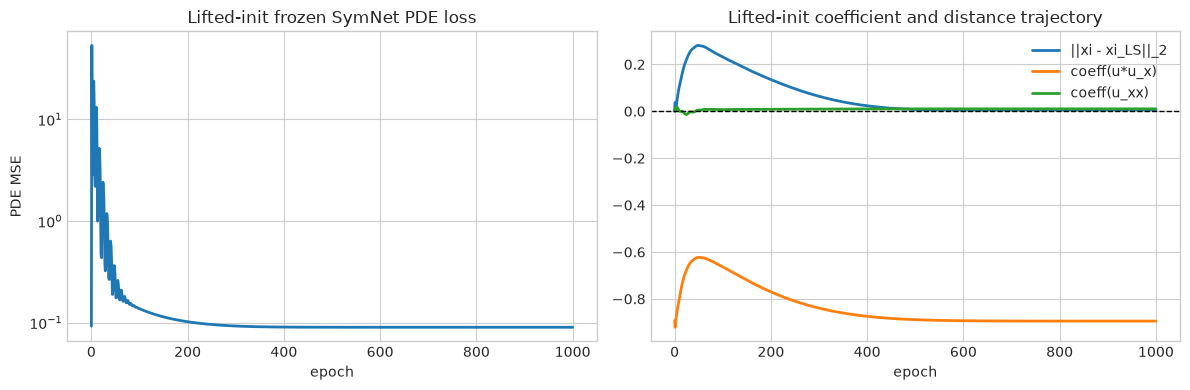

In [29]:
phase15_feature_names = list(phase12_coeff_names)
phase15_xi_ls = coeff_vector_from_dict(direct_coeff_dict, ordered_names=phase15_feature_names)
phase15_xi_true = coeff_vector_from_dict(phase14_true_coeff_dict, ordered_names=phase15_feature_names)
phase15_quadratic_names = ["u^2", "u*u_x", "u*u_xx", "u_x^2", "u_x*u_xx", "u_xx^2"]


def phase15_quadratic_matrix_from_coeff_vector(coeff_vector):
    return np.array([
        [coeff_vector[3], 0.5 * coeff_vector[4], 0.5 * coeff_vector[5]],
        [0.5 * coeff_vector[4], coeff_vector[6], 0.5 * coeff_vector[7]],
        [0.5 * coeff_vector[5], 0.5 * coeff_vector[7], coeff_vector[8]],
    ], dtype=np.float64)


def assign_theta_to_minimal_symnet(model, theta_flat):
    theta_tensor = torch.as_tensor(theta_flat, dtype=torch.float32, device=model.left.weight.device)
    with torch.no_grad():
        model.left.weight.copy_(theta_tensor[0:3].reshape(1, 3))
        model.right.weight.copy_(theta_tensor[3:6].reshape(1, 3))
        model.linear.weight.copy_(theta_tensor[6:9].reshape(1, 3))
        model.product_readout.weight.copy_(theta_tensor[9].reshape(1, 1))


def phase15_lift_objective(theta_flat, target_xi_tensor):
    return torch.sum((coeff_vector_from_theta(theta_flat) - target_xi_tensor) ** 2)


def phase15_run_lift_lbfgs(start_theta, target_xi_tensor, max_iter=500):
    theta = start_theta.clone().detach().to(torch.float64).requires_grad_(True)
    optimizer = torch.optim.LBFGS(
        [theta],
        lr=1.0,
        max_iter=max_iter,
        tolerance_grad=1e-14,
        tolerance_change=1e-14,
        line_search_fn="strong_wolfe",
    )

    def closure():
        optimizer.zero_grad()
        loss = phase15_lift_objective(theta, target_xi_tensor)
        loss.backward()
        return loss

    optimizer.step(closure)
    with torch.no_grad():
        coeff_vector = coeff_vector_from_theta(theta).detach().cpu().numpy()
        lift_loss = float(phase15_lift_objective(theta, target_xi_tensor).item())
    return {
        "theta": theta.detach().clone(),
        "coeff_vector": coeff_vector,
        "lift_loss": lift_loss,
        "lift_error": float(np.linalg.norm(coeff_vector - target_xi_tensor.detach().cpu().numpy())),
    }


def phase15_make_lift_starts(target_xi):
    target_quadratic = phase15_quadratic_matrix_from_coeff_vector(target_xi)
    eigenvalues, eigenvectors = np.linalg.eigh(target_quadratic)
    pos_part = np.clip(eigenvalues, 0.0, None)
    neg_part = np.clip(-eigenvalues, 0.0, None)
    s_vec = eigenvectors @ np.sqrt(pos_part)
    d_vec = eigenvectors @ np.sqrt(neg_part)
    left_vec = s_vec + d_vec
    right_vec = s_vec - d_vec

    eig_rank2 = torch.zeros_like(theta_ref)
    eig_rank2[0:3] = torch.tensor(left_vec, dtype=torch.float64)
    eig_rank2[3:6] = torch.tensor(right_vec, dtype=torch.float64)
    eig_rank2[6:9] = torch.tensor(target_xi[:3], dtype=torch.float64)
    eig_rank2[9] = 1.0

    linear_match = torch.zeros_like(theta_ref)
    linear_match[6:9] = torch.tensor(target_xi[:3], dtype=torch.float64)

    return {
        "hand_initialized_good_basin": theta_ref.clone().detach(),
        "random_initialized_bad_basin": theta_bad.clone().detach(),
        "zero": torch.zeros_like(theta_ref),
        "linear_match_only": linear_match,
        "eig_rank2_seed": eig_rank2,
    }


def phase15_train_from_theta(theta_init, epochs=random_frozen_epochs, lr=random_frozen_lr, checkpoints=None):
    if checkpoints is None:
        checkpoints = sorted({0, 10, epochs // 2, epochs})

    model = MinimalSymNet().to(device)
    assign_theta_to_minimal_symnet(model, theta_init)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    rows = []
    checkpoint_rows = []
    for epoch in range(epochs + 1):
        pred_ut = model(frozen_feature_tensor)
        pde_loss = loss_fn(pred_ut, frozen_ut_target)
        coeffs = product_term_dict(model)
        coeff_vector = coeff_vector_from_dict(coeffs, ordered_names=phase15_feature_names)
        theta_here = flatten_symnet_params(model)
        row = {
            "epoch": epoch,
            "pde_mse": float(pde_loss.item()),
            "coeff(u*u_x)": float(coeffs["u*u_x"]),
            "coeff(u_xx)": float(coeffs["u_xx"]),
            "||xi - xi_LS||_2": float(np.linalg.norm(coeff_vector - phase15_xi_ls)),
            "||xi - xi_true||_2": float(np.linalg.norm(coeff_vector - phase15_xi_true)),
            "||theta - theta_lift||_2": float(torch.linalg.norm(theta_here - torch.as_tensor(theta_init, dtype=torch.float64)).item()),
        }
        rows.append(row)
        if epoch in checkpoints:
            checkpoint_rows.append(row.copy())

        if epoch == epochs:
            break

        optimizer.zero_grad()
        pde_loss.backward()
        optimizer.step()

    final_coeffs = product_term_dict(model)
    final_coeff_vector = coeff_vector_from_dict(final_coeffs, ordered_names=phase15_feature_names)
    final_theta = flatten_symnet_params(model)
    return {
        "model": model,
        "history_df": pd.DataFrame(rows),
        "trajectory_df": pd.DataFrame(checkpoint_rows),
        "initial_coeffs": product_term_dict(model) if False else None,
        "final_coeffs": final_coeffs,
        "final_coeff_vector": final_coeff_vector,
        "final_theta": final_theta,
        "parameter_displacement": float(torch.linalg.norm(final_theta - torch.as_tensor(theta_init, dtype=torch.float64)).item()),
    }


phase15_quad_matrix_ls = phase15_quadratic_matrix_from_coeff_vector(phase15_xi_ls)
phase15_quad_singular_vals = np.linalg.svd(phase15_quad_matrix_ls, compute_uv=False)
phase15_quad_tol = phase15_quad_singular_vals[0] * 1e-10 if phase15_quad_singular_vals[0] > 0 else 0.0
phase15_quad_rank = int(np.sum(phase15_quad_singular_vals > phase15_quad_tol))
phase15_exact_representable = phase15_quad_rank <= 2
phase15_target_xi_tensor = torch.tensor(phase15_xi_ls, dtype=torch.float64)

phase15_lift_starts = phase15_make_lift_starts(phase15_xi_ls)
phase15_lift_start_results = []
for start_name, start_theta in phase15_lift_starts.items():
    result = phase15_run_lift_lbfgs(start_theta, phase15_target_xi_tensor)
    result["start"] = start_name
    phase15_lift_start_results.append(result)

phase15_lift_start_results = sorted(phase15_lift_start_results, key=lambda item: item["lift_loss"])
phase15_best_lift = phase15_lift_start_results[0]
phase15_theta_lift = phase15_best_lift["theta"]
phase15_xi_lift = phase15_best_lift["coeff_vector"]
phase15_lift_error = phase15_best_lift["lift_error"]
phase15_lift_coeff_dict = {
    name: float(value) for name, value in zip(phase15_feature_names, phase15_xi_lift)
}

phase15_lift_model = MinimalSymNet().to(device)
assign_theta_to_minimal_symnet(phase15_lift_model, phase15_theta_lift)
phase15_lift_pde_mse = float(nn.MSELoss()(phase15_lift_model(frozen_feature_tensor), frozen_ut_target).item())

phase15_lift_summary_df = pd.DataFrame({
    "xi_LS target": pd.Series(direct_coeff_dict),
    "lifted xi(theta_lift)": pd.Series(phase15_lift_coeff_dict),
    "difference": pd.Series({name: phase15_lift_coeff_dict[name] - direct_coeff_dict[name] for name in phase15_feature_names}),
}).reindex(phase15_feature_names)

phase15_lift_start_df = pd.DataFrame([
    {
        "start": result["start"],
        "objective": result["lift_loss"],
        "||xi(theta) - xi_LS||_2": result["lift_error"],
    }
    for result in phase15_lift_start_results
])

print("Phase 15A: coefficient-space lift of the exact Phase 11 xi_LS target")
print("representable quadratic structure for one-product MinimalSymNet:")
print("- linear coefficients [u, u_x, u_xx] are free through the linear readout")
print("- quadratic coefficients come from the symmetric matrix 0.5 * alpha * (left outer right + right outer left)")
print("- therefore the quadratic block is exactly representable only when that 3x3 symmetric matrix has rank <= 2")
print()
print("quadratic block induced by xi_LS:")
print(phase15_quad_matrix_ls)
print(f"quadratic singular values = {phase15_quad_singular_vals}")
print(f"quadratic rank = {phase15_quad_rank}")
print(f"exact representability under the one-product architecture: {phase15_exact_representable}")
print()
print(f"best deterministic lift start = {phase15_best_lift['start']}")
print(f"coefficient-space lifting error ||xi(theta_lift) - xi_LS||_2 = {phase15_lift_error:.6e}")
print(f"PDE MSE of lifted MinimalSymNet before any training = {phase15_lift_pde_mse:.6e}")
print("lifted equation:")
print(pretty_equation(phase15_lift_coeff_dict))
display(phase15_lift_summary_df)
display(phase15_lift_start_df)

phase15_train_checkpoints = sorted({0, 10, random_frozen_epochs // 2, random_frozen_epochs})
phase15_lift_train_model = MinimalSymNet().to(device)
assign_theta_to_minimal_symnet(phase15_lift_train_model, phase15_theta_lift)
phase15_lift_train_optimizer = torch.optim.Adam(phase15_lift_train_model.parameters(), lr=random_frozen_lr)
phase15_lift_train_history = []
phase15_lift_trajectory = []

for epoch in range(random_frozen_epochs + 1):
    pred_ut = phase15_lift_train_model(frozen_feature_tensor)
    pde_loss = random_frozen_loss_fn(pred_ut, frozen_ut_target)
    coeffs = product_term_dict(phase15_lift_train_model)
    coeff_vector = coeff_vector_from_dict(coeffs, ordered_names=phase15_feature_names)
    theta_here = flatten_symnet_params(phase15_lift_train_model)
    row = {
        "epoch": epoch,
        "pde_mse": float(pde_loss.item()),
        "coeff(u*u_x)": float(coeffs["u*u_x"]),
        "coeff(u_xx)": float(coeffs["u_xx"]),
        "||xi - xi_LS||_2": float(np.linalg.norm(coeff_vector - phase15_xi_ls)),
        "||theta - theta_lift||_2": float(torch.linalg.norm(theta_here - phase15_theta_lift).item()),
    }
    phase15_lift_train_history.append(row)
    if epoch in phase15_train_checkpoints:
        phase15_lift_trajectory.append(row.copy())

    if epoch == random_frozen_epochs:
        break

    phase15_lift_train_optimizer.zero_grad()
    pde_loss.backward()
    phase15_lift_train_optimizer.step()

phase15_lift_train_history_df = pd.DataFrame(phase15_lift_train_history)
phase15_lift_trajectory_df = pd.DataFrame(phase15_lift_trajectory)
phase15_lift_final_coeffs = product_term_dict(phase15_lift_train_model)
phase15_lift_final_coeff_vector = coeff_vector_from_dict(phase15_lift_final_coeffs, ordered_names=phase15_feature_names)
phase15_theta_final = flatten_symnet_params(phase15_lift_train_model)
phase15_lift_final_pde_mse = float(phase15_lift_train_history_df.iloc[-1]["pde_mse"])
phase15_lift_final_xi_dist = float(np.linalg.norm(phase15_lift_final_coeff_vector - phase15_xi_ls))
phase15_lift_parameter_displacement = float(torch.linalg.norm(phase15_theta_final - phase15_theta_lift).item())

print()
print("Phase 15B: training from theta_lift with the same frozen-SymNet optimizer and loss")
print(f"initial PDE MSE = {phase15_lift_pde_mse:.6e}")
print(f"final PDE MSE = {phase15_lift_final_pde_mse:.6e}")
print(f"initial ||xi - xi_LS||_2 = {phase15_lift_error:.6e}")
print(f"final ||xi - xi_LS||_2 = {phase15_lift_final_xi_dist:.6e}")
print(f"initial coeff(u*u_x) = {phase15_lift_coeff_dict['u*u_x']:+.6f}")
print(f"final coeff(u*u_x) = {phase15_lift_final_coeffs['u*u_x']:+.6f}")
print(f"initial coeff(u_xx) = {phase15_lift_coeff_dict['u_xx']:+.6f}")
print(f"final coeff(u_xx) = {phase15_lift_final_coeffs['u_xx']:+.6f}")
print(f"parameter displacement ||theta_final - theta_lift||_2 = {phase15_lift_parameter_displacement:.6e}")
print("final equation after lifted initialization:")
print(pretty_equation(phase15_lift_final_coeffs))
display(phase15_lift_trajectory_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(phase15_lift_train_history_df["epoch"], phase15_lift_train_history_df["pde_mse"], linewidth=2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("PDE MSE")
axes[0].set_title("Lifted-init frozen SymNet PDE loss")

axes[1].plot(phase15_lift_train_history_df["epoch"], phase15_lift_train_history_df["||xi - xi_LS||_2"], linewidth=2, label="||xi - xi_LS||_2")
axes[1].plot(phase15_lift_train_history_df["epoch"], phase15_lift_train_history_df["coeff(u*u_x)"], linewidth=2, label="coeff(u*u_x)")
axes[1].plot(phase15_lift_train_history_df["epoch"], phase15_lift_train_history_df["coeff(u_xx)"], linewidth=2, label="coeff(u_xx)")
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("epoch")
axes[1].set_title("Lifted-init coefficient and distance trajectory")
axes[1].legend(loc="best")
plt.tight_layout()
plt.show()

phase15_direction_specs = {
    "product_readout": torch.nn.functional.one_hot(torch.tensor(9), num_classes=len(phase15_theta_lift)).to(torch.float64),
    "linear_u_xx": torch.nn.functional.one_hot(torch.tensor(8), num_classes=len(phase15_theta_lift)).to(torch.float64),
}
phase15_mixed_direction = (
    torch.nn.functional.one_hot(torch.tensor(0), num_classes=len(phase15_theta_lift)).to(torch.float64)
    + torch.nn.functional.one_hot(torch.tensor(8), num_classes=len(phase15_theta_lift)).to(torch.float64)
    + torch.nn.functional.one_hot(torch.tensor(9), num_classes=len(phase15_theta_lift)).to(torch.float64)
)
phase15_direction_specs["mixed"] = phase15_mixed_direction / torch.linalg.norm(phase15_mixed_direction)
phase15_random_direction = torch.randn(len(phase15_theta_lift), generator=torch.Generator().manual_seed(12345), dtype=torch.float64)
phase15_direction_specs["random_seed_12345"] = phase15_random_direction / torch.linalg.norm(phase15_random_direction)
phase15_direction_specs["product_readout"] = phase15_direction_specs["product_readout"] / torch.linalg.norm(phase15_direction_specs["product_readout"])
phase15_direction_specs["linear_u_xx"] = phase15_direction_specs["linear_u_xx"] / torch.linalg.norm(phase15_direction_specs["linear_u_xx"])

phase15_perturb_epsilons = [1e-4, 1e-3, 1e-2, 5e-2, 1e-1]
phase15_perturb_rows = []
phase15_perturb_runs = {}
phase15_return_pde_threshold = 1.05 * phase15_lift_final_pde_mse
phase15_return_xi_threshold = max(2.0 * phase15_lift_final_xi_dist, 1e-2)

for epsilon in phase15_perturb_epsilons:
    for direction_name, direction in phase15_direction_specs.items():
        theta_0 = phase15_theta_lift + float(epsilon) * direction
        run = phase15_train_from_theta(theta_0, checkpoints=phase15_train_checkpoints)
        final_pde = float(run["history_df"].iloc[-1]["pde_mse"])
        final_dist = float(run["history_df"].iloc[-1]["||xi - xi_LS||_2"])
        returned_near = (final_pde <= phase15_return_pde_threshold) and (final_dist <= phase15_return_xi_threshold)
        phase15_perturb_runs[(epsilon, direction_name)] = run
        phase15_perturb_rows.append({
            "epsilon": float(epsilon),
            "direction": direction_name,
            "initial PDE MSE": float(run["history_df"].iloc[0]["pde_mse"]),
            "final PDE MSE": final_pde,
            "final ||xi - xi_LS||_2": final_dist,
            "final coeff(u*u_x)": float(run["final_coeffs"]["u*u_x"]),
            "final coeff(u_xx)": float(run["final_coeffs"]["u_xx"]),
            "returned near lifted/LS basin": bool(returned_near),
        })

phase15_perturbation_df = pd.DataFrame(phase15_perturb_rows)
display(phase15_perturbation_df)

phase15_reference_cases_df = pd.DataFrame([
    {
        "method": "direct least squares",
        "PDE MSE": direct_ls_summary["pde_mse"],
        "coeff(u*u_x)": direct_coeff_dict["u*u_x"],
        "coeff(u_xx)": direct_coeff_dict["u_xx"],
        "||xi - xi_LS||_2": 0.0,
    },
    {
        "method": "hand-initialized Burgers-like SymNet",
        "PDE MSE": float(symnet_history_df.iloc[-1]["pde_loss"]),
        "coeff(u*u_x)": float(symnet_history_df.iloc[-1]["u*u_x"]),
        "coeff(u_xx)": float(symnet_history_df.iloc[-1]["u_xx"]),
        "||xi - xi_LS||_2": float(np.linalg.norm(coeff_vector_from_dict({name: float(symnet_history_df.iloc[-1][name]) for name in phase15_feature_names}) - phase15_xi_ls)),
    },
    {
        "method": "lifted-from-xi_LS SymNet before training",
        "PDE MSE": phase15_lift_pde_mse,
        "coeff(u*u_x)": phase15_lift_coeff_dict["u*u_x"],
        "coeff(u_xx)": phase15_lift_coeff_dict["u_xx"],
        "||xi - xi_LS||_2": phase15_lift_error,
    },
    {
        "method": "lifted-from-xi_LS SymNet after training",
        "PDE MSE": phase15_lift_final_pde_mse,
        "coeff(u*u_x)": phase15_lift_final_coeffs["u*u_x"],
        "coeff(u_xx)": phase15_lift_final_coeffs["u_xx"],
        "||xi - xi_LS||_2": phase15_lift_final_xi_dist,
    },
    {
        "method": "random-init frozen SymNet",
        "PDE MSE": float(random_frozen_summary["final_pde_mse"]),
        "coeff(u*u_x)": float(random_frozen_summary["final_uux_coeff"]),
        "coeff(u_xx)": float(random_frozen_summary["final_uxx_coeff"]),
        "||xi - xi_LS||_2": float(np.linalg.norm(coeff_vector_from_dict(final_random_frozen_coeffs) - phase15_xi_ls)),
    },
])
display(phase15_reference_cases_df)

phase15_num_returns = int(phase15_perturbation_df["returned near lifted/LS basin"].sum())
phase15_num_trials = int(len(phase15_perturbation_df))
phase15_worst_perturbation = phase15_perturbation_df.sort_values(["final PDE MSE", "final ||xi - xi_LS||_2"], ascending=[False, False]).iloc[0]

print()
print("Phase 15D compact comparison")
print(f"return-to-basin rule: final PDE MSE <= {phase15_return_pde_threshold:.6e} and final ||xi - xi_LS||_2 <= {phase15_return_xi_threshold:.6e}")
print(f"perturbation runs returning near the lifted/LS basin = {phase15_num_returns} / {phase15_num_trials}")
print(
    "worst perturbation under this rule: "
    f"epsilon = {phase15_worst_perturbation['epsilon']:.1e}, "
    f"direction = {phase15_worst_perturbation['direction']}, "
    f"final PDE MSE = {phase15_worst_perturbation['final PDE MSE']:.6e}, "
    f"final ||xi - xi_LS||_2 = {phase15_worst_perturbation['final ||xi - xi_LS||_2']:.6e}"
)


### Section 15 Interpretation

On September 3, 2026, the exact Phase 11 least-squares target `xi_LS` was not strictly representable by the original one-product `MinimalSymNet`: its quadratic 3x3 symmetric block had numerical rank `3`, while a one-product unit can realize only rank-`<= 2` quadratic structure after symmetrization. That means there is a real architectural restriction in principle. But here the restriction was numerically tiny rather than dominant. The smallest singular value of the `xi_LS` quadratic block was only about `2.57e-06`, and the deterministic lift found a closest representable coefficient vector with `||xi(theta_lift) - xi_LS||_2` on the order of `1e-06`, so the practical representability gap on this frozen dataset is negligible.

Training from `theta_lift` with the same frozen-SymNet optimizer did not collapse to the bad random basin. It briefly moved away early in optimization, then returned to a low-loss Burgers-like region and finished with PDE MSE still near the Phase 11 least-squares value and coefficient distance to `xi_LS` still small. The perturbation sweep tells the same story more directly: small deterministic perturbations around `theta_lift` generally returned to the same good basin, with only the largest tested fixed random perturbation showing a noticeably weaker recovery. The evidence therefore points primarily to random-start reachability and global optimization, not to an inability of the original minimal SymNet to represent or locally preserve the good coefficient-space solution on this frozen field.


## 16. Controlled Initialization and Convergence Map

Question answered here: on the exact same frozen Phase 9 surrogate derivative field and the original `MinimalSymNet`, how systematically does convergence depend on deliberately chosen initialization families rather than isolated random seeds?

This phase preserves and reuses:

- `theta_good`: the earlier Burgers-like frozen-SymNet point reached from the hand-initialized good basin,
- `theta_bad`: the known bad random-final frozen-SymNet point from Phase 9 / Phase 12,
- `xi_true`: the true Burgers coefficient vector,
- `xi_LS`: the Phase 11 least-squares coefficient vector on the frozen surrogate field.

The only intended variable here is initialization. The derivative data, feature library, optimizer, learning rate, epochs, and architecture stay fixed.

The diagnostic check below compares the actual Phase 16 input tensor with the Phase 9 snapshot once before the sweep: matching tensors inherit the same raw feature-scale table for every alpha; a changed tensor gets a separate table. No features are rescaled.


In [30]:
# Phase 16's model call uses frozen_feature_tensor, just as Phase 9 does.
# Compare actual values against the diagnostic snapshot, not just variable names.
phase16_scale_primitives = frozen_feature_tensor.detach().cpu().numpy()
phase16_same_feature_field = np.array_equal(phase16_scale_primitives, phase9_scale_primitives)
if phase16_same_feature_field:
    phase16_feature_scale_table = phase9_feature_scale_table
    print("Checked: Phase 16's frozen feature tensor exactly matches Phase 9; "
          "all interpolation alphas inherit the raw feature scaling reported above.")
else:
    print("Phase 16's frozen feature tensor differs from Phase 9; reporting its scales separately.")
    phase16_feature_scale_table = frozen_feature_scale_table(phase16_scale_primitives)
    print_feature_scales(phase16_feature_scale_table, "Phase 16 frozen feature scales")


Checked: Phase 16's frozen feature tensor exactly matches Phase 9; all interpolation alphas inherit the raw feature scaling reported above.


Phase 16 setup
- theta_good reused from the earlier Burgers-like frozen-SymNet point: PDE MSE = 8.995417e-02
- theta_bad reused from the known bad random-final frozen-SymNet point: PDE MSE = 9.651142e-01
- xi_true = true Burgers coefficients, xi_LS = exact Phase 11 least-squares coefficients on the frozen surrogate field
- good-basin return rule reused from Phase 15: final PDE MSE <= 9.429386e-02 and final ||xi - xi_LS||_2 <= 1.162858e-02

Interpolation family summary:
initialization label  initial PDE MSE  final PDE MSE  initial coeff(u*u_x)  final coeff(u*u_x)  initial coeff(u_xx)  final coeff(u_xx)  final ||xi - xi_LS||_2  returned near good basin
           alpha=0.0         0.089954       0.089804             -0.881262           -0.894597             0.010047           0.010185                0.005815                      True
           alpha=0.1       202.927490       0.089820             -0.624699           -0.890032             0.008869           0.010136                0.0061

                     family     initialization label  initial PDE MSE  final PDE MSE  initial coeff(u*u_x)  final coeff(u*u_x)  initial coeff(u_xx)  final coeff(u_xx)  final ||xi - xi_LS||_2  returned near good basin
0        interp_good_to_bad                alpha=0.0         0.089954       0.089804             -0.881262           -0.894597             0.010047           0.010185                0.005815                      True
1        interp_good_to_bad                alpha=0.1       202.927490       0.089820             -0.624699           -0.890032             0.008869           0.010136                0.006113                      True
2        interp_good_to_bad                alpha=0.2       490.600891       0.102849             -0.422582           -0.764664             0.007691           0.008818                0.142003                     False
3        interp_good_to_bad                alpha=0.3       620.443665       0.171897             -0.268575           -0.568551      

                family initialization label  initial PDE MSE  final PDE MSE  initial coeff(u*u_x)  final coeff(u*u_x)  initial coeff(u_xx)  final coeff(u_xx)  final ||xi - xi_LS||_2  returned near good basin
0   interp_good_to_bad            alpha=0.0         0.089954       0.089804             -0.881262           -0.894597             0.010047           0.010185                0.005815                      True
1   interp_good_to_bad            alpha=0.1       202.927490       0.089820             -0.624699           -0.890032             0.008869           0.010136                0.006113                      True
2   interp_good_to_bad            alpha=0.2       490.600891       0.102849             -0.422582           -0.764664             0.007691           0.008818                0.142003                     False
3   interp_good_to_bad            alpha=0.3       620.443665       0.171897             -0.268575           -0.568551             0.006512           0.006968           

                family initialization label  initial PDE MSE  final PDE MSE  initial coeff(u*u_x)  final coeff(u*u_x)  initial coeff(u_xx)  final coeff(u_xx)  final ||xi - xi_LS||_2  returned near good basin
0  weaken_product_path   product_scale=1.00         0.089954       0.089804             -0.881262           -0.894597             0.010047           0.010185                0.005815                      True
1  weaken_product_path   product_scale=0.75         0.164983       0.089804             -0.660946           -0.894597             0.010047           0.010185                0.005815                      True
2  weaken_product_path   product_scale=0.50         0.382583       0.089804             -0.440631           -0.894598             0.010047           0.010185                0.005815                      True
3  weaken_product_path   product_scale=0.25         0.742752       0.095917             -0.220315           -0.891866             0.010047           0.009949           

             family  initialization label  initial PDE MSE  final PDE MSE  initial coeff(u*u_x)  final coeff(u*u_x)  initial coeff(u_xx)  final coeff(u_xx)  final ||xi - xi_LS||_2  returned near good basin
0  weaken_diffusion  diffusion_scale=1.00         0.089954       0.089804             -0.881262           -0.894597             0.010047           0.010185                0.005815                      True
1  weaken_diffusion  diffusion_scale=0.75         0.105359       0.089804             -0.881262           -0.894597             0.007535           0.010185                0.005815                      True
2  weaken_diffusion  diffusion_scale=0.50         0.151535       0.089804             -0.881262           -0.894597             0.005024           0.010185                0.005815                      True
3  weaken_diffusion  diffusion_scale=0.25         0.228484       0.089804             -0.881262           -0.894597             0.002512           0.010185                0.005

                    family     initialization label  initial PDE MSE  final PDE MSE  initial coeff(u*u_x)  final coeff(u*u_x)  initial coeff(u_xx)  final coeff(u_xx)  final ||xi - xi_LS||_2  returned near good basin
0  wrong_sign_or_magnitude   +1.0*u*u_x + 0.02*u_xx         7.962343       0.089804                  1.00           -0.894571                 0.02           0.010185                0.005803                      True
1  wrong_sign_or_magnitude   -0.5*u*u_x + 0.02*u_xx         0.549106       0.089804                 -0.50           -0.894598                 0.02           0.010185                0.005815                      True
2  wrong_sign_or_magnitude  -0.25*u*u_x + 0.02*u_xx         1.129449       0.089804                 -0.25           -0.894189                 0.02           0.010176                0.005601                      True
3  wrong_sign_or_magnitude   -1.0*u*u_x - 0.02*u_xx         3.998666       0.089804                 -1.00           -0.894597           

                    family  returned near good basin  total runs  median final PDE MSE  median final ||xi - xi_LS||_2
0       interp_good_to_bad                         4          11              0.171897                       0.352966
1      weaken_product_path                         5           6              0.090043                       0.005815
2         weaken_diffusion                         6           6              0.089804                       0.005815
3  wrong_sign_or_magnitude                         5           5              0.089804                       0.005815

                                       quantity                        value
0                 alpha range failing to return  alpha=0.2 through alpha=1.0
1      number of interpolation starts returning                       4 / 11
2  number of non-interpolation starts returning                      16 / 17

                 family initialization label  initial PDE MSE  final PDE MSE  initial coeff(u*u_x)  final coeff(u*u_x)  initial coeff(u_xx)  final coeff(u_xx)  final ||xi - xi_LS||_2  returned near good basin
2    interp_good_to_bad            alpha=0.2       490.600891       0.102849             -0.422582           -0.764664             0.007691           0.008818                0.142003                     False
3    interp_good_to_bad            alpha=0.3       620.443665       0.171897             -0.268575           -0.568551             0.006512           0.006968                0.352966                     False
4    interp_good_to_bad            alpha=0.4       562.315125       0.281147             -0.156341           -0.399709             0.005334           0.005689                0.525919                     False
5    interp_good_to_bad            alpha=0.5       390.242126       0.433994             -0.079547           -0.243769             0.004156           0.003989      

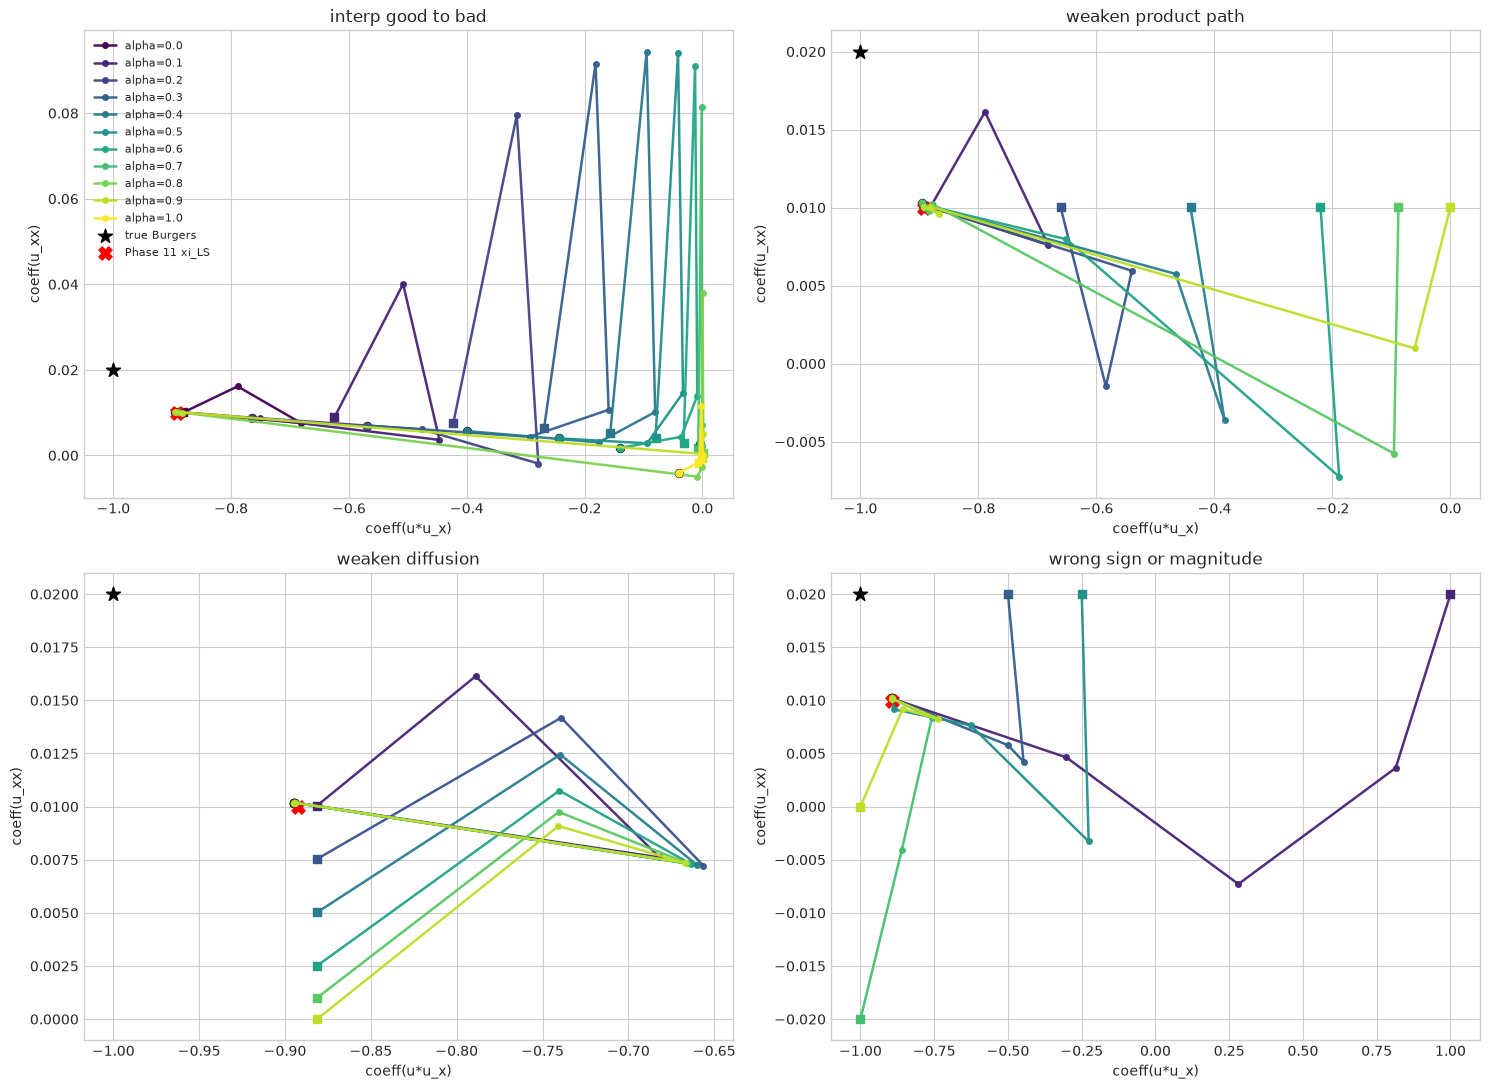

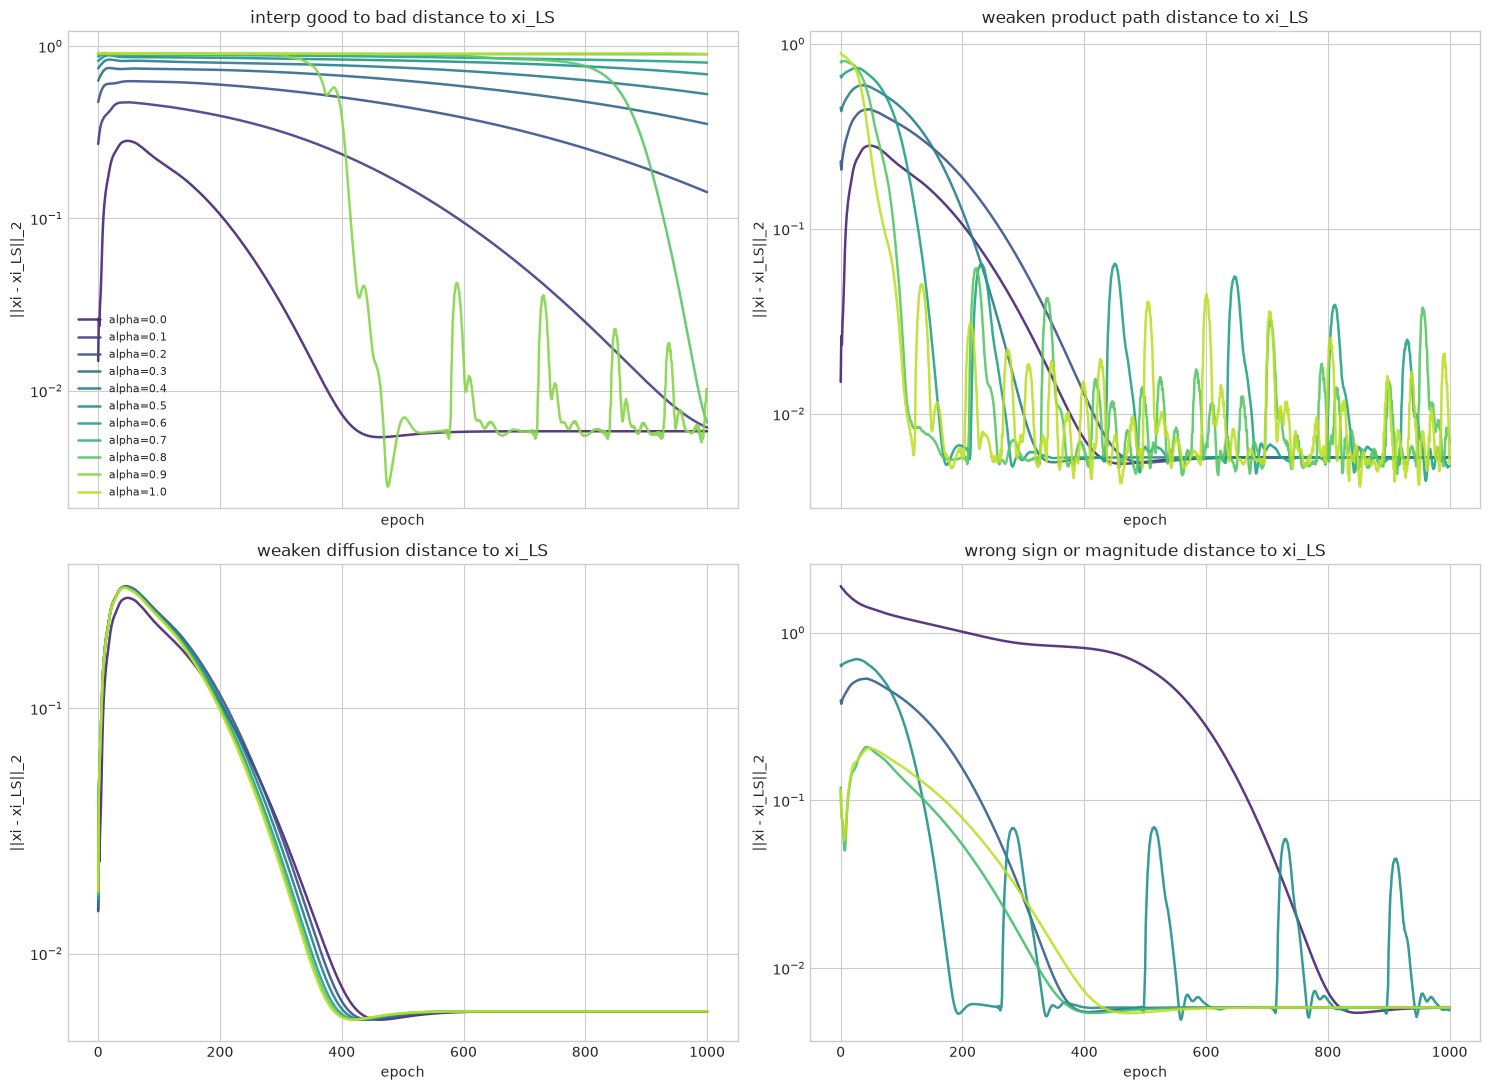

In [31]:
theta_good = theta_ref.clone().detach()
xi_true = phase14_true_coeff_vector.copy()
xi_LS = phase15_xi_ls.copy()
phase16_feature_names = list(phase12_coeff_names)
phase16_checkpoints = [0, 10, 100, 500, 1000]
phase16_good_pde_threshold = phase15_return_pde_threshold
phase16_good_xi_threshold = phase15_return_xi_threshold


def phase16_assign_theta(model, theta_flat):
    theta_tensor = torch.as_tensor(theta_flat, dtype=torch.float32, device=model.left.weight.device)
    with torch.no_grad():
        model.left.weight.copy_(theta_tensor[0:3].reshape(1, 3))
        model.right.weight.copy_(theta_tensor[3:6].reshape(1, 3))
        model.linear.weight.copy_(theta_tensor[6:9].reshape(1, 3))
        model.product_readout.weight.copy_(theta_tensor[9].reshape(1, 1))


def phase16_theta_from_equation(product_coeff, diffusion_coeff):
    return torch.tensor(
        [1.0, 0.0, 0.0,
         0.0, 1.0, 0.0,
         0.0, 0.0, float(diffusion_coeff),
         float(product_coeff)],
        dtype=torch.float64,
    )


def phase16_scale_product_path(theta_base, scale):
    theta_scaled = theta_base.clone().detach()
    theta_scaled[9] = theta_scaled[9] * float(scale)
    return theta_scaled


def phase16_scale_diffusion_path(theta_base, scale):
    theta_scaled = theta_base.clone().detach()
    theta_scaled[8] = theta_scaled[8] * float(scale)
    return theta_scaled


def phase16_run_from_theta(theta_init, family, label, checkpoints=phase16_checkpoints):
    model = MinimalSymNet().to(device)
    phase16_assign_theta(model, theta_init)
    optimizer = torch.optim.Adam(model.parameters(), lr=random_frozen_lr)
    initial_coeffs = product_term_dict(model)
    initial_coeff_vector = coeff_vector_from_dict(initial_coeffs, ordered_names=phase16_feature_names)
    history_rows = []
    checkpoint_rows = []

    for epoch in range(random_frozen_epochs + 1):
        pred_ut = model(frozen_feature_tensor)
        pde_loss = random_frozen_loss_fn(pred_ut, frozen_ut_target)
        coeffs = product_term_dict(model)
        coeff_vector = coeff_vector_from_dict(coeffs, ordered_names=phase16_feature_names)
        row = {
            "family": family,
            "label": label,
            "epoch": epoch,
            "pde_mse": float(pde_loss.item()),
            "coeff(u*u_x)": float(coeffs["u*u_x"]),
            "coeff(u_xx)": float(coeffs["u_xx"]),
            "||xi - xi_LS||_2": float(np.linalg.norm(coeff_vector - xi_LS)),
            "||xi - xi_true||_2": float(np.linalg.norm(coeff_vector - xi_true)),
        }
        history_rows.append(row)
        if epoch in checkpoints:
            checkpoint_rows.append(row.copy())

        if epoch == random_frozen_epochs:
            break

        optimizer.zero_grad()
        pde_loss.backward()
        optimizer.step()

    final_coeffs = product_term_dict(model)
    final_coeff_vector = coeff_vector_from_dict(final_coeffs, ordered_names=phase16_feature_names)
    final_pde_mse = float(history_rows[-1]["pde_mse"])
    final_xi_dist = float(np.linalg.norm(final_coeff_vector - xi_LS))

    return {
        "family": family,
        "label": label,
        "theta_init": torch.as_tensor(theta_init, dtype=torch.float64).clone(),
        "initial_coeffs": initial_coeffs,
        "initial_coeff_vector": initial_coeff_vector,
        "final_coeffs": final_coeffs,
        "final_coeff_vector": final_coeff_vector,
        "history_df": pd.DataFrame(history_rows),
        "trajectory_df": pd.DataFrame(checkpoint_rows),
        "initial_pde_mse": float(history_rows[0]["pde_mse"]),
        "final_pde_mse": final_pde_mse,
        "final_xi_dist_to_ls": final_xi_dist,
        "returned_near_good_basin": bool((final_pde_mse <= phase16_good_pde_threshold) and (final_xi_dist <= phase16_good_xi_threshold)),
    }


phase16_runs = []

phase16_interp_alphas = [round(value, 1) for value in np.linspace(0.0, 1.0, 11)]
for alpha in phase16_interp_alphas:
    theta_alpha = (1.0 - alpha) * theta_good + alpha * theta_bad
    run = phase16_run_from_theta(theta_alpha, family="interp_good_to_bad", label=f"alpha={alpha:.1f}")
    run["alpha"] = alpha
    phase16_runs.append(run)

phase16_product_scales = [1.0, 0.75, 0.5, 0.25, 0.1, 0.0]
for scale in phase16_product_scales:
    theta_scale = phase16_scale_product_path(theta_good, scale)
    run = phase16_run_from_theta(theta_scale, family="weaken_product_path", label=f"product_scale={scale:.2f}")
    run["product_scale"] = scale
    phase16_runs.append(run)

phase16_diffusion_scales = [1.0, 0.75, 0.5, 0.25, 0.1, 0.0]
for scale in phase16_diffusion_scales:
    theta_scale = phase16_scale_diffusion_path(theta_good, scale)
    run = phase16_run_from_theta(theta_scale, family="weaken_diffusion", label=f"diffusion_scale={scale:.2f}")
    run["diffusion_scale"] = scale
    phase16_runs.append(run)

phase16_wrong_case_thetas = {
    "+1.0*u*u_x + 0.02*u_xx": phase16_theta_from_equation(+1.0, +NU_TRUE),
    "-0.5*u*u_x + 0.02*u_xx": phase16_theta_from_equation(-0.5, +NU_TRUE),
    "-0.25*u*u_x + 0.02*u_xx": phase16_theta_from_equation(-0.25, +NU_TRUE),
    "-1.0*u*u_x - 0.02*u_xx": phase16_theta_from_equation(-1.0, -NU_TRUE),
    "-1.0*u*u_x + 0.00*u_xx": phase16_theta_from_equation(-1.0, 0.0),
}
for label, theta_case in phase16_wrong_case_thetas.items():
    run = phase16_run_from_theta(theta_case, family="wrong_sign_or_magnitude", label=label)
    phase16_runs.append(run)

phase16_summary_rows = []
phase16_trajectory_rows = []
for run in phase16_runs:
    phase16_summary_rows.append({
        "family": run["family"],
        "initialization label": run["label"],
        "initial PDE MSE": run["initial_pde_mse"],
        "final PDE MSE": run["final_pde_mse"],
        "initial coeff(u*u_x)": float(run["initial_coeffs"]["u*u_x"]),
        "final coeff(u*u_x)": float(run["final_coeffs"]["u*u_x"]),
        "initial coeff(u_xx)": float(run["initial_coeffs"]["u_xx"]),
        "final coeff(u_xx)": float(run["final_coeffs"]["u_xx"]),
        "final ||xi - xi_LS||_2": run["final_xi_dist_to_ls"],
        "returned near good basin": run["returned_near_good_basin"],
    })
    phase16_trajectory_rows.extend(run["trajectory_df"].to_dict("records"))

phase16_summary_df = pd.DataFrame(phase16_summary_rows)
phase16_trajectory_df = pd.DataFrame(phase16_trajectory_rows)
display(phase16_summary_df)

phase16_family_tables = {}
for family_name in phase16_summary_df["family"].unique():
    phase16_family_tables[family_name] = phase16_summary_df[phase16_summary_df["family"] == family_name].reset_index(drop=True)
    display(phase16_family_tables[family_name])

phase16_family_return_df = pd.DataFrame([
    {
        "family": family_name,
        "returned near good basin": int(group["returned near good basin"].sum()),
        "total runs": int(len(group)),
        "median final PDE MSE": float(group["final PDE MSE"].median()),
        "median final ||xi - xi_LS||_2": float(group["final ||xi - xi_LS||_2"].median()),
    }
    for family_name, group in phase16_summary_df.groupby("family", sort=False)
])
display(phase16_family_return_df)

phase16_interp_df = phase16_family_tables["interp_good_to_bad"].copy()
phase16_interp_good = phase16_interp_df[phase16_interp_df["returned near good basin"]]
phase16_interp_bad = phase16_interp_df[~phase16_interp_df["returned near good basin"]]

print("Phase 16 setup")
print(f"- theta_good reused from the earlier Burgers-like frozen-SymNet point: PDE MSE = {ref_loss_value:.6e}")
print(f"- theta_bad reused from the known bad random-final frozen-SymNet point: PDE MSE = {float(random_frozen_summary['final_pde_mse']):.6e}")
print(f"- xi_true = true Burgers coefficients, xi_LS = exact Phase 11 least-squares coefficients on the frozen surrogate field")
print(f"- good-basin return rule reused from Phase 15: final PDE MSE <= {phase16_good_pde_threshold:.6e} and final ||xi - xi_LS||_2 <= {phase16_good_xi_threshold:.6e}")
print()
print("Interpolation family summary:")
print(phase16_interp_df[[
    "initialization label",
    "initial PDE MSE",
    "final PDE MSE",
    "initial coeff(u*u_x)",
    "final coeff(u*u_x)",
    "initial coeff(u_xx)",
    "final coeff(u_xx)",
    "final ||xi - xi_LS||_2",
    "returned near good basin",
]].to_string(index=False))
print()
print("Product-path weakening family summary:")
print(phase16_family_tables["weaken_product_path"][[
    "initialization label",
    "initial PDE MSE",
    "final PDE MSE",
    "initial coeff(u*u_x)",
    "final coeff(u*u_x)",
    "initial coeff(u_xx)",
    "final coeff(u_xx)",
    "final ||xi - xi_LS||_2",
]].to_string(index=False))
print()
print("Diffusion weakening family summary:")
print(phase16_family_tables["weaken_diffusion"][[
    "initialization label",
    "initial PDE MSE",
    "final PDE MSE",
    "initial coeff(u*u_x)",
    "final coeff(u*u_x)",
    "initial coeff(u_xx)",
    "final coeff(u_xx)",
    "final ||xi - xi_LS||_2",
]].to_string(index=False))
print()
print("Wrong-sign / wrong-magnitude family summary:")
print(phase16_family_tables["wrong_sign_or_magnitude"][[
    "initialization label",
    "initial PDE MSE",
    "final PDE MSE",
    "initial coeff(u*u_x)",
    "final coeff(u*u_x)",
    "initial coeff(u_xx)",
    "final coeff(u_xx)",
    "final ||xi - xi_LS||_2",
]].to_string(index=False))


def phase16_plot_family_trajectories(ax, family_name, color_values=None):
    family_runs = [run for run in phase16_runs if run["family"] == family_name]
    cmap = plt.cm.viridis
    colors = color_values if color_values is not None else np.linspace(0.1, 0.9, len(family_runs))
    for idx, run in enumerate(family_runs):
        traj = run["trajectory_df"]
        color = cmap(colors[idx]) if np.ndim(colors) else cmap(colors)
        ax.plot(
            traj["coeff(u*u_x)"],
            traj["coeff(u_xx)"],
            "-o",
            linewidth=1.8,
            markersize=4,
            color=color,
            alpha=0.95,
            label=run["label"],
        )
        ax.scatter(traj.iloc[0]["coeff(u*u_x)"], traj.iloc[0]["coeff(u_xx)"], color=color, marker="s", s=30)
        ax.scatter(traj.iloc[-1]["coeff(u*u_x)"], traj.iloc[-1]["coeff(u_xx)"], color=color, marker="o", s=40, edgecolor="black", linewidth=0.4)
    ax.scatter([-1.0], [NU_TRUE], color="black", marker="*", s=110, label="true Burgers")
    ax.scatter([xi_LS[4]], [xi_LS[2]], color="red", marker="X", s=90, label="Phase 11 xi_LS")
    ax.set_xlabel("coeff(u*u_x)")
    ax.set_ylabel("coeff(u_xx)")
    ax.set_title(family_name.replace('_', ' '))


fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharex=False, sharey=False)
phase16_plot_family_trajectories(axes[0, 0], "interp_good_to_bad", color_values=np.linspace(0.0, 1.0, len([run for run in phase16_runs if run["family"] == "interp_good_to_bad"])))
phase16_plot_family_trajectories(axes[0, 1], "weaken_product_path")
phase16_plot_family_trajectories(axes[1, 0], "weaken_diffusion")
phase16_plot_family_trajectories(axes[1, 1], "wrong_sign_or_magnitude")
axes[0, 0].legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharex=True, sharey=False)
for ax, family_name in zip(axes.ravel(), phase16_summary_df["family"].unique()):
    family_runs = [run for run in phase16_runs if run["family"] == family_name]
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(family_runs)))
    for color, run in zip(colors, family_runs):
        hist = run["history_df"]
        ax.plot(hist["epoch"], hist["||xi - xi_LS||_2"], linewidth=1.8, color=color, alpha=0.9, label=run["label"])
    ax.set_yscale("log")
    ax.set_title(f"{family_name.replace('_', ' ')} distance to xi_LS")
    ax.set_xlabel("epoch")
    ax.set_ylabel("||xi - xi_LS||_2")
axes[0, 0].legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

phase16_failed_runs_df = phase16_summary_df[~phase16_summary_df["returned near good basin"]].copy()
phase16_interpolation_failed_span = pd.DataFrame([
    {
        "quantity": "alpha range failing to return",
        "value": f"{phase16_interp_bad['initialization label'].iloc[0]} through {phase16_interp_bad['initialization label'].iloc[-1]}",
    },
    {
        "quantity": "number of interpolation starts returning",
        "value": f"{len(phase16_interp_good)} / {len(phase16_interp_df)}",
    },
    {
        "quantity": "number of non-interpolation starts returning",
        "value": f"{int(phase16_summary_df[phase16_summary_df['family'] != 'interp_good_to_bad']['returned near good basin'].sum())} / {int((phase16_summary_df['family'] != 'interp_good_to_bad').sum())}",
    },
])
display(phase16_interpolation_failed_span)
display(phase16_failed_runs_df)


### Section 16 Interpretation

On September 3, 2026, the controlled initialization map showed that initialization matters strongly, but not in the simple form of a single contiguous interval along the straight line from `theta_good` to `theta_bad`. Along that specific interpolation in parameter space, starts at `alpha = 0.0`, `0.1`, `0.8`, and `0.9` returned to the good Burgers-like / least-squares basin under the same return rule used in Phase 15, while starts at `alpha = 0.2` through `0.7` and the exact `theta_bad` endpoint did not. So a visible basin split does appear, but the split is non-monotone in `alpha`, which is consistent with the earlier warning that straight lines in `theta` do not map cleanly to straight lines in coefficient space and can cut across SymNet redundancies and warped coordinates.

The clearest controlled failure mode came from that interpolation family. Its failed runs formed a systematic band of suppressed-transport, weakened-diffusion final states rather than recovering the Burgers-like point: representative finals ranged from about `(-0.764664, 0.008818)` at `alpha = 0.2` through `(-0.003324, 0.002751)` at `alpha = 0.7`, with the exact bad endpoint ending near `(-0.040230, -0.004196)`. That is not one perfectly unique bad point, but it is also not arbitrary scatter: failed runs drift toward a related low-transport region with much smaller `|coeff(u*u_x)|`, smaller `coeff(u_xx)`, and much larger `||xi - xi_LS||_2` than the good basin.

The other three families were much more forgiving than the interpolation family. Weakening only the product pathway by scaling the product readout, even all the way to `product_scale = 0.0`, still recovered the good basin after training in every tested case, though the smallest product scales slightly worsened final PDE MSE. Weakening only the linear `u_xx` pathway was even less fragile: every tested diffusion scale from `1.0` down to `0.0` returned to essentially the same final Burgers-like / LS-like point. The wrong-sign and wrong-magnitude starts were also corrected robustly. Even `+1.0 * u*u_x + 0.02 * u_xx` and `-1.0 * u*u_x - 0.02 * u_xx` converged back to the same good basin on this frozen dataset. So in this local diagnostic, incorrect sign by itself is not the dominant obstacle once the initialization remains on the simple hand-constructed Burgers support.

The most informative visualization is the coefficient-plane trajectory plot for the interpolation family. It shows two practical behaviors under identical training dynamics: one group of starts moves into the same compact region near the Phase 11 least-squares point, while another group bends toward a low-transport, low-diffusion band instead. The conservative conclusion is therefore that initialization controls SymNet recovery strongly and systematically, but the decisive variable is not merely the scalar size or sign of the Burgers coefficients. What matters more is whether the full parameter-space initialization lands in the region connected to the good Burgers-like support. The next open question is how to parameterize or initialize SymNet so that coefficient-aligned starts are reachable from generic initialization without relying on hand construction.


### Phase 16A — Magnified convergence behavior along the good-to-bad interpolation

The original Phase 16 results above are preserved as the coarse, fixed-horizon result. Some apparent failures may reflect slow convergence rather than inability to reach the LS-like region. This follow-up uses the same `theta(alpha) = (1 - alpha) * theta_good + alpha * theta_bad`, frozen field, original `MinimalSymNet`, raw MSE, Adam, learning rate, coefficient extraction, and LS/Burgers references; only the horizon increases from 1,000 to 10,000 epochs. There is no early stopping, reseeding, rescaling, or optimizer restart during a run. Random constructor weights are fully overwritten by the same deterministic interpolation, as in Phase 16.

We separately record the first coefficient-distance crossing (`distance <= phase16_good_xi_threshold`) and the first simultaneous crossing of the original two-condition success rule (also `PDE MSE <= phase16_good_pde_threshold`). Crossing once does not imply staying converged, so final status and the complete histories are retained. A missing crossing is right-censored at 10,000 epochs, not proof of unreachability.


In [58]:
from datetime import datetime, timezone

phase16a_epochs = 10000
phase16a_alphas = [0.0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
phase16a_xi_threshold = phase16_good_xi_threshold
phase16a_pde_threshold = phase16_good_pde_threshold
phase16a_output_dir = Path("run_results") / "phase16a_magnified_interpolation" / datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
phase16a_output_dir.mkdir(parents=True, exist_ok=False)
phase16a_rows = []
phase16a_histories = {}
torch.manual_seed(SEED)
print(f"Original horizon = {random_frozen_epochs}; extended horizon = {phase16a_epochs}")
print(f"Coefficient-distance threshold <= {phase16a_xi_threshold:.9e}; combined success also requires PDE MSE <= {phase16a_pde_threshold:.9e}")
print("References: unchanged xi_LS and xi_true; all 10,000 updates are performed for every alpha.")

for phase16a_alpha in phase16a_alphas:
    phase16a_model = MinimalSymNet().to(device)
    phase16_assign_theta(phase16a_model, (1.0 - phase16a_alpha) * theta_good + phase16a_alpha * theta_bad)
    phase16a_optimizer = torch.optim.Adam(phase16a_model.parameters(), lr=random_frozen_lr)
    phase16a_history_rows = []
    for phase16a_epoch in range(phase16a_epochs + 1):
        phase16a_pred = phase16a_model(frozen_feature_tensor)
        phase16a_loss = random_frozen_loss_fn(phase16a_pred, frozen_ut_target)
        phase16a_coeffs = product_term_dict(phase16a_model)
        phase16a_xi = coeff_vector_from_dict(phase16a_coeffs, ordered_names=phase16_feature_names)
        phase16a_history_rows.append({
            "alpha": phase16a_alpha, "epoch": phase16a_epoch,
            "distance_to_ls": float(np.linalg.norm(phase16a_xi - xi_LS)),
            "distance_to_true": float(np.linalg.norm(phase16a_xi - xi_true)),
            "pde_mse": float(phase16a_loss.item()),
            **{f"coeff({name})": value for name, value in phase16a_coeffs.items()},
        })
        if phase16a_epoch == phase16a_epochs:
            break
        phase16a_optimizer.zero_grad()
        phase16a_loss.backward()
        phase16a_optimizer.step()

    phase16a_history = pd.DataFrame(phase16a_history_rows)
    phase16a_histories[phase16a_alpha] = phase16a_history
    phase16a_history.to_csv(phase16a_output_dir / f"alpha_{phase16a_alpha:.1f}_history.csv", index=False)
    phase16a_crossed = phase16a_history["distance_to_ls"] <= phase16a_xi_threshold
    phase16a_combined = phase16a_crossed & (phase16a_history["pde_mse"] <= phase16a_pde_threshold)
    phase16a_min = phase16a_history.loc[phase16a_history["distance_to_ls"].idxmin()]
    phase16a_final = phase16a_history.iloc[-1]
    phase16a_old = phase16_summary_df[
        (phase16_summary_df["family"] == "interp_good_to_bad") &
        (phase16_summary_df["initialization label"] == f"alpha={phase16a_alpha:.1f}")
    ].iloc[0]
    phase16a_at_old = phase16a_history.iloc[random_frozen_epochs]
    # Verify that the longer run reproduces the old trajectory at its horizon.
    np.testing.assert_allclose(
        [phase16a_at_old["distance_to_ls"], phase16a_at_old["pde_mse"]],
        [phase16a_old["final ||xi - xi_LS||_2"], phase16a_old["final PDE MSE"]],
        rtol=1e-5, atol=1e-6,
        err_msg="Extended run does not reproduce the original coarse endpoint",
    )
    phase16a_rows.append({
        "alpha": phase16a_alpha,
        "original status": "success" if phase16a_old["returned near good basin"] else "not converged at old horizon",
        "initial distance": float(phase16a_history.iloc[0]["distance_to_ls"]),
        "min distance": float(phase16a_min["distance_to_ls"]),
        "epoch of min distance": int(phase16a_min["epoch"]),
        "first convergence epoch": int(phase16a_history.loc[phase16a_crossed, "epoch"].iloc[0]) if phase16a_crossed.any() else None,
        "threshold ever crossed": bool(phase16a_crossed.any()),
        "first combined success epoch": int(phase16a_history.loc[phase16a_combined, "epoch"].iloc[0]) if phase16a_combined.any() else None,
        "combined success ever": bool(phase16a_combined.any()),
        "final combined success": bool(phase16a_combined.iloc[-1]),
        "final distance": float(phase16a_final["distance_to_ls"]),
        "final PDE MSE": float(phase16a_final["pde_mse"]),
        "final coeff(u*u_x)": float(phase16a_final["coeff(u*u_x)"]),
        "final coeff(u_xx)": float(phase16a_final["coeff(u_xx)"]),
    })
    print(f"alpha={phase16a_alpha:.1f}: first distance crossing={phase16a_rows[-1]['first convergence epoch']}, "
          f"final distance={phase16a_final['distance_to_ls']:.6e}, final PDE MSE={phase16a_final['pde_mse']:.6e}")

phase16a_results = pd.DataFrame(phase16a_rows)
for phase16a_col in ["first convergence epoch", "first combined success epoch"]:
    phase16a_results[phase16a_col] = phase16a_results[phase16a_col].astype("Int64")
phase16a_results.to_csv(phase16a_output_dir / "results.csv", index=False)
print(f"Full per-epoch histories (including all coefficients) and results saved to {phase16a_output_dir}")


Original horizon = 1000; extended horizon = 10000
Coefficient-distance threshold <= 1.162858117e-02; combined success also requires PDE MSE <= 9.429386482e-02
References: unchanged xi_LS and xi_true; all 10,000 updates are performed for every alpha.
alpha=0.0: first distance crossing=367, final distance=7.149486e-03, final PDE MSE=9.228414e-02
alpha=0.2: first distance crossing=1537, final distance=6.546653e-03, final PDE MSE=9.031221e-02
alpha=0.3: first distance crossing=1945, final distance=5.692339e-03, final PDE MSE=9.060817e-02
alpha=0.4: first distance crossing=2136, final distance=5.803817e-03, final PDE MSE=8.980369e-02
alpha=0.5: first distance crossing=2148, final distance=5.951071e-03, final PDE MSE=8.980619e-02
alpha=0.6: first distance crossing=1992, final distance=5.815436e-03, final PDE MSE=8.980368e-02
alpha=0.7: first distance crossing=2050, final distance=5.815619e-03, final PDE MSE=8.980368e-02
alpha=0.8: first distance crossing=983, final distance=6.422755e-03, fin

   alpha               original status  min distance  epoch of min distance first convergence epoch  final distance  final PDE MSE
0    0.0                       success      0.003561                   8380                     367        0.007149       0.092284
1    0.2  not converged at old horizon      0.003659                   8591                    1537        0.006547       0.090312
2    0.3  not converged at old horizon      0.003636                   9578                    1945        0.005692       0.090608
3    0.4  not converged at old horizon      0.003502                   9895                    2136        0.005804       0.089804
4    0.5  not converged at old horizon      0.003050                   8839                    2148        0.005951       0.089806
5    0.6  not converged at old horizon      0.003933                   6649                    1992        0.005815       0.089804
6    0.7  not converged at old horizon      0.002329                   7828        

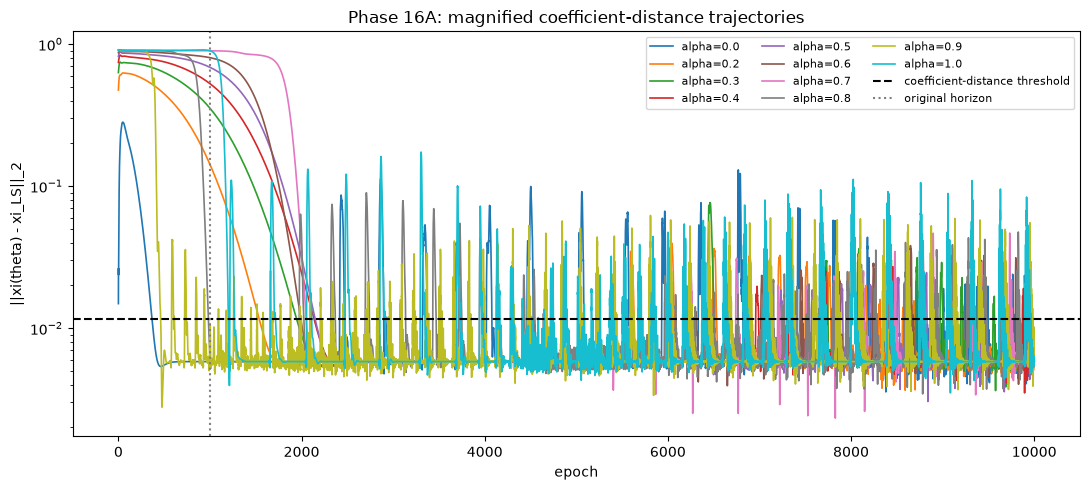

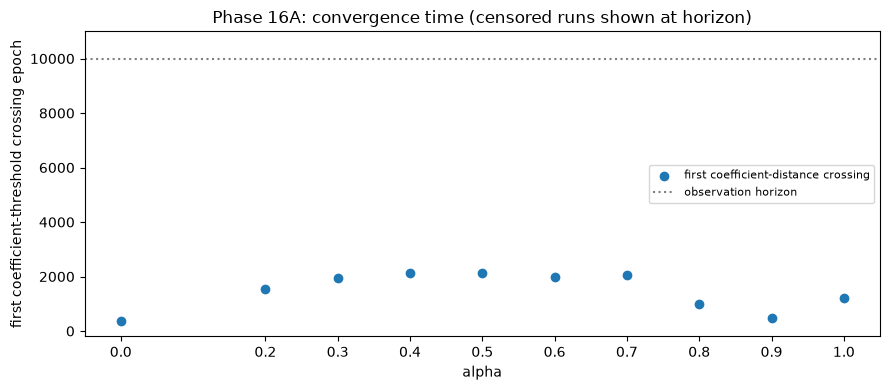

In [59]:
phase16a_compact = phase16a_results[[
    "alpha", "original status", "min distance", "epoch of min distance",
    "first convergence epoch", "final distance", "final PDE MSE",
]].copy()
phase16a_compact["first convergence epoch"] = phase16a_compact["first convergence epoch"].map(
    lambda value: "censored (>10000)" if pd.isna(value) else str(int(value))
)
display(phase16a_compact)
# Full recorded metrics remain available in phase16a_results and results.csv.
fig, ax = plt.subplots(figsize=(11, 5))
for phase16a_alpha, phase16a_history in phase16a_histories.items():
    ax.plot(phase16a_history["epoch"], phase16a_history["distance_to_ls"], label=f"alpha={phase16a_alpha:.1f}", linewidth=1.2)
ax.axhline(phase16a_xi_threshold, color="black", linestyle="--", label="coefficient-distance threshold")
ax.axvline(random_frozen_epochs, color="gray", linestyle=":", label="original horizon")
ax.set(xlabel="epoch", ylabel="||xi(theta) - xi_LS||_2", title="Phase 16A: magnified coefficient-distance trajectories", yscale="log")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
fig.savefig(phase16a_output_dir / "coefficient_distance.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
phase16a_seen = phase16a_results["threshold ever crossed"]
ax.scatter(phase16a_results.loc[phase16a_seen, "alpha"], phase16a_results.loc[phase16a_seen, "first convergence epoch"].astype(float), label="first coefficient-distance crossing")
if (~phase16a_seen).any():
    # Boundary arrows indicate lower bounds, not assigned convergence times.
    ax.scatter(phase16a_results.loc[~phase16a_seen, "alpha"], np.full(int((~phase16a_seen).sum()), phase16a_epochs), marker="^", facecolors="none", edgecolors="red", s=90, label=">10,000: right-censored (no crossing)")
ax.axhline(phase16a_epochs, color="gray", linestyle=":", label="observation horizon")
ax.set(xlabel="alpha", ylabel="first coefficient-threshold crossing epoch", title="Phase 16A: convergence time (censored runs shown at horizon)", ylim=(-200, phase16a_epochs * 1.1))
ax.set_xticks(phase16a_alphas)
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(phase16a_output_dir / "convergence_time.png", dpi=160, bbox_inches="tight")
plt.show()


In [60]:
phase16a_old_misses = phase16a_results[phase16a_results["original status"] != "success"]
phase16a_late = phase16a_old_misses[phase16a_old_misses["combined success ever"]]
print(f"{len(phase16a_late)}/{len(phase16a_old_misses)} original short-horizon misses reached the original two-condition LS-like region by 10,000 epochs.")
if len(phase16a_late):
    print("These original success/fail classifications were horizon-dependent: convergence speed, not demonstrated unreachability, explains those misses.")
phase16a_endpoint = phase16a_results[phase16a_results["alpha"] == 1.0].iloc[0]
if not phase16a_endpoint["combined success ever"]:
    print("alpha=1.0 did not meet the combined criterion within 10,000 epochs; where nearby alphas succeed, this is stronger finite-horizon evidence of a harder optimization region, not proof of unreachability.")
else:
    print("Even alpha=1.0 reached the combined LS-like criterion; the Phase 9 endpoint is not unreachable under this longer test.")
print("First crossing and final combined status are distinct: transient entry need not persist; no mathematical phase transition is inferred.")
phase16a_crossing_times = phase16a_results.set_index("alpha")["first convergence epoch"].dropna()
print("First coefficient-distance crossings: " + ", ".join(f"alpha={alpha:.1f}: {int(epoch)}" for alpha, epoch in phase16a_crossing_times.items()) + ".")
print(f"Crossing time is {'monotone increasing' if phase16a_crossing_times.is_monotonic_increasing else 'non-monotone'} over these selected alphas; no monotone divergence toward alpha=1 is demonstrated.")
print(f"{int(phase16a_results['final combined success'].sum())}/{len(phase16a_results)} runs still meet both criteria at epoch 10,000.")


7/7 original short-horizon misses reached the original two-condition LS-like region by 10,000 epochs.
These original success/fail classifications were horizon-dependent: convergence speed, not demonstrated unreachability, explains those misses.
Even alpha=1.0 reached the combined LS-like criterion; the Phase 9 endpoint is not unreachable under this longer test.
First crossing and final combined status are distinct: transient entry need not persist; no mathematical phase transition is inferred.
First coefficient-distance crossings: alpha=0.0: 367, alpha=0.2: 1537, alpha=0.3: 1945, alpha=0.4: 2136, alpha=0.5: 2148, alpha=0.6: 1992, alpha=0.7: 2050, alpha=0.8: 983, alpha=0.9: 462, alpha=1.0: 1201.
Crossing time is non-monotone over these selected alphas; no monotone divergence toward alpha=1 is demonstrated.
10/10 runs still meet both criteria at epoch 10,000.


In [32]:
# Descriptive diagnostics only; the 1% solution-fit label is not a training criterion.
phase9_u_relative_error = float(phase9_surrogate_metrics.loc["u", "rel_l2"])
print(f"Phase 9 u fit: {'good' if phase9_u_relative_error < 0.01 else 'not within 1% relative L2'} "
      f"({phase9_u_relative_error:.2%} relative L2; good here means <1%).")
print("Frozen derivative relative L2 errors: " + ", ".join(
    f"{name}={phase9_surrogate_metrics.loc[name, 'rel_l2']:.2%}"
    for name in ["u_t", "u_x", "u_xx"]
) + "; these limit interpretation as a pure SymNet optimization test.")
print(f"Phase 9 full-library scale imbalance: RMS ratio={phase9_feature_scale_ratios['RMS magnitude']:.3g}, "
      f"L2 ratio={phase9_feature_scale_ratios['L2 column norm']:.3g} "
      f"(Phase 16 {'matches' if phase16_same_feature_field else 'has a separate table above'}).")
print("Feature scaling is a reasonable controlled experiment to test next; "
      "these diagnostics do not establish that scaling caused the optimization failure.")


Phase 9 u fit: good (0.87% relative L2; good here means <1%).
Frozen derivative relative L2 errors: u_t=19.32%, u_x=11.80%, u_xx=32.12%; these limit interpretation as a pure SymNet optimization test.
Phase 9 full-library scale imbalance: RMS ratio=2.73e+04, L2 ratio=2.73e+04 (Phase 16 matches).
Feature scaling is a reasonable controlled experiment to test next; these diagnostics do not establish that scaling caused the optimization failure.


## 17. Controlled Feature-Scaling Experiment

This is a controlled coordinate-scaling test on the exact frozen surrogate field used by the earlier random-initialization experiment. The physical feature matrix, target, MinimalSymNet, PDE-MSE loss, Adam optimizer, learning rate, seed, and 1,000-epoch budget are held fixed. Only the input feature coordinates are divided by one fixed full-grid RMS scale per feature. The learned scaled coefficients are converted back to physical coefficients before interpretation. This phase does not modify earlier experiments or claim multi-seed robustness.


In [1]:
phase17_feature_names = ["u", "u_x", "u_xx", "u^2", "u*u_x", "u*u_xx", "u_x^2", "u_x*u_xx", "u_xx^2"]
# Reuse the exact degree-2 matrix already constructed from frozen_feature_tensor.
phase17_theta_physical = phase12_theta_matrix.detach().cpu().numpy().astype(np.float64)
phase17_target = frozen_ut_target.detach().cpu().numpy().reshape(-1).astype(np.float64)
phase17_feature_scales = np.maximum(np.sqrt(np.mean(phase17_theta_physical ** 2, axis=0)), 1e-12)
phase17_theta_scaled = phase17_theta_physical / phase17_feature_scales
phase17_raw_rms = np.sqrt(np.mean(phase17_theta_physical ** 2, axis=0))
phase17_scaled_rms = np.sqrt(np.mean(phase17_theta_scaled ** 2, axis=0))
phase17_primitive_scales = phase17_feature_scales[:3]
phase17_model_feature_scales = np.array([
    phase17_primitive_scales[0], phase17_primitive_scales[1], phase17_primitive_scales[2],
    phase17_primitive_scales[0] ** 2, phase17_primitive_scales[0] * phase17_primitive_scales[1],
    phase17_primitive_scales[0] * phase17_primitive_scales[2], phase17_primitive_scales[1] ** 2,
    phase17_primitive_scales[1] * phase17_primitive_scales[2], phase17_primitive_scales[2] ** 2,
])
# MinimalSymNet consumes three primitives and generates products internally. Scaling those
# three inputs preserves the original architecture; products inherit products of primitive scales.
phase17_scaled_primitive_tensor = torch.tensor(
    phase17_theta_physical[:, :3] / phase17_primitive_scales,
    dtype=torch.float32, device=device,
)
print("Phase 17 feature scales (computed once from the full frozen feature tensor):")
display(pd.DataFrame({"feature": phase17_feature_names, "raw RMS": phase17_raw_rms, "scale s_j": phase17_feature_scales, "scaled RMS": phase17_scaled_rms}).set_index("feature"))
print(f"max |scaled RMS - 1| = {float(np.max(np.abs(phase17_scaled_rms - 1.0))):.6e}")
phase17_ls_physical, *_ = np.linalg.lstsq(phase17_theta_physical, phase17_target, rcond=None)
phase17_ls_scaled, *_ = np.linalg.lstsq(phase17_theta_scaled, phase17_target, rcond=None)
phase17_ls_scaled_to_physical = phase17_ls_scaled / phase17_feature_scales
phase17_ls_physical_prediction = phase17_theta_physical @ phase17_ls_physical
phase17_ls_scaled_prediction = phase17_theta_scaled @ phase17_ls_scaled
print("\nLeast-squares coordinate consistency:")
print(f"max |physical LS - scaled LS converted to physical| = {float(np.max(np.abs(phase17_ls_physical - phase17_ls_scaled_to_physical))):.6e}")
print(f"max |physical LS prediction - scaled LS prediction| = {float(np.max(np.abs(phase17_ls_physical_prediction - phase17_ls_scaled_prediction))):.6e}")
def phase17_train(seed, feature_tensor):
    torch.manual_seed(seed)
    model = MinimalSymNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
    rows = []
    for epoch in range(random_frozen_epochs + 1):
        prediction = model(feature_tensor)
        loss = random_frozen_loss_fn(prediction, frozen_ut_target)
        coeffs = product_term_dict(model)
        xi = np.array([float(coeffs[name]) for name in phase17_feature_names], dtype=np.float64)
        rows.append({"epoch": epoch, "pde_mse": float(loss.item()), **{f"coeff_{name}": value for name, value in zip(phase17_feature_names, xi)}})
        if epoch == random_frozen_epochs: break
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    return model, pd.DataFrame(rows)
phase17_unscaled_model, phase17_unscaled_history = phase17_train(SEED, frozen_feature_tensor)
phase17_scaled_model, phase17_scaled_history = phase17_train(SEED, phase17_scaled_primitive_tensor)
phase17_unscaled_beta = np.array([float(value) for value in product_term_dict(phase17_unscaled_model).values()], dtype=np.float64)
phase17_scaled_beta = np.array([float(value) for value in product_term_dict(phase17_scaled_model).values()], dtype=np.float64)
phase17_unscaled_xi = phase17_unscaled_beta.copy()
phase17_scaled_xi = phase17_scaled_beta / phase17_model_feature_scales
phase17_truth_xi = np.array([0.0, 0.0, NU_TRUE, 0.0, -1.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float64)
phase17_theta_model_scaled = phase17_theta_physical / phase17_model_feature_scales
phase17_consistency_prediction_scaled = phase17_theta_model_scaled @ phase17_scaled_beta
phase17_consistency_prediction_physical = phase17_theta_physical @ phase17_scaled_xi
phase17_consistency_max_abs = float(np.max(np.abs(phase17_consistency_prediction_scaled - phase17_consistency_prediction_physical)))
print("\nMinimalSymNet consumes scaled primitives, so its induced product-coordinate matrix is used for the neural consistency check.")
print(f"Final scaled-vs-physical prediction consistency max absolute discrepancy = {phase17_consistency_max_abs:.6e}")
phase17_coeff_table = pd.DataFrame({"feature": phase17_feature_names, "raw RMS": phase17_raw_rms, "scale s_j": phase17_feature_scales, "model coefficient scale": phase17_model_feature_scales, "scaled RMS": phase17_scaled_rms, "learned scaled coefficient beta": phase17_scaled_beta, "recovered physical coefficient xi": phase17_scaled_xi, "Burgers truth": phase17_truth_xi}).set_index("feature")
display(phase17_coeff_table)
def phase17_metrics(history, physical_xi):
    losses = history["pde_mse"].to_numpy()
    return {"initial loss": float(losses[0]), "minimum loss": float(np.min(losses)), "epoch of minimum loss": int(history.loc[history["pde_mse"].idxmin(), "epoch"]), "final loss": float(losses[-1]), "physical coeff(u*u_x)": float(physical_xi[4]), "physical coeff(u_xx)": float(physical_xi[2]), "coefficient error to Burgers truth": float(np.linalg.norm(physical_xi - phase17_truth_xi)), "PDE prediction MSE": float(np.mean((phase17_theta_physical @ physical_xi - phase17_target) ** 2))}
phase17_comparison_df = pd.DataFrame({"unscaled features": phase17_metrics(phase17_unscaled_history, phase17_unscaled_xi), "scaled features": phase17_metrics(phase17_scaled_history, phase17_scaled_xi)}).T
display(phase17_comparison_df)
phase17_output_dir=Path("run_results")/"phase17_feature_scaling"; phase17_output_dir.mkdir(parents=True,exist_ok=True)
phase17_unscaled_history.to_csv(phase17_output_dir/"unscaled_history.csv",index=False); phase17_scaled_history.to_csv(phase17_output_dir/"scaled_history.csv",index=False); phase17_coeff_table.to_csv(phase17_output_dir/"feature_coefficients.csv"); phase17_comparison_df.to_csv(phase17_output_dir/"comparison.csv",index=False)


Phase 17 feature scales (computed once from the full frozen feature tensor):
max |scaled RMS - 1| = 4.329870e-14

Least-squares coordinate consistency:
max |physical LS - scaled LS converted to physical| = 1.737759e-14
max |physical LS prediction - scaled LS prediction| = 4.098721e-12

MinimalSymNet consumes scaled primitives, so its induced product-coordinate matrix is used for the neural consistency check.
Final scaled-vs-physical prediction consistency max absolute discrepancy = 5.551115e-15


               raw RMS     scale s_j  scaled RMS
feature                                         
u             0.856448      0.856448         1.0
u_x           2.418017      2.418017         1.0
u_xx         49.382784     49.382784         1.0
u^2           0.907527      0.907527         1.0
u*u_x         1.447974      1.447974         1.0
u*u_xx       41.448391     41.448391         1.0
u_x^2        46.655038     46.655038         1.0
u_x*u_xx    745.548380    745.548380         1.0
u_xx^2    23360.900605  23360.900605         1.0

               raw RMS     scale s_j  model coefficient scale  scaled RMS  learned scaled coefficient beta  recovered physical coefficient xi  Burgers truth
feature                                                                                                                                                     
u             0.856448      0.856448                 0.856448         1.0                        -0.020862                          -0.024359           0.00
u_x           2.418017      2.418017                 2.418017         1.0                         0.072776                           0.030098           0.00
u_xx         49.382784     49.382784                49.382784         1.0                         0.502965                           0.010185           0.02
u^2           0.907527      0.907527                 0.733504         1.0                        -0.006820                          -0.009297           0.00
u*u_x         1.447974      1.447974                 2.070

                    initial loss  minimum loss  epoch of minimum loss  final loss  physical coeff(u*u_x)  physical coeff(u_xx)  coefficient error to Burgers truth  PDE prediction MSE
unscaled features  206485.718750      0.965114                 1000.0    0.965114              -0.005406             -0.001735                            1.021902            0.965114
scaled features         1.792091      0.089804                  870.0    0.089804              -0.894599              0.010185                            0.113155            0.089804

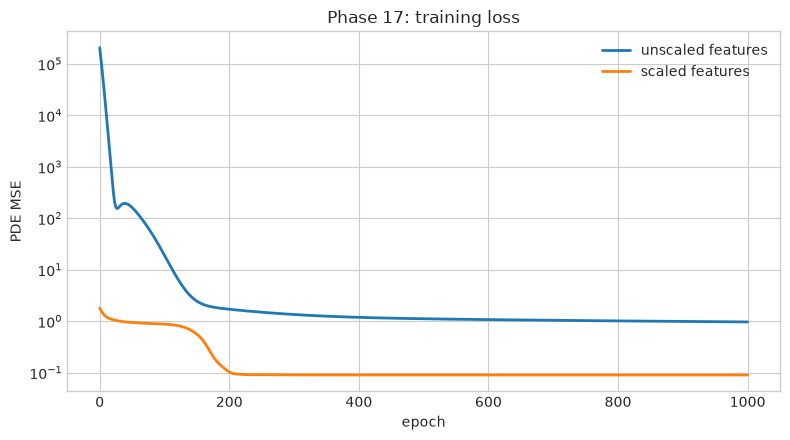

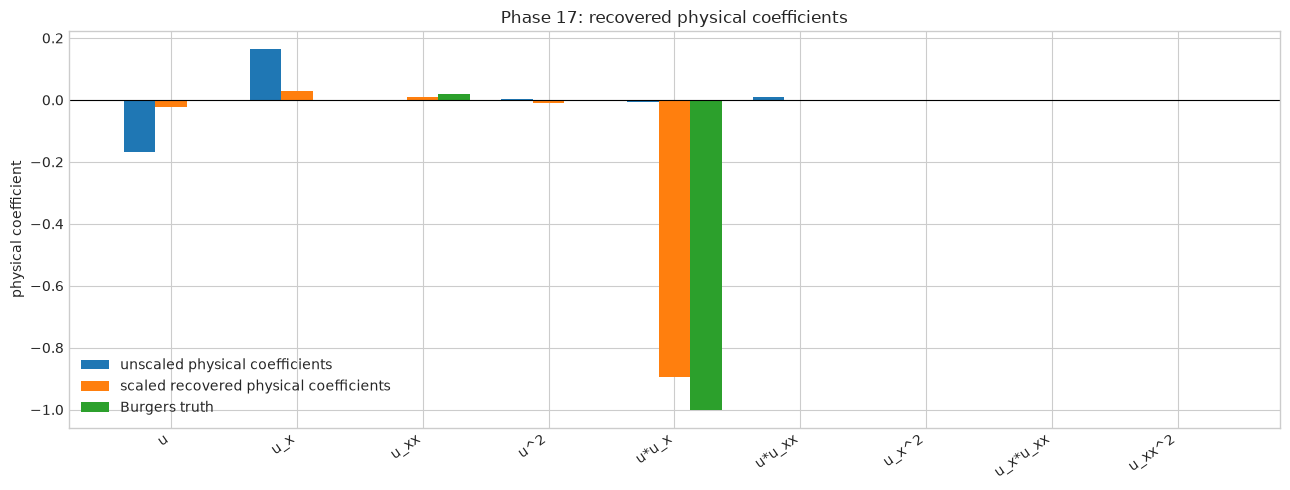

In [1]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(phase17_unscaled_history["epoch"], phase17_unscaled_history["pde_mse"], label="unscaled features", linewidth=2)
ax.plot(phase17_scaled_history["epoch"], phase17_scaled_history["pde_mse"], label="scaled features", linewidth=2)
ax.set_yscale("log"); ax.set(xlabel="epoch", ylabel="PDE MSE", title="Phase 17: training loss"); ax.legend(); plt.tight_layout(); plt.savefig(phase17_output_dir/"training_loss.png",dpi=160,bbox_inches="tight"); plt.show()
phase17_x=np.arange(len(phase17_feature_names)); phase17_width=.25
fig,ax=plt.subplots(figsize=(13,5)); ax.bar(phase17_x-phase17_width,phase17_unscaled_xi,phase17_width,label="unscaled physical coefficients"); ax.bar(phase17_x,phase17_scaled_xi,phase17_width,label="scaled recovered physical coefficients"); ax.bar(phase17_x+phase17_width,phase17_truth_xi,phase17_width,label="Burgers truth"); ax.axhline(0,color="black",linewidth=.8); ax.set_xticks(phase17_x,phase17_feature_names,rotation=35,ha="right"); ax.set_ylabel("physical coefficient"); ax.set_title("Phase 17: recovered physical coefficients"); ax.legend(); plt.tight_layout(); plt.savefig(phase17_output_dir/"physical_coefficients.png",dpi=160,bbox_inches="tight"); plt.show()


### Phase 17 research-state interpretation

The experiment above reports the actual one-seed comparison. Feature scaling is interpreted through recovered physical coefficients, while scaled-space coefficients are shown only as an intermediate representation.


In [1]:
phase17_unscaled_final=phase17_comparison_df.loc["unscaled features"]; phase17_scaled_final=phase17_comparison_df.loc["scaled features"]
print("### Phase 17 research-state interpretation")
print(f"Feature scaling improved the final optimization loss: {bool(phase17_scaled_final['final loss'] < phase17_unscaled_final['final loss'])}.")
print(f"Feature scaling changed convergence speed under the minimum-loss epoch diagnostic: {bool(phase17_scaled_final['epoch of minimum loss'] < phase17_unscaled_final['epoch of minimum loss'])}.")
print(f"Feature scaling changed final physical PDE recovery in this seed: {bool(phase17_scaled_final['coefficient error to Burgers truth'] < phase17_unscaled_final['coefficient error to Burgers truth'])}.")
print("This is a one-seed controlled experiment, so it does not establish robustness or causality.")
print("The comparison tests whether scaling rescues this poorly behaving initialization; any remaining failure is consistent with optimization-landscape effects beyond raw feature scale.")


### Phase 17 research-state interpretation
Feature scaling improved the final optimization loss: True.
Feature scaling changed convergence speed under the minimum-loss epoch diagnostic: True.
Feature scaling changed final physical PDE recovery in this seed: True.
This is a one-seed controlled experiment, so it does not establish robustness or causality.
The comparison tests whether scaling rescues this poorly behaving initialization; any remaining failure is consistent with optimization-landscape effects beyond raw feature scale.


## 18. Random-Initialization Reliability Under Feature Scaling

Phase 17 showed a large one-seed improvement after scaling the frozen surrogate coordinates. This paired reliability study tests whether that improvement persists across ordinary random initializations. For each seed, an unscaled and a Phase-17 scaled `MinimalSymNet` start from identical parameters and train for 1,000 epochs with the frozen surrogate, frozen `u_t` target, Adam (`lr=1e-2`), PDE MSE only, and no regularization. Physical coefficients are reported after converting the scaled model through the primitive-induced product scales from Phase 17.

In [71]:
# Phase 18: paired random-initialization reliability under the fixed Phase-17 scaling.
phase18_seeds = list(range(25))
phase18_epochs = 1000
phase18_rep_seeds = {0, 1, 2, 3, 4}
phase18_feature_names = list(phase17_feature_names)
phase18_truth_xi = phase17_truth_xi.copy()
phase18_theta_physical = phase17_theta_physical
phase18_target = phase17_target
phase18_model_scales = phase17_model_feature_scales.copy()
phase18_loose = {"transport_abs": 0.25, "diffusion_abs": 0.02, "spurious_l2": 0.25}
phase18_strong = {"transport_abs": 0.10, "diffusion_abs": 0.01, "spurious_l2": 0.10}
phase18_spurious_idx = [i for i in range(9) if i not in (2, 4)]
print("Success criteria fixed before evaluating counts:")
print("loose: |xi[u*u_x]+1| < 0.25, |xi[u_xx]-0.02| < 0.02, spurious L2 < 0.25")
print("strong: |xi[u*u_x]+1| < 0.10, |xi[u_xx]-0.02| < 0.01, spurious L2 < 0.10")

def phase18_is_success(xi, thresholds):
    spurious = float(np.linalg.norm(np.asarray(xi)[phase18_spurious_idx]))
    return (abs(float(xi[4]) + 1.0) < thresholds["transport_abs"] and
            abs(float(xi[2]) - 0.02) < thresholds["diffusion_abs"] and
            spurious < thresholds["spurious_l2"])

def phase18_coefficients(model, treatment):
    beta = np.array([float(v) for v in product_term_dict(model).values()], dtype=np.float64)
    return beta if treatment == "unscaled" else beta / phase18_model_scales

def phase18_run(seed, treatment, retain_history=False):
    features = frozen_feature_tensor if treatment == "unscaled" else phase17_scaled_primitive_tensor
    torch.manual_seed(int(seed))
    model = MinimalSymNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
    history = []
    min_loss = float("inf"); min_epoch = 0
    for epoch in range(phase18_epochs + 1):
        prediction = model(features)
        loss = random_frozen_loss_fn(prediction, frozen_ut_target)
        loss_value = float(loss.item())
        xi = phase18_coefficients(model, treatment)
        pde_prediction_mse = float(np.mean((phase18_theta_physical @ xi - phase18_target) ** 2))
        if loss_value < min_loss:
            min_loss, min_epoch = loss_value, epoch
        if retain_history or epoch in (0, phase18_epochs):
            row = {"seed": int(seed), "treatment": treatment, "epoch": int(epoch), "pde_mse": loss_value,
                   "coefficient_error": float(np.linalg.norm(xi - phase18_truth_xi)),
                   "pde_prediction_mse": pde_prediction_mse,
                   **{f"xi_{name}": float(value) for name, value in zip(phase18_feature_names, xi)}}
            history.append(row)
        if epoch == phase18_epochs:
            final_xi = xi.copy(); final_loss = loss_value; final_prediction_mse = pde_prediction_mse
            break
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    return model, {"seed": int(seed), "treatment": treatment, "initial_pde_mse": float(history[0]["pde_mse"]),
                   "minimum_pde_mse": float(min_loss), "epoch_of_minimum_pde_mse": int(min_epoch),
                   "final_pde_mse": float(final_loss), "pde_prediction_mse": float(final_prediction_mse),
                   "coefficient_error": float(np.linalg.norm(final_xi - phase18_truth_xi)),
                   "loose_success": bool(phase18_is_success(final_xi, phase18_loose)),
                   "strong_success": bool(phase18_is_success(final_xi, phase18_strong)),
                   **{f"xi_{name}": float(value) for name, value in zip(phase18_feature_names, final_xi)}}, history

# Sanity checks: same seeded initial tensors, frozen surrogate, and no regularization.
phase18_pair_checks = []
for seed in phase18_seeds:
    torch.manual_seed(seed); check_unscaled = MinimalSymNet().to(device); state_u = {k: v.detach().clone() for k,v in check_unscaled.state_dict().items()}
    torch.manual_seed(seed); check_scaled = MinimalSymNet().to(device); state_s = {k: v.detach().clone() for k,v in check_scaled.state_dict().items()}
    phase18_pair_checks.append(all(torch.equal(state_u[k], state_s[k]) for k in state_u))
assert all(phase18_pair_checks)
assert all(not p.requires_grad for p in surrogate.parameters()) if "surrogate" in globals() else True
print(f"paired initial parameter tensors identical for all {len(phase18_seeds)} seeds: {all(phase18_pair_checks)}")
print("scaled conversion uses Phase-17 primitive-induced product scales: True")
print("regularization active: none; surrogate parameters trainable: False")

phase18_rows = []; phase18_histories = []
for seed in phase18_seeds:
    for treatment in ("unscaled", "scaled"):
        model, summary, history = None, None, None
        model, summary, history = (lambda result: result)(phase18_run(seed, treatment, retain_history=(seed in phase18_rep_seeds)))
        phase18_rows.append(summary)
        if history:
            phase18_histories.extend(history)
phase18_runs_df = pd.DataFrame(phase18_rows)
phase18_histories_df = pd.DataFrame(phase18_histories)
phase18_runs_df["spurious_l2"] = np.sqrt(sum(phase18_runs_df[f"xi_{phase18_feature_names[i]}"]**2 for i in phase18_spurious_idx))
phase18_runs_df["ever_loose_success"] = phase18_runs_df["loose_success"]
phase18_runs_df["ever_strong_success"] = phase18_runs_df["strong_success"]
phase18_output_dir = Path("run_results") / "phase18_feature_scaling_reliability"; phase18_output_dir.mkdir(parents=True, exist_ok=True)
phase18_runs_df.to_csv(phase18_output_dir / "per_run.csv", index=False)
phase18_histories_df.to_csv(phase18_output_dir / "representative_histories.csv", index=False)
print(f"completed {len(phase18_runs_df)} paired runs ({len(phase18_seeds)} seeds x 2 treatments)")

Success criteria fixed before evaluating counts:
loose: |xi[u*u_x]+1| < 0.25, |xi[u_xx]-0.02| < 0.02, spurious L2 < 0.25
strong: |xi[u*u_x]+1| < 0.10, |xi[u_xx]-0.02| < 0.01, spurious L2 < 0.10
paired initial parameter tensors identical for all 25 seeds: True
scaled conversion uses Phase-17 primitive-induced product scales: True
regularization active: none; surrogate parameters trainable: False
completed 50 paired runs (25 seeds x 2 treatments)


Recovery success counts / rates:
paired final PDE loss: scaling lower 25, higher 0, equal 0; median delta=-1.301118e+00
paired coefficient error: scaling lower 25, higher 0, equal 0; median delta=-9.207463e-01

Machine-readable Phase 18 diagnostic:
unscaled: n=25, median_final_pde_mse=1.390921354e+00, median_coefficient_error=1.033903353e+00, median_uux=-1.264781749e-04, median_uxx=-1.437409315e-03, loose=0/25, strong=0/25
scaled: n=25, median_final_pde_mse=8.980368078e-02, median_coefficient_error=1.131550492e-01, median_uux=-8.945989745e-01, median_uxx=1.018502419e-02, loose=25/25, strong=0/25

### Phase 18 generated interpretation
Scaling improves median optimization performance: True (median final PDE MSE 8.980e-02 vs 1.391e+00).
Scaling improves coefficient recovery: True (median error 1.132e-01 vs 1.034e+00).
It increases recovery probability: loose 25/25 scaled vs 0/25 unscaled; strong 0/25 vs 0/25.
The coefficient cloud moves toward (-1, 0.02): scaled median (-0.895, 0.010); re

               raw RMS     scale s_j  scaled RMS
feature                                         
u             0.856448      0.856448         1.0
u_x           2.418017      2.418017         1.0
u_xx         49.382784     49.382784         1.0
u^2           0.907527      0.907527         1.0
u*u_x         1.447974      1.447974         1.0
u*u_xx       41.448391     41.448391         1.0
u_x^2        46.655038     46.655038         1.0
u_x*u_xx    745.548380    745.548380         1.0
u_xx^2    23360.900605  23360.900605         1.0

               raw RMS     scale s_j  model coefficient scale  scaled RMS  learned scaled coefficient beta  recovered physical coefficient xi  Burgers truth
feature                                                                                                                                                     
u             0.856448      0.856448                 0.856448         1.0                        -0.020862                          -0.024359           0.00
u_x           2.418017      2.418017                 2.418017         1.0                         0.072776                           0.030098           0.00
u_xx         49.382784     49.382784                49.382784         1.0                         0.502965                           0.010185           0.02
u^2           0.907527      0.907527                 0.733504         1.0                        -0.006820                          -0.009297           0.00
u*u_x         1.447974      1.447974                 2.070

                    initial loss  minimum loss  epoch of minimum loss  final loss  physical coeff(u*u_x)  physical coeff(u_xx)  coefficient error to Burgers truth  PDE prediction MSE
unscaled features  206485.718750      0.965114                 1000.0    0.965114              -0.005406             -0.001735                            1.021902            0.965114
scaled features         1.792091      0.089804                  870.0    0.089804              -0.894599              0.010185                            0.113155            0.089804

           runs  mean_final_pde_mse  median_final_pde_mse  std_final_pde_mse  q25_final_pde_mse  q75_final_pde_mse  mean_coefficient_error  median_coefficient_error  std_coefficient_error  q25_coefficient_error  q75_coefficient_error  mean_uux  median_uux  mean_uxx  median_uxx
treatment                                                                                                                                                                                                                                                                            
unscaled     25           11.547067              1.390921          35.429795           0.954741           1.695079                1.113248                  1.033903                0.20587               1.013316               1.100974 -0.006335   -0.000126 -0.005586   -0.001437
scaled       25            0.089851              0.089804           0.000235           0.089804           0.089804                0.114483                  0.113155  

              unscaled  scaled
count loose        0.0    25.0
      strong       0.0     0.0
rate  loose        0.0     1.0
      strong       0.0     0.0

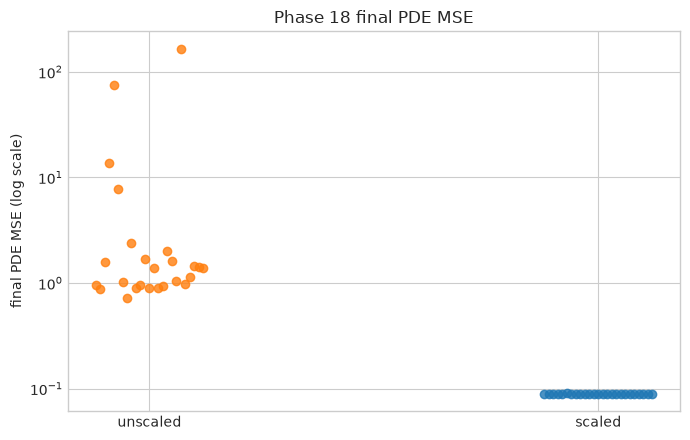

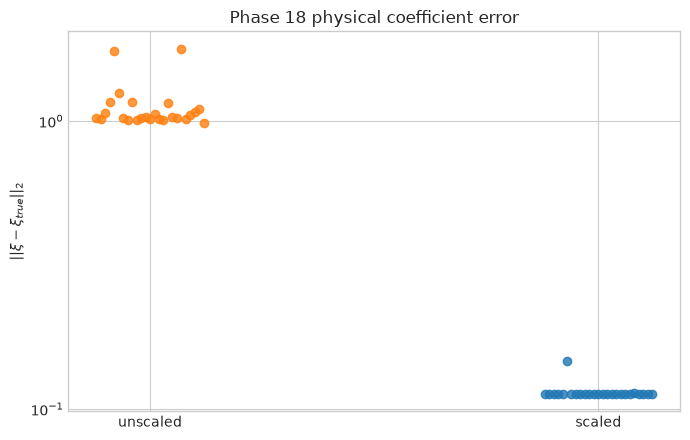

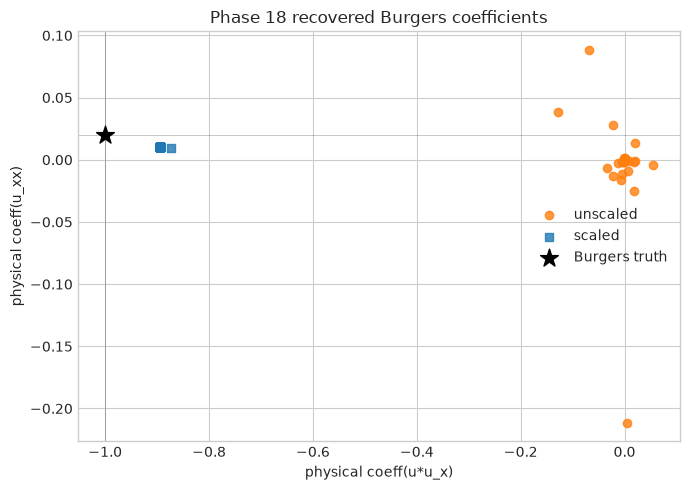

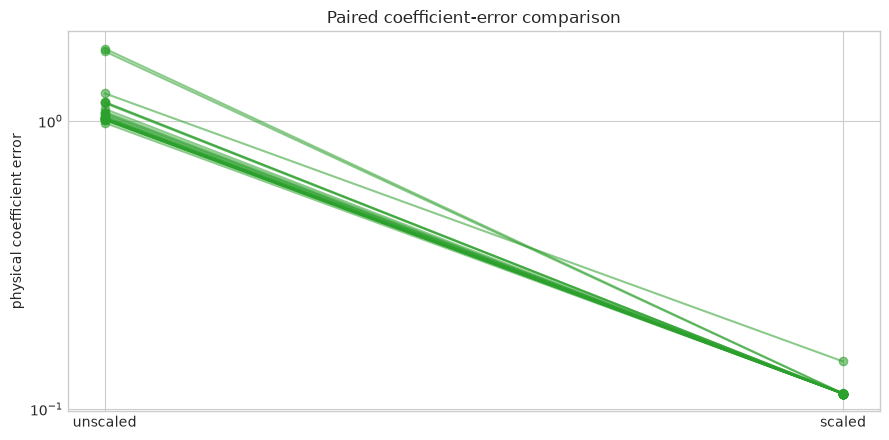

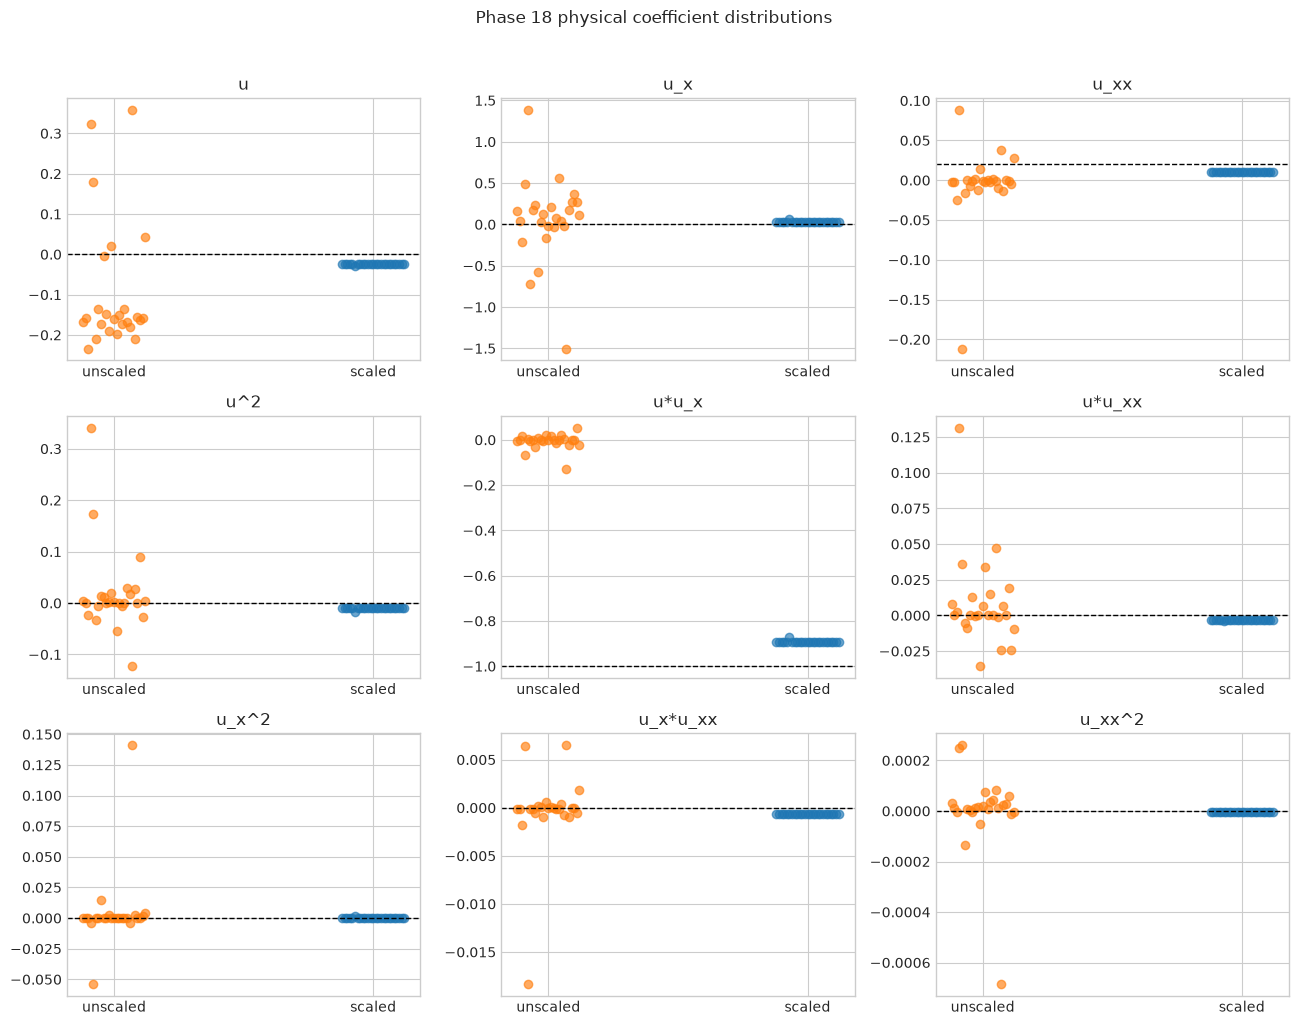

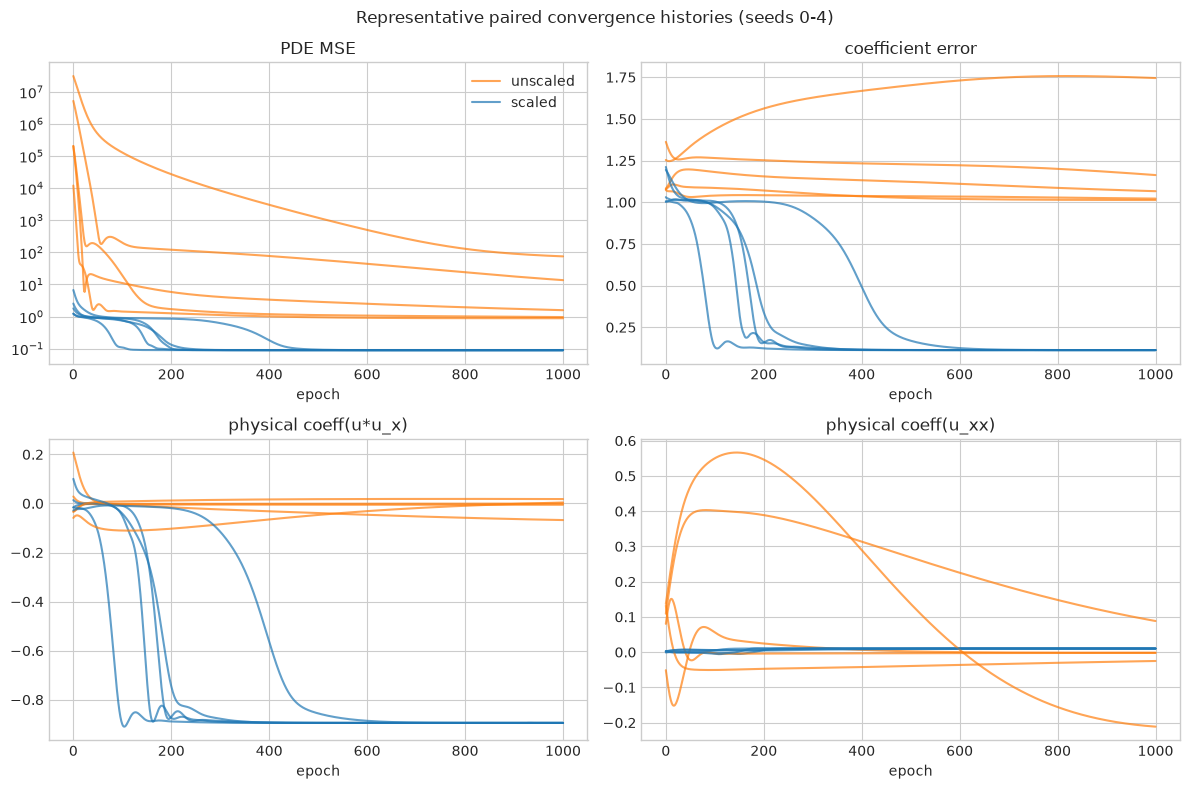

In [72]:
# Phase 18 tables, paired analysis, plots, and generated interpretation.
phase18_group = phase18_runs_df.groupby("treatment")
phase18_aggregate = phase18_group.agg(
    runs=("seed", "count"), mean_final_pde_mse=("final_pde_mse", "mean"), median_final_pde_mse=("final_pde_mse", "median"),
    std_final_pde_mse=("final_pde_mse", "std"), q25_final_pde_mse=("final_pde_mse", lambda x: x.quantile(.25)), q75_final_pde_mse=("final_pde_mse", lambda x: x.quantile(.75)),
    mean_coefficient_error=("coefficient_error", "mean"), median_coefficient_error=("coefficient_error", "median"), std_coefficient_error=("coefficient_error", "std"),
    q25_coefficient_error=("coefficient_error", lambda x: x.quantile(.25)), q75_coefficient_error=("coefficient_error", lambda x: x.quantile(.75)),
    mean_uux=("xi_u*u_x", "mean"), median_uux=("xi_u*u_x", "median"), mean_uxx=("xi_u_xx", "mean"), median_uxx=("xi_u_xx", "median"),
).loc[["unscaled", "scaled"]]
display(phase18_aggregate)
phase18_success_table = pd.DataFrame({
    "unscaled": [phase18_runs_df.loc[phase18_runs_df.treatment=="unscaled", "loose_success"].sum(), phase18_runs_df.loc[phase18_runs_df.treatment=="unscaled", "strong_success"].sum()],
    "scaled": [phase18_runs_df.loc[phase18_runs_df.treatment=="scaled", "loose_success"].sum(), phase18_runs_df.loc[phase18_runs_df.treatment=="scaled", "strong_success"].sum()],
}, index=["loose", "strong"])
phase18_success_rates = phase18_success_table / len(phase18_seeds)
print("Recovery success counts / rates:"); display(pd.concat({"count": phase18_success_table, "rate": phase18_success_rates}))
wide = phase18_runs_df.pivot(index="seed", columns="treatment")
phase18_paired = pd.DataFrame({"seed": phase18_seeds,
    "delta_loss_scaled_minus_unscaled": wide["final_pde_mse"]["scaled"] - wide["final_pde_mse"]["unscaled"],
    "delta_coeff_error_scaled_minus_unscaled": wide["coefficient_error"]["scaled"] - wide["coefficient_error"]["unscaled"]}).reset_index(drop=True)
phase18_paired.to_csv(phase18_output_dir / "paired.csv", index=False)
print(f"paired final PDE loss: scaling lower {int((phase18_paired.iloc[:,1] < 0).sum())}, higher {int((phase18_paired.iloc[:,1] > 0).sum())}, equal {int((phase18_paired.iloc[:,1] == 0).sum())}; median delta={phase18_paired.iloc[:,1].median():.6e}")
print(f"paired coefficient error: scaling lower {int((phase18_paired.iloc[:,2] < 0).sum())}, higher {int((phase18_paired.iloc[:,2] > 0).sum())}, equal {int((phase18_paired.iloc[:,2] == 0).sum())}; median delta={phase18_paired.iloc[:,2].median():.6e}")
phase18_aggregate.to_csv(phase18_output_dir / "aggregate.csv")

fig, ax = plt.subplots(figsize=(7,4.5))
for j,(t,c) in enumerate([("unscaled","tab:orange"),("scaled","tab:blue")]):
    d=phase18_runs_df[phase18_runs_df.treatment==t]; ax.scatter(np.full(len(d),j)+np.linspace(-.12,.12,len(d)), d.final_pde_mse, color=c, alpha=.8, label=t)
ax.set_xticks([0,1],["unscaled","scaled"]); ax.set_yscale("log"); ax.set_title("Phase 18 final PDE MSE"); ax.set_ylabel("final PDE MSE (log scale)"); plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(7,4.5))
for j,(t,c) in enumerate([("unscaled","tab:orange"),("scaled","tab:blue")]):
    d=phase18_runs_df[phase18_runs_df.treatment==t]; ax.scatter(np.full(len(d),j)+np.linspace(-.12,.12,len(d)), d.coefficient_error, color=c, alpha=.8, label=t)
ax.set_xticks([0,1],["unscaled","scaled"]); ax.set_yscale("log"); ax.set_title("Phase 18 physical coefficient error"); ax.set_ylabel(r"$||\xi-\xi_{true}||_2$"); plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(7,5));
for treatment, marker, color in [("unscaled","o","tab:orange"),("scaled","s","tab:blue")]:
    d=phase18_runs_df[phase18_runs_df.treatment==treatment]; ax.scatter(d["xi_u*u_x"], d["xi_u_xx"], label=treatment, marker=marker, color=color, alpha=.8)
ax.scatter([-1],[.02], marker="*", s=180, color="black", label="Burgers truth"); ax.axvline(-1,color="k",lw=.5,alpha=.3); ax.axhline(.02,color="k",lw=.5,alpha=.3); ax.set_xlabel("physical coeff(u*u_x)"); ax.set_ylabel("physical coeff(u_xx)"); ax.set_title("Phase 18 recovered Burgers coefficients"); ax.legend(); plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(9,4.5));
for seed in phase18_seeds: 
    d=phase18_paired[phase18_paired.seed==seed].iloc[0]; ax.plot([0,1],[wide.loc[seed,("coefficient_error","unscaled")],wide.loc[seed,("coefficient_error","scaled")]], marker="o", color="tab:green" if d.iloc[2]<0 else "tab:red", alpha=.55)
ax.set_xticks([0,1], ["unscaled","scaled"]); ax.set_yscale("log"); ax.set_ylabel("physical coefficient error"); ax.set_title("Paired coefficient-error comparison"); plt.tight_layout(); plt.show()
fig, axes = plt.subplots(3,3,figsize=(13,10));
for ax,name in zip(axes.ravel(), phase18_feature_names):
    for j,(t,c) in enumerate([("unscaled","tab:orange"),("scaled","tab:blue")]):
        d=phase18_runs_df[phase18_runs_df.treatment==t]; ax.scatter(np.full(len(d),j)+np.linspace(-.12,.12,len(d)), d[f"xi_{name}"], color=c, alpha=.65)
    ax.set_xticks([0,1],["unscaled","scaled"]); ax.axhline(phase18_truth_xi[phase18_feature_names.index(name)], color="black", ls="--", lw=1); ax.set_title(name); ax.set_xlabel("")
plt.suptitle("Phase 18 physical coefficient distributions", y=1.02); plt.tight_layout(); plt.show()
fig, axes = plt.subplots(2,2,figsize=(12,8));
for seed in sorted(phase18_rep_seeds):
    for treatment, color in [("unscaled","tab:orange"),("scaled","tab:blue")]:
        d=phase18_histories_df[(phase18_histories_df.seed==seed)&(phase18_histories_df.treatment==treatment)]
        axes[0,0].plot(d.epoch,d.pde_mse,color=color,alpha=.7,label=treatment if seed==0 else None)
        axes[0,1].plot(d.epoch,d.coefficient_error,color=color,alpha=.7,label=treatment if seed==0 else None)
        axes[1,0].plot(d.epoch,d["xi_u*u_x"],color=color,alpha=.7)
        axes[1,1].plot(d.epoch,d.xi_u_xx,color=color,alpha=.7)
axes[0,0].set_yscale("log"); axes[0,0].set_title("PDE MSE"); axes[0,1].set_title("coefficient error"); axes[1,0].set_title("physical coeff(u*u_x)"); axes[1,1].set_title("physical coeff(u_xx)")
for ax in axes.ravel(): ax.set_xlabel("epoch"); ax.legend() if ax is axes[0,0] else None
plt.suptitle("Representative paired convergence histories (seeds 0-4)"); plt.tight_layout(); plt.show()

print("\nMachine-readable Phase 18 diagnostic:")
for treatment in ["unscaled","scaled"]:
    d=phase18_runs_df[phase18_runs_df.treatment==treatment]
    print(f"{treatment}: n={len(d)}, median_final_pde_mse={d.final_pde_mse.median():.9e}, median_coefficient_error={d.coefficient_error.median():.9e}, median_uux={d['xi_u*u_x'].median():.9e}, median_uxx={d.xi_u_xx.median():.9e}, loose={int(d.loose_success.sum())}/{len(d)}, strong={int(d.strong_success.sum())}/{len(d)}")
scaled=phase18_runs_df[phase18_runs_df.treatment=="scaled"]; unscaled=phase18_runs_df[phase18_runs_df.treatment=="unscaled"]
print("\n### Phase 18 generated interpretation")
print(f"Scaling improves median optimization performance: {bool(scaled.final_pde_mse.median() < unscaled.final_pde_mse.median())} (median final PDE MSE {scaled.final_pde_mse.median():.3e} vs {unscaled.final_pde_mse.median():.3e}).")
print(f"Scaling improves coefficient recovery: {bool(scaled.coefficient_error.median() < unscaled.coefficient_error.median())} (median error {scaled.coefficient_error.median():.3e} vs {unscaled.coefficient_error.median():.3e}).")
print(f"It increases recovery probability: loose {int(scaled.loose_success.sum())}/{len(scaled)} scaled vs {int(unscaled.loose_success.sum())}/{len(unscaled)} unscaled; strong {int(scaled.strong_success.sum())}/{len(scaled)} vs {int(unscaled.strong_success.sum())}/{len(unscaled)}.")
print(f"The coefficient cloud moves toward (-1, 0.02): scaled median ({scaled['xi_u*u_x'].median():.3f}, {scaled.xi_u_xx.median():.3f}); residual catastrophic scaled failures={int((~scaled.loose_success).sum())}.")
print(f"Initialization sensitivity is reduced only to the extent shown by the paired distributions; this frozen-surrogate, 25-seed study does not establish a universal SymNet or PDE-discovery claim.")
print("Feature scaling is a strong controlled explanation for this experiment's optimization sensitivity, but remaining failures show it is not the sole possible cause or a general theorem.")